# Introduction

In this notebook we use following notations:
- `TRM` - baseline Tiny Recursion Model defined in `trm.py`. This model runs 2 outer loops (`H_cycles`=2), 2 inner loops (`L_cycles`=2), uses 2 computational blocks (`num_layers`=2), and "sees" each example at most 3 times (`halt_max_steps`=3).
- `TRM no rec` - TRM without recursion (`H_cycles`=`L_cycles`=1).
- `MLP` - baseline MLP defined in `basic_mlp.py`. It roughly mathes `TRM no rec`.

This notebook contains comparative experimental study of `TRM`, `TRM no rec`, and `MLP` on several tabular datasets:
- regressions on synthetic dataset
- regression on real dataset
- binary classification on synthetic dataset
- binary classification on real dataset
- multi-class classification on synthetic dataset
- multi-class classification on real dataset

For each of datasets above, learning of following models was tracked and interpreted:
- `TRM` vs `TRM no rec` vs `MLP` for 50 epochs
- `TRM` vs `TRM no rec` vs `MLP` for 20 epochs
- `TRM` vs `TRM no rec` vs `MLP` for 10 epochs
- `TRM` for 10 epochs with 7 different architecture settings:
>- gradient tracking in each step (`TRM all grad`, defined in `trm_all_grad.py` and 'single_recursion_all_grad.py`)
>- no adaptive computational time (`TRM no act`, `halt_max_steps`=1)
>- no self-attention (`TRM no sa`, `mlp_t`=True)
>- more self-attention heads (`TRM 4 sa`, `num_heads`>1)
>- more outer loops (`TRM 4H2L`, `H_cycles`=4, `L_cycles`=2)
>- more inner loops (`TRM 2H4L`, `H_cycles`=2, `L_cycles`=4)
>- more computational blocks (`TRM 4 blocks`, `num_layers`=4)

In some places code may look not optimal, but we did it on purpose - we wanted all models have unique names for logging and content tracking purposes.



In [255]:
from helpers import *

from trm import TRMConfig
from trm_all_grad import TRMModel as TRMRecOnlyModel
from model_training import train_trm, train_mlp

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes, load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Regression

## 1.1. Regression on synthetic data

__ROUND 1.__ Dataset `sums`: `y_true` linearly depends on 4 hidden dimensions, provided by lecturer.

In [256]:
torch.manual_seed(0)
hidden_dim=4

def make_emb_dataset(num_samples=1024, hidden_dim=4):
    x_emb = torch.randn(num_samples, hidden_dim)
    y_true = x_emb.sum(dim=1, keepdim=True)
    return x_emb, y_true

x_train, y_train = make_emb_dataset(num_samples=2000, hidden_dim=hidden_dim)
x_val, y_val   = make_emb_dataset(num_samples=500,  hidden_dim=hidden_dim)

D = x_train.shape[1]

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_val shape:",   x_val.shape)
print("y_val shape:",   y_val.shape)
print("hidden_dim:", D)

x_train shape: torch.Size([2000, 4])
y_train shape: torch.Size([2000, 1])
x_val shape: torch.Size([500, 4])
y_val shape: torch.Size([500, 1])
hidden_dim: 4


### 1.1.1. TRM, 50 epochs

In [257]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=2,
    L_cycles=2,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_base_sums_50_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
)

trm_base_sums_50_model.name = "TRM"
trm_base_sums_50_model.dataset = "sums"

log_experiment(trm_base_sums_50_model)

Training / validation finished
Logging finished


### 1.1.2. TRM no recursion, 50 epochs

In [258]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=1,
    L_cycles=1,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_norec_sums_50_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
)

trm_norec_sums_50_model.name = "TRM no rec"
trm_norec_sums_50_model.dataset = "sums"

log_experiment(trm_norec_sums_50_model)

Training / validation finished
Logging finished


### 1.1.3. MLP, 50 epochs

In [259]:
mlp_sums_50_model, _, _ = train_mlp(
    D,
    x_train, y_train,
    x_val, y_val,
)

mlp_sums_50_model.name = "MLP"
mlp_sums_50_model.dataset = "sums"

log_experiment(mlp_sums_50_model)

Training / validation finished
Logging finished


### Learning curves

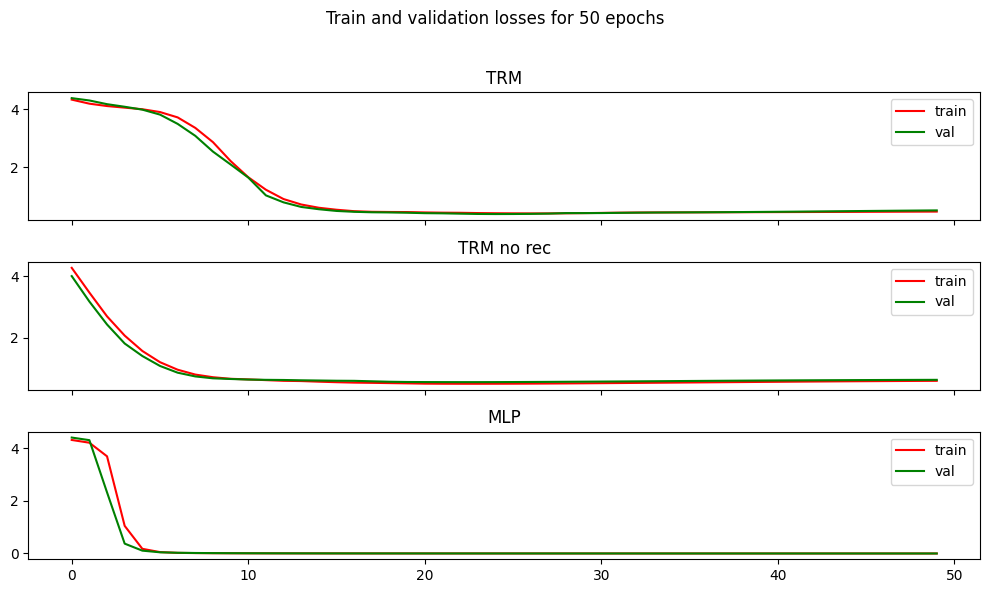

In [260]:
compare_losses(
    trm_base_sums_50_model,
    trm_norec_sums_50_model,
    mlp_sums_50_model,
)

In [261]:
display_logs("sums", 50, "regression")

,model_name,num_params,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,overfitting,underfitting
0,TRM,367,50,4.3341,0.4678,4.3856,0.5086,False,False
1,TRM no rec,367,50,4.2711,0.6100,4.0034,0.6419,False,False
2,MLP,309,50,4.3153,0.0004,4.4066,0.0004,False,False


### Conclusion

`MLP` has the best performance overall, exhibiting very small loss (final_train_loss=final_val_loss=0.0004). `TRM` performs better than `TRM no rec`.

### 1.1.4. TRM, 20 epochs

In [262]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=2,
    L_cycles=2,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_base_sums_20_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    num_epochs=20
)

trm_base_sums_20_model.name = "TRM"
trm_base_sums_20_model.dataset = "sums"

log_experiment(trm_base_sums_20_model)

Training / validation finished
Logging finished


### 1.1.5. TRM no recursion, 20 epochs

In [263]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=1,
    L_cycles=1,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_norec_sums_20_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    num_epochs=20
)

trm_norec_sums_20_model.name = "TRM no rec"
trm_norec_sums_20_model.dataset = "sums"

log_experiment(trm_norec_sums_20_model)

Training / validation finished
Logging finished


### 1.1.6. MLP, 20 epochs

In [264]:
mlp_sums_20_model, _, _ = train_mlp(
    D,
    x_train, y_train,
    x_val, y_val,
    num_epochs=20
)

mlp_sums_20_model.name = "MLP"
mlp_sums_20_model.dataset = "sums"

log_experiment(mlp_sums_20_model)

Training / validation finished
Logging finished


### Learning curves

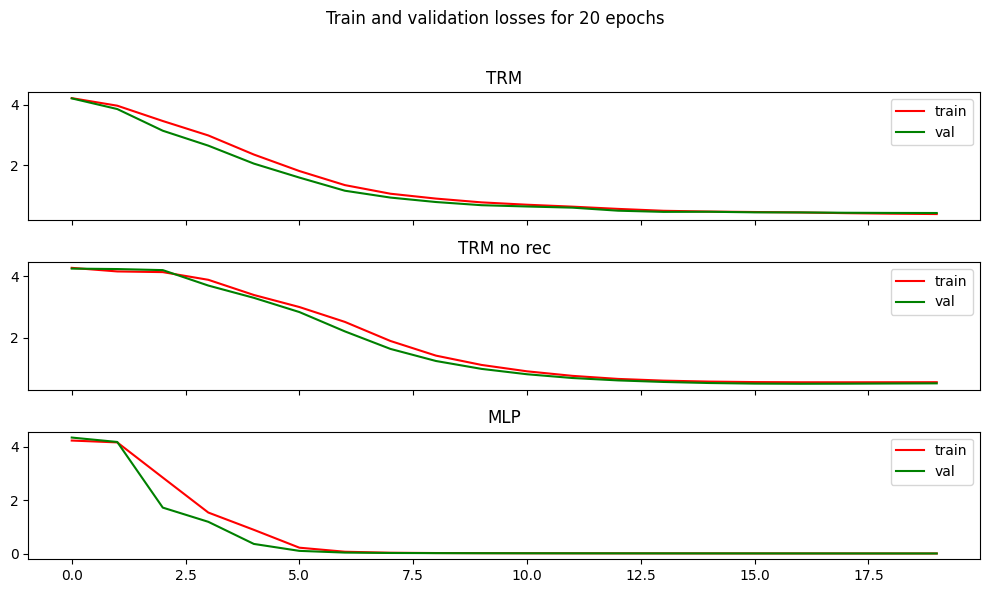

In [265]:
compare_losses(
    trm_base_sums_20_model,
    trm_norec_sums_20_model,
    mlp_sums_20_model,
)

In [266]:
display_logs("sums", 20, "regression")

,model_name,num_params,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,overfitting,underfitting
3,TRM,367,20,4.2153,0.3966,4.2075,0.4313,False,False
4,TRM no rec,367,20,4.2646,0.5563,4.2402,0.5189,False,False
5,MLP,309,20,4.2381,0.0032,4.3503,0.0037,False,False


### Conclusion

The same conclusions can be formulated as for 20 epochs.

### 1.1.7. TRM, 10 epochs

In [267]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=2,
    L_cycles=2,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_base_sums_10_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    num_epochs=10
)

trm_base_sums_10_model.name = "TRM"
trm_base_sums_10_model.dataset = "sums"

log_experiment(trm_base_sums_10_model)

Training / validation finished
Logging finished


### 1.1.8. TRM no recursion, 10 epochs


In [268]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=1,
    L_cycles=1,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_norec_sums_10_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    num_epochs=10
)

trm_norec_sums_10_model.name = "TRM no rec"
trm_norec_sums_10_model.dataset = "sums"

log_experiment(trm_norec_sums_10_model)

Training / validation finished
Logging finished


### 1.1.9. MLP, 10 epochs

In [269]:
mlp_sums_10_model, _, _ = train_mlp(
    D,
    x_train, y_train,
    x_val, y_val,
    num_epochs=10
)

mlp_sums_10_model.name = "MLP"
mlp_sums_10_model.dataset = "sums"

log_experiment(mlp_sums_10_model)

Training / validation finished
Logging finished


### Learning curves

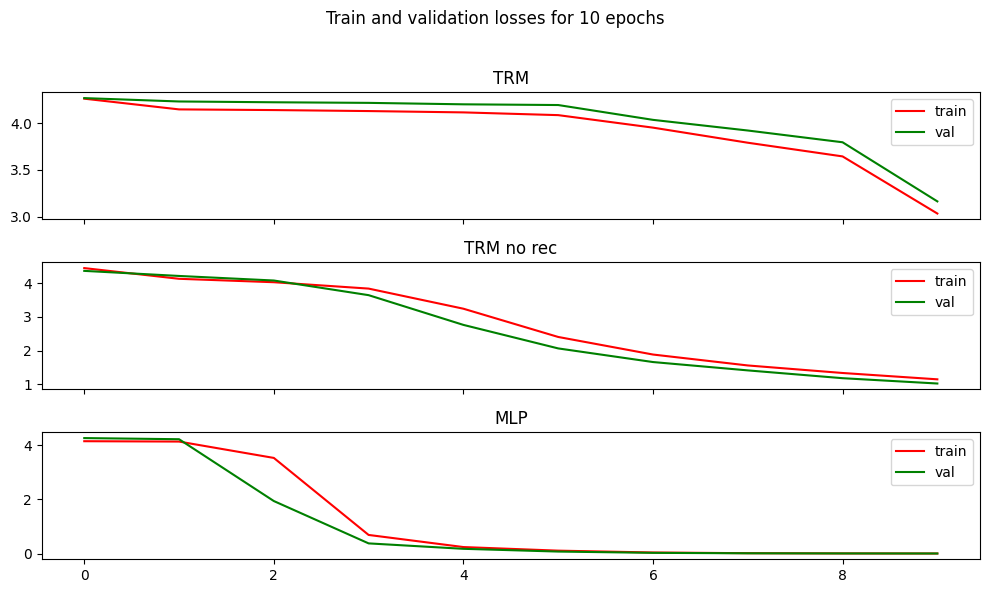

In [270]:
compare_losses(
    trm_base_sums_10_model,
    trm_norec_sums_10_model,
    mlp_sums_10_model,
)

In [271]:
display_logs("sums", 10, "regression")

,model_name,num_params,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,overfitting,underfitting
6,TRM,367,10,4.2616,3.0336,4.2677,3.1635,False,False
7,TRM no rec,367,10,4.4484,1.1450,4.3658,1.0204,False,False
8,MLP,309,10,4.1453,0.0100,4.2603,0.0105,False,False


### Conclusion

`TRM` and `TRM no rec` perform the worst out of all epoch runs, however `TRM no rec` performs better than `TRM`. The architceture of `TRM` is too complicated for this task, which is why `TRM no rec` is better. `TRM no rec` and `MLP` have better/faster convergence.

### Overview

In [272]:
display_logs("sums", "all", "regression")

,model_name,num_params,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,overfitting,underfitting
0,TRM,367,50,4.3341,0.4678,4.3856,0.5086,False,False
1,TRM no rec,367,50,4.2711,0.6100,4.0034,0.6419,False,False
2,MLP,309,50,4.3153,0.0004,4.4066,0.0004,False,False
3,TRM,367,20,4.2153,0.3966,4.2075,0.4313,False,False
4,TRM no rec,367,20,4.2646,0.5563,4.2402,0.5189,False,False
5,MLP,309,20,4.2381,0.0032,4.3503,0.0037,False,False
6,TRM,367,10,4.2616,3.0336,4.2677,3.1635,False,False
7,TRM no rec,367,10,4.4484,1.1450,4.3658,1.0204,False,False
8,MLP,309,10,4.1453,0.0100,4.2603,0.0105,False,False


### Conclusion

If we evaluate on just model performance, `MLP` wins in every category. `TRM` and `TRM no rec` do not show stable convergence patterns, as the results are best on 20 epochs, while mediocre on 50 epochs and bad on 10 epochs.

__ROUND 2.__ Effect of different settings.

### 1.1.10. TRM full grad

In [273]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=2,
    L_cycles=2,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
)

trm_allgrad_sums_10_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val,   y_val,
    model_cls=TRMRecOnlyModel,
    num_epochs=10
)

trm_allgrad_sums_10_model.name = "TRM all grad"
trm_allgrad_sums_10_model.dataset = "sums"

log_experiment(trm_allgrad_sums_10_model)

Training / validation finished
Logging finished


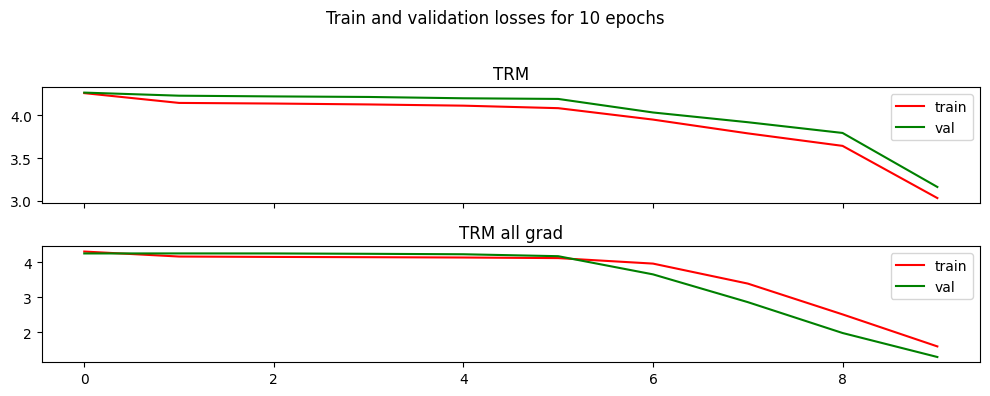

In [274]:
compare_losses(trm_base_sums_10_model,
               trm_allgrad_sums_10_model)

In [275]:
result = display_logs("sums", 10, "regression")
result.iloc[[0, -1]]

,model_name,num_params,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,overfitting,underfitting
6,TRM,367,10,4.2616,3.0336,4.2677,3.1635,False,False
9,TRM all grad,367,10,4.3051,1.6020,4.2508,1.2999,False,False


### Conclusion

`TRM all gard` performs way better than `TRM`.

### 1.1.11. TRM, ACT off

In [276]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=2,
    L_cycles=2,
    num_layers=2,
    halt_max_steps=1,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_noact_sums_10_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    num_epochs=10
)

trm_noact_sums_10_model.name = "TRM no act"
trm_noact_sums_10_model.dataset = "sums"

log_experiment(trm_noact_sums_10_model)

Training / validation finished
Logging finished


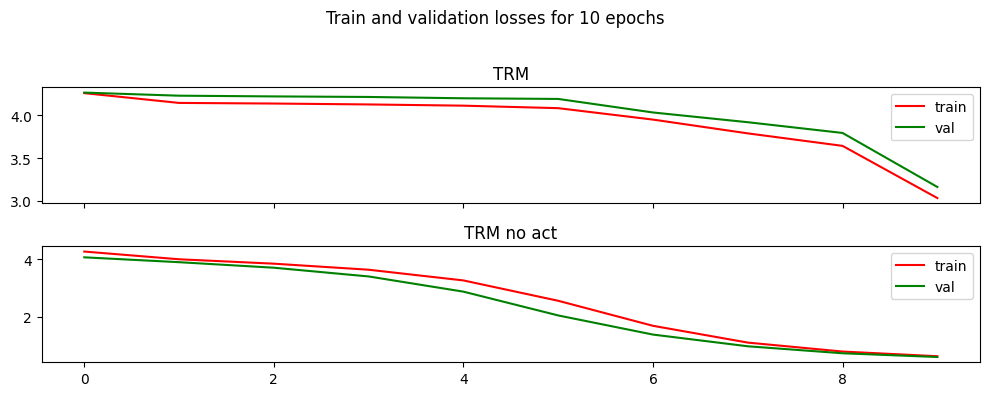

In [277]:
compare_losses(trm_base_sums_10_model,
               trm_noact_sums_10_model)

In [278]:
result = display_logs("sums", 10, "regression")
result.iloc[[0, -1]]

,model_name,num_params,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,overfitting,underfitting
6,TRM,367,10,4.2616,3.0336,4.2677,3.1635,False,False
10,TRM no act,367,10,4.2654,0.6355,4.0650,0.6089,False,False


### Conclusion

`TRM no act` performs way better than `TRM`. They start at similar initial train/validate loss, however `TRM no act` performs better.

### 1.1.12. TRM, no self-attention

In [279]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=2,
    L_cycles=2,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
    mlp_t=True
)

trm_nosa_sums_10_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    num_epochs=10
)

trm_nosa_sums_10_model.name = "TRM no sa"
trm_nosa_sums_10_model.dataset = "sums"

log_experiment(trm_nosa_sums_10_model)

Training / validation finished
Logging finished


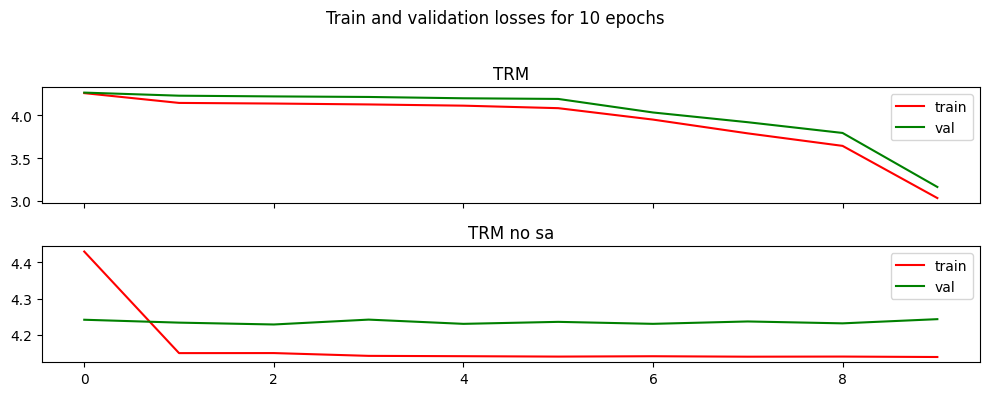

In [280]:
compare_losses(trm_base_sums_10_model,
               trm_nosa_sums_10_model)

In [281]:
result = display_logs("sums", 10, "regression")
result.iloc[[0, -1]]

,model_name,num_params,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,overfitting,underfitting
6,TRM,367,10,4.2616,3.0336,4.2677,3.1635,False,False
11,TRM no sa,221,10,4.4297,4.1389,4.2416,4.2433,False,True


### Conclusion

`TRM no sa` is underfitting, as validation loss almost does not change. Parameter number for both models also differ very much.

### 1.1.13. TRM, more self-attention heads

In [282]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=2,
    L_cycles=2,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
    num_heads=4
)

trm_4sa_sums_10_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    num_epochs=10
)

trm_4sa_sums_10_model.name = "TRM 4 sa"
trm_4sa_sums_10_model.dataset = "sums"

log_experiment(trm_4sa_sums_10_model)

Training / validation finished
Logging finished


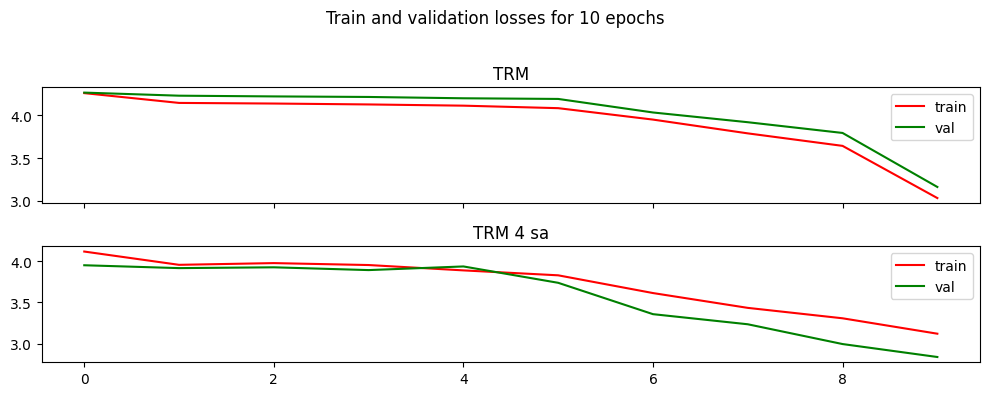

In [283]:
compare_losses(trm_base_sums_10_model,
               trm_4sa_sums_10_model)

In [284]:
result = display_logs("sums", 10, "regression")
result.iloc[[0, -1]]

,model_name,num_params,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,overfitting,underfitting
6,TRM,367,10,4.2616,3.0336,4.2677,3.1635,False,False
12,TRM 4 sa,367,10,4.1178,3.1198,3.9513,2.8367,False,False


### Conclusion

`TRM 4 sa` performs better on final validation loss, but intrestingly enough slightly worse on final train loss.

### 1.1.14. TRM, more outer loops

In [285]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=4,
    L_cycles=2,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_4h2l_sums_10_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    num_epochs=10
)

trm_4h2l_sums_10_model.name = "TRM 4H2L"
trm_4h2l_sums_10_model.dataset = "sums"

log_experiment(trm_4h2l_sums_10_model)

Training / validation finished
Logging finished


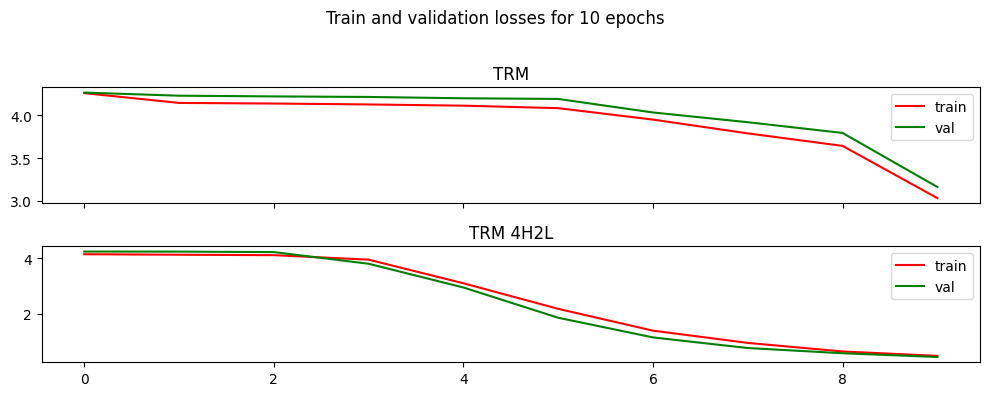

In [286]:
compare_losses(trm_base_sums_10_model,
               trm_4h2l_sums_10_model)

In [287]:
result = display_logs("sums", 10, "regression")
result.iloc[[0, -1]]

,model_name,num_params,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,overfitting,underfitting
6,TRM,367,10,4.2616,3.0336,4.2677,3.1635,False,False
13,TRM 4H2L,367,10,4.1439,0.4706,4.2403,0.4296,False,False


### Conclusion

`TRM 4H2L` performs way better than `TRM`, showing a huge jump in performance, even when compared to previous experiments we concluded.

### 1.1.15. TRM, more inner loops

In [288]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=2,
    L_cycles=4,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_2h4l_sums_10_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    num_epochs=10
)

trm_2h4l_sums_10_model.name = "TRM 2H4L"
trm_2h4l_sums_10_model.dataset = "sums"

log_experiment(trm_2h4l_sums_10_model)

Training / validation finished
Logging finished


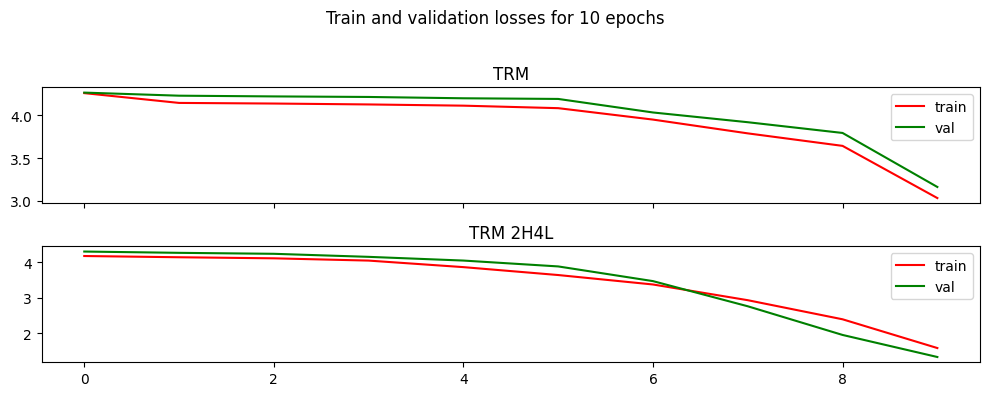

In [289]:
compare_losses(trm_base_sums_10_model,
               trm_2h4l_sums_10_model)

In [290]:
result = display_logs("sums", 10, "regression")
result.iloc[[0, -1]]

,model_name,num_params,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,overfitting,underfitting
6,TRM,367,10,4.2616,3.0336,4.2677,3.1635,False,False
14,TRM 2H4L,367,10,4.1796,1.5851,4.3056,1.3325,False,False


### Conclusion

`TRM 2H4L` performs better than `TRM`, but worse than the previous model, `TRM 4H2L`, indicating that for this particular task more outer loops would help the performance the most out of current experiments we completed.

### 1.1.16. TRM, more computational blocks

In [291]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=2,
    L_cycles=2,
    num_layers=4,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_4blocks_sums_10_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    num_epochs=10
)

trm_4blocks_sums_10_model.name = "TRM 4 blocks"
trm_4blocks_sums_10_model.dataset = "sums"

log_experiment(trm_4blocks_sums_10_model)

Training / validation finished
Logging finished


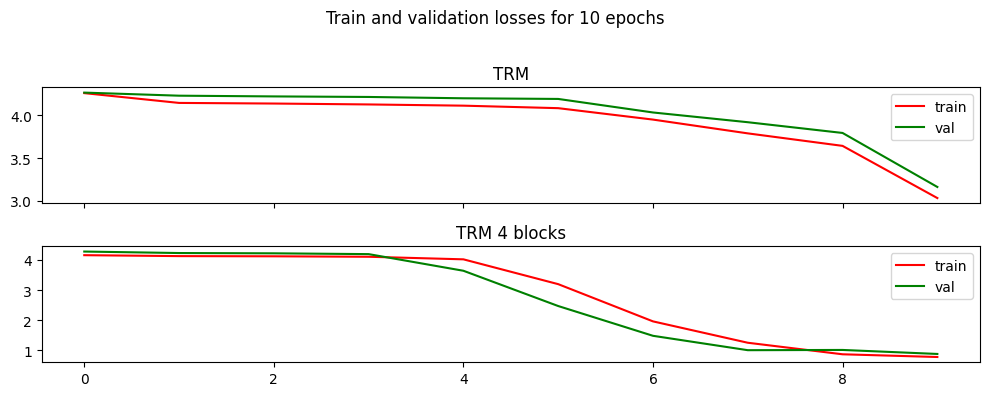

In [292]:
compare_losses(trm_base_sums_10_model,
               trm_4blocks_sums_10_model)

In [293]:
result = display_logs("sums", 10, "regression")
result.iloc[[0, -1]]

,model_name,num_params,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,overfitting,underfitting
6,TRM,367,10,4.2616,3.0336,4.2677,3.1635,False,False
15,TRM 4 blocks,711,10,4.1547,0.7792,4.2752,0.8803,False,False


### Conclusion

`TRM 4 block` introduces more parameters, at the same time making the performance of the model better. Although the parameter number is extensive, we get better results.

In [294]:
final_result = display_logs("sums", 10, "regression").sort_values(by=["final_train_loss", "final_val_loss"], ascending=[False, False])
final_result = final_result[final_result["model_name"].str.startswith("TRM")]
final_result.style.background_gradient(subset=["final_train_loss", "final_val_loss"], cmap="RdYlGn_r")

,model_name,num_params,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,overfitting,underfitting
11,TRM no sa,221,10,4.429700,4.138900,4.241600,4.243300,False,True
12,TRM 4 sa,367,10,4.117800,3.119800,3.951300,2.836700,False,False
6,TRM,367,10,4.261600,3.033600,4.267700,3.163500,False,False
9,TRM all grad,367,10,4.305100,1.602000,4.250800,1.299900,False,False
14,TRM 2H4L,367,10,4.179600,1.585100,4.305600,1.332500,False,False
7,TRM no rec,367,10,4.448400,1.145000,4.365800,1.020400,False,False
15,TRM 4 blocks,711,10,4.154700,0.779200,4.275200,0.880300,False,False
10,TRM no act,367,10,4.265400,0.635500,4.065000,0.608900,False,False
13,TRM 4H2L,367,10,4.143900,0.470600,4.240300,0.429600,False,False


__Note:__ Improvements shown above are not stable. During the previous run increase in amount of inner loops was the most effective way to improve model's preformace. This requires further investigation.

### Conclusion
The best results we get from `TRM 4H2L`, having a final train loss of 0.470600 and final validation loss of 0.429600. The results are still impressive even thought the model run for 10 epochs, so for future consideration we can experiment on higher epoch runtime to evaluate whether incease in them will get us better results.

## 1.2. Regression on real data

__ROUND 1:__ Small dataset `diabetes1`: diabetes progression score one year later depends on age, BMI, blood pressure, and serum feature s5.

In [295]:
diabetes = load_diabetes(as_frame=True)
df = diabetes.frame

feature_cols = ["age", "bmi", "bp", "s5"]
target_col = "target"

X = df[feature_cols].values
y = df[target_col].values.reshape(-1, 1)

x_train_np, x_val_np, y_train_np, y_val_np = train_test_split(
    X, y, test_size=0.2, random_state=0
)

x_train = torch.tensor(x_train_np, dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.float32)
x_val   = torch.tensor(x_val_np,   dtype=torch.float32)
y_val   = torch.tensor(y_val_np,   dtype=torch.float32)

x_mean, x_std = x_train.mean(0, keepdim=True), x_train.std(0, keepdim=True)
x_train = (x_train - x_mean) / (x_std + 1e-6)
x_val   = (x_val   - x_mean) / (x_std + 1e-6)

y_mean, y_std = y_train.mean(0, keepdim=True), y_train.std(0, keepdim=True)
y_train = (y_train - y_mean) / (y_std + 1e-6)
y_val   = (y_val   - y_mean) / (y_std + 1e-6)

D = x_train.shape[1]

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_val shape:",   x_val.shape)
print("y_val shape:",   y_val.shape)
print("hidden_dim:", D)

x_train shape: torch.Size([353, 4])
y_train shape: torch.Size([353, 1])
x_val shape: torch.Size([89, 4])
y_val shape: torch.Size([89, 1])
hidden_dim: 4


### 1.2.1. TRM, 50 epochs

In [296]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=2,
    L_cycles=2,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_base_diabetes1_50_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
)

trm_base_diabetes1_50_model.name = "TRM"
trm_base_diabetes1_50_model.dataset = "diabetes1"

log_experiment(trm_base_diabetes1_50_model)

Training / validation finished
Logging finished


### 1.2.2. TRM no recursion, 50 epochs

In [297]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=1,
    L_cycles=1,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_norec_diabetes1_50_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
)

trm_norec_diabetes1_50_model.name = "TRM no rec"
trm_norec_diabetes1_50_model.dataset = "diabetes1"

log_experiment(trm_norec_diabetes1_50_model)

Training / validation finished
Logging finished


### 1.2.3. MLP, 50 epochs

In [298]:
mlp_diabetes1_50_model, _, _ = train_mlp(
    D,
    x_train, y_train,
    x_val, y_val,
)

mlp_diabetes1_50_model.name = "MLP"
mlp_diabetes1_50_model.dataset = "diabetes1"

log_experiment(mlp_diabetes1_50_model)

Training / validation finished
Logging finished


### Learning curves

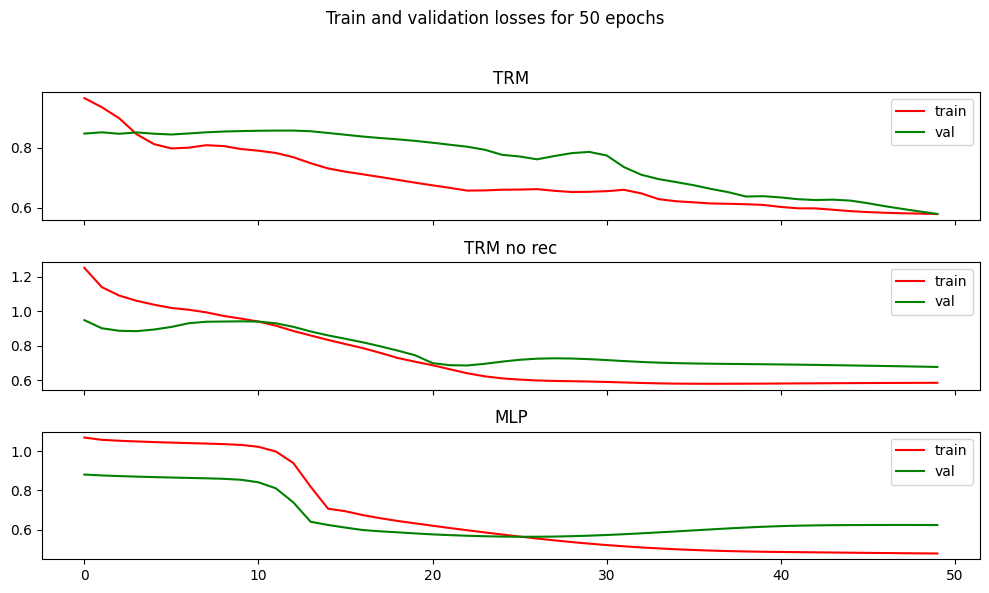

In [299]:
compare_losses(
    trm_base_diabetes1_50_model,
    trm_norec_diabetes1_50_model,
    mlp_diabetes1_50_model,
)

In [300]:
display_logs("diabetes1", 50, "regression")

,model_name,num_params,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,overfitting,underfitting
16,TRM,367,50,0.9646,0.5790,0.8466,0.5794,False,False
17,TRM no rec,367,50,1.2511,0.5844,0.9478,0.6764,False,False
18,MLP,309,50,1.0690,0.4786,0.8807,0.6234,True,False


### Conclusion

Based on results above, when comparing decreases in train losses, `MLP` perfoms the best, however `TRM` exhibits the best validation loss. This actually proves what the paper mentions - "This recursive process allows the model to progressively improve its answer (potentially addressing any errors from its previous answer) in an extremely parameter-efficient manner while minimizing overfitting." (Jolicoeur-Martineau, 2025). The same is evidence in a column where we check for over/underfitting, as we see that in `MLP`, even through it performed best on training data, it implemented memorisation and overfitted. Moreover, `TRM` loss on train and validate is almost equal, with amazing difference of 0.04. The full `TRM` and `TRM no rec` models have a slightly larger absolute parameter count than the simple `MLP`, which is expected due to the inclusion of the recurrent and halting mechanism. However, the `TRM` demonstrates better parameter efficiency compared to the `MLP`, as the `TRM` uses its parameters through multiple, adaptive steps to achieve a significantly better validation loss. To match the `TRM's` performance, the `MLP` would likely require a much deeper or wider architecture (and thus a far greater number of parameters), which supports the claim of TRM's parameter-efficient design.

One more comparison to be noted is between `TRM` and `TRM no rec`. As the latter is performing the worst, we can contribute `TRM's` good performance and generalisation to recursive mechanism.

### 1.2.4. TRM, 20 epochs

In [301]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=2,
    L_cycles=2,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_base_diabetes1_20_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    num_epochs=20
)

trm_base_diabetes1_20_model.name = "TRM"
trm_base_diabetes1_20_model.dataset = "diabetes1"

log_experiment(trm_base_diabetes1_20_model)

Training / validation finished
Logging finished


### 1.2.5. TRM no recursion, 20 epochs

In [302]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=1,
    L_cycles=1,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_norec_diabetes1_20_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    num_epochs=20
)

trm_norec_diabetes1_20_model.name = "TRM no rec"
trm_norec_diabetes1_20_model.dataset = "diabetes1"

log_experiment(trm_norec_diabetes1_20_model)

Training / validation finished
Logging finished


### 1.2.6. MLP, 20 epochs

In [303]:
mlp_diabetes1_20_model, _, _ = train_mlp(
    D,
    x_train, y_train,
    x_val, y_val,
    num_epochs=20
)

mlp_diabetes1_20_model.name = "MLP"
mlp_diabetes1_20_model.dataset = "diabetes1"

log_experiment(mlp_diabetes1_20_model)

Training / validation finished
Logging finished


### Learning curves

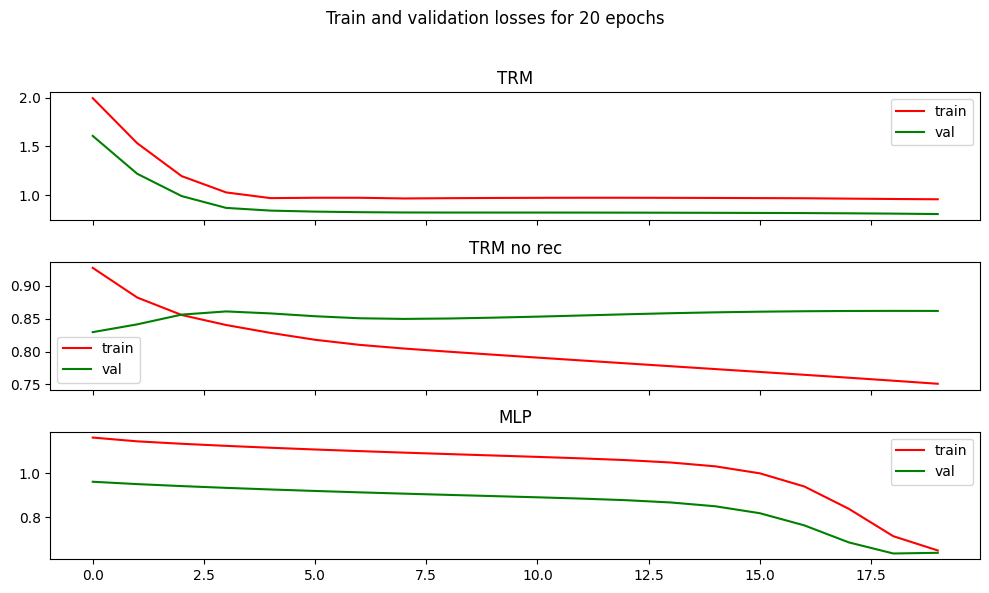

In [304]:
compare_losses(
    trm_base_diabetes1_20_model,
    trm_norec_diabetes1_20_model,
    mlp_diabetes1_20_model,
)

In [305]:
display_logs("diabetes1", 20, "regression")

,model_name,num_params,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,overfitting,underfitting
19,TRM,367,20,1.9948,0.9591,1.6082,0.8078,False,False
20,TRM no rec,367,20,0.9276,0.7509,0.8296,0.8619,False,True
21,MLP,309,20,1.1616,0.6488,0.9609,0.6381,False,False


### Conclusion

`MLP` achieved the best result, ending the 20-epoch run with the lowest final validation Loss (0.6381) and not overfitting. `MLP` performed better than at 50 epochs, while still exhibiting good generalising and low loss. The `TRM no rec` is underfitting, so we can confirm that by stripping out the recurrent mechanism, the model's capability to extract the complex features of the diabetes data is severely limited, leading to the worst overall performance (the same as 50 epochs).

An unusual finding in the 20-epoch `TRM` run is the significant loss gap, where its final train loss (0.9591) is much higher than its final validation loss (0.8078). This we contribute to regularization being applied during training. This indicates `TRM` is being heavily penalized by the optimization process, which may be why it takes longer than the `MLP` to achieve its optimal performance level (which was evident in the 50-epoch run).

### 1.2.7. TRM, 10 epochs

In [306]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=2,
    L_cycles=2,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_base_diabetes1_10_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    num_epochs=10
)

trm_base_diabetes1_10_model.name = "TRM"
trm_base_diabetes1_10_model.dataset = "diabetes1"

log_experiment(trm_base_diabetes1_10_model)

Training / validation finished
Logging finished


### 1.2.8. TRM no recursion, 10 epochs

In [307]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=1,
    L_cycles=1,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_norec_diabetes1_10_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    num_epochs=10
)

trm_norec_diabetes1_10_model.name = "TRM no rec"
trm_norec_diabetes1_10_model.dataset = "diabetes1"

log_experiment(trm_norec_diabetes1_10_model)

Training / validation finished
Logging finished


### 1.2.9. MLP, 10 epochs

In [308]:
mlp_diabetes1_10_model, _, _ = train_mlp(
    D,
    x_train, y_train,
    x_val, y_val,
    num_epochs=10
)

mlp_diabetes1_10_model.name = "MLP"
mlp_diabetes1_10_model.dataset = "diabetes1"

log_experiment(mlp_diabetes1_10_model)

Training / validation finished
Logging finished


### Learning curves

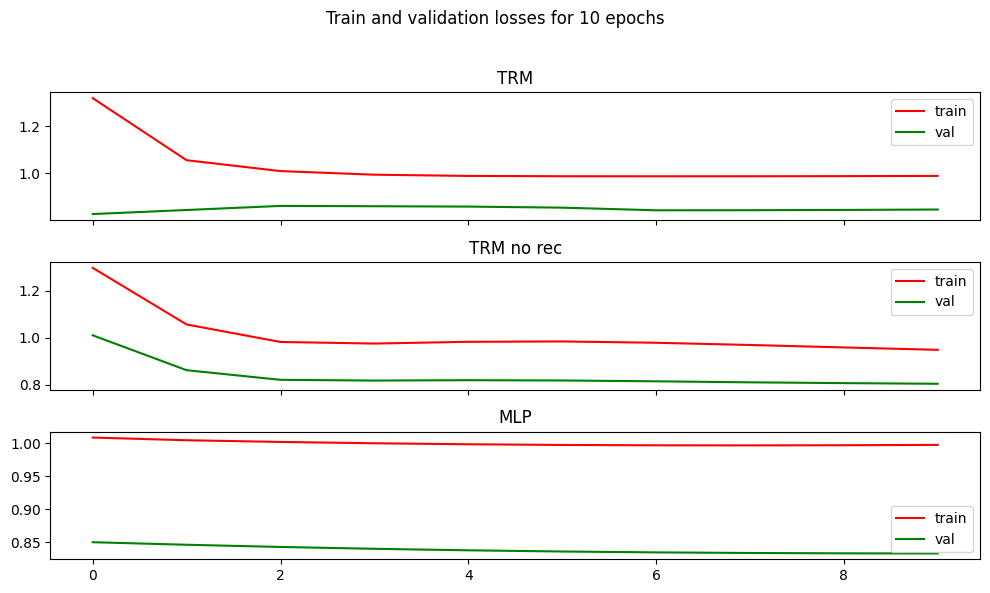

In [309]:
compare_losses(
    trm_base_diabetes1_10_model,
    trm_norec_diabetes1_10_model,
    mlp_diabetes1_10_model,
)

In [310]:
display_logs("diabetes1", 10, "regression")

,model_name,num_params,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,overfitting,underfitting
22,TRM,367,10,1.3203,0.9893,0.8270,0.8463,False,False
23,TRM no rec,367,10,1.2973,0.9490,1.0107,0.8047,False,False
24,MLP,309,10,1.0089,0.9978,0.8503,0.8333,False,True


### Conclusion

Here graphs have the highest convergence level throightout the whole training/validation process. Here, suprisingly, `TRM no rec` has the lowest final validation loss (0.8047). This result contradicts the 20 epoch and 50 epoch runs, where `TRM` was superior. This suggests the recurrent/halting mechanism takes time (more than 10 epochs) to become beneficial.

`MLP` has the highest final train loss (0.9978) and is underfitting.
This indicates that after only 10 epochs, the `MLP` has failed to capture the underlying patterns in the training data, making it the least effective model at this epoch runtime.

`TRM` has the highest final validation loss (0.8463). Its complex architecture is not that well developed at only 10 epochs.

### Overview

In [311]:
display_logs("diabetes1", "all", "regression")

,model_name,num_params,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,overfitting,underfitting
16,TRM,367,50,0.9646,0.5790,0.8466,0.5794,False,False
17,TRM no rec,367,50,1.2511,0.5844,0.9478,0.6764,False,False
18,MLP,309,50,1.0690,0.4786,0.8807,0.6234,True,False
19,TRM,367,20,1.9948,0.9591,1.6082,0.8078,False,False
20,TRM no rec,367,20,0.9276,0.7509,0.8296,0.8619,False,True
21,MLP,309,20,1.1616,0.6488,0.9609,0.6381,False,False
22,TRM,367,10,1.3203,0.9893,0.8270,0.8463,False,False
23,TRM no rec,367,10,1.2973,0.9490,1.0107,0.8047,False,False
24,MLP,309,10,1.0089,0.9978,0.8503,0.8333,False,True


### Conclusion

To conclude, based on validation final loss, based model is `TRM` on 50 epochs, indicating that it performs well on small dataset with sufficient epochs to fully capture the patterns.

__ROUND 2.__ Effect of different settings.

### 1.2.10. TRM full grad

In [312]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=2,
    L_cycles=2,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
)

trm_allgrad_diabetes1_10_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val,   y_val,
    model_cls=TRMRecOnlyModel,
    num_epochs=10
)

trm_allgrad_diabetes1_10_model.name = "TRM all grad"
trm_allgrad_diabetes1_10_model.dataset = "diabetes1"

log_experiment(trm_allgrad_diabetes1_10_model)

Training / validation finished
Logging finished


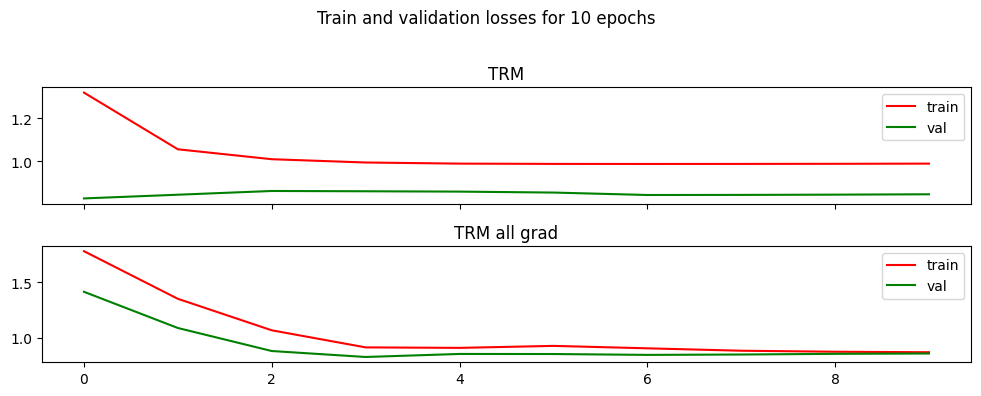

In [313]:
compare_losses(trm_base_diabetes1_10_model,
               trm_allgrad_diabetes1_10_model)

In [314]:
result = display_logs("diabetes1", 10, "regression")
result.iloc[[0, -1]]

,model_name,num_params,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,overfitting,underfitting
22,TRM,367,10,1.3203,0.9893,0.8270,0.8463,False,False
25,TRM all grad,367,10,1.7826,0.8687,1.4153,0.8571,False,False


### Conclusion

Main difference is in validation curve, as it starts off in a higher point, but overall both `TRM` and `TRM all grad` converge to very similar final validation loss (for `TRM` 0.8463, for `TRM all grad` 0.8571). Both don't have problems with generalisation, nor with the underfitting, however `TRM` exhibits lower loss.

### 1.2.11. TRM, ACT off

In [315]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=2,
    L_cycles=2,
    num_layers=2,
    halt_max_steps=1,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_noact_diabetes1_10_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    num_epochs=10
)

trm_noact_diabetes1_10_model.name = "TRM no act"
trm_noact_diabetes1_10_model.dataset = "diabetes1"

log_experiment(trm_noact_diabetes1_10_model)

Training / validation finished
Logging finished


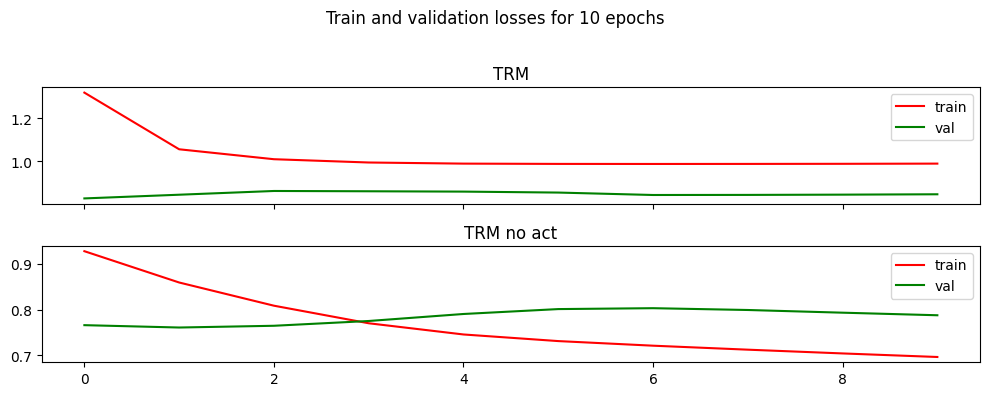

In [316]:
compare_losses(trm_base_diabetes1_10_model,
               trm_noact_diabetes1_10_model)

In [317]:
result = display_logs("diabetes1", 10, "regression")
result.iloc[[0, -1]]

,model_name,num_params,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,overfitting,underfitting
22,TRM,367,10,1.3203,0.9893,0.8270,0.8463,False,False
26,TRM no act,367,10,0.9271,0.6966,0.7659,0.7875,False,False


### Conclusion

`TRM no act` has better final validation loss than `TRM`, as well as better final train loss than `TRM`. `TRM no act` also starts out with lower losses when compared to `TRM`.

### 1.2.12. TRM, no self-attention

In [318]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=2,
    L_cycles=2,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
    mlp_t=True
)

trm_nosa_diabetes1_10_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    num_epochs=10
)

trm_nosa_diabetes1_10_model.name = "TRM no sa"
trm_nosa_diabetes1_10_model.dataset = "diabetes1"

log_experiment(trm_nosa_diabetes1_10_model)

Training / validation finished
Logging finished


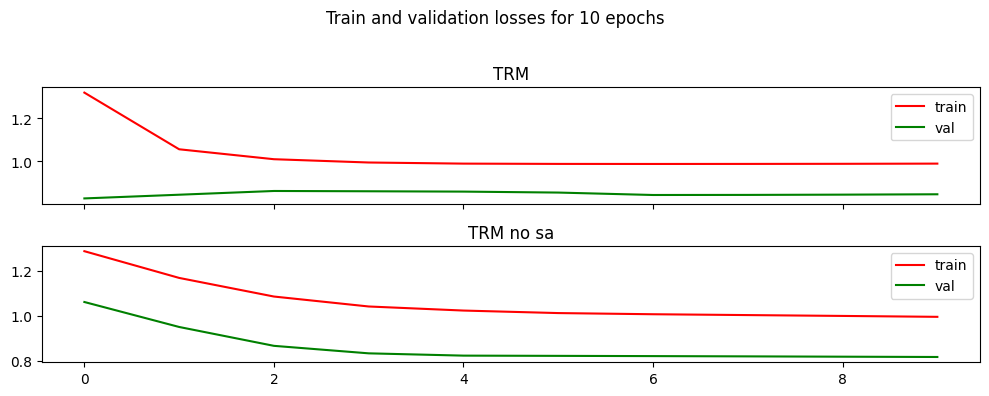

In [319]:
compare_losses(trm_base_diabetes1_10_model,
               trm_nosa_diabetes1_10_model)

In [320]:
result = display_logs("diabetes1", 10, "regression")
result.iloc[[0, -1]]

,model_name,num_params,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,overfitting,underfitting
22,TRM,367,10,1.3203,0.9893,0.8270,0.8463,False,False
27,TRM no sa,221,10,1.2856,0.9952,1.0608,0.8175,False,False


### Conclusion

In terms of performance, models performed similary, with `TRM` with no self-attention having slightly better final validation loss (0.8175<0.8463). However, if we were to notice, `TRM no sa` attention has smaller number of parameters (the smallest among all `TRM` we performed on diabetes), so it is less computationally extensive.

### 1.2.13. TRM, more self-attention heads

In [321]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=2,
    L_cycles=2,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
    num_heads=4
)

trm_4sa_diabetes1_10_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    num_epochs=10
)

trm_4sa_diabetes1_10_model.name = "TRM 4 sa"
trm_4sa_diabetes1_10_model.dataset = "diabetes1"

log_experiment(trm_4sa_diabetes1_10_model)

Training / validation finished
Logging finished


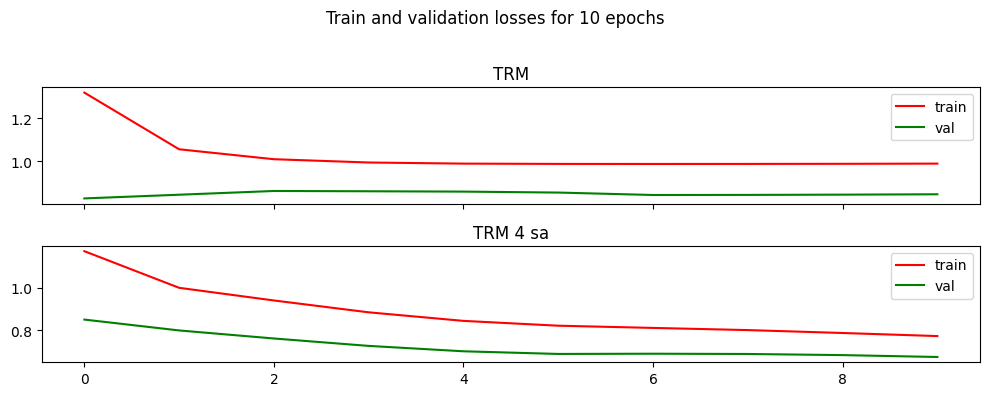

In [322]:
compare_losses(trm_base_diabetes1_10_model,
               trm_4sa_diabetes1_10_model)

In [323]:
result = display_logs("diabetes1", 10, "regression")
result.iloc[[0, -1]]

,model_name,num_params,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,overfitting,underfitting
22,TRM,367,10,1.3203,0.9893,0.8270,0.8463,False,False
28,TRM 4 sa,367,10,1.1712,0.7737,0.8509,0.6757,False,False


### Conclusion

`TRM 4 sa` performed better, featuring a 0.6757 final validation loss, which is quite low when compared to `TRM` (`TRM` achieved similar loss after 50 epochs, while `TRM 4 sa` after 10 epochs). Also, number of parameters stay the same.

### 1.2.14. TRM, more outer loops

In [324]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=4,
    L_cycles=2,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_4h2l_diabetes1_10_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    num_epochs=10
)

trm_4h2l_diabetes1_10_model.name = "TRM 4H2L"
trm_4h2l_diabetes1_10_model.dataset = "diabetes1"

log_experiment(trm_4h2l_diabetes1_10_model)

Training / validation finished
Logging finished


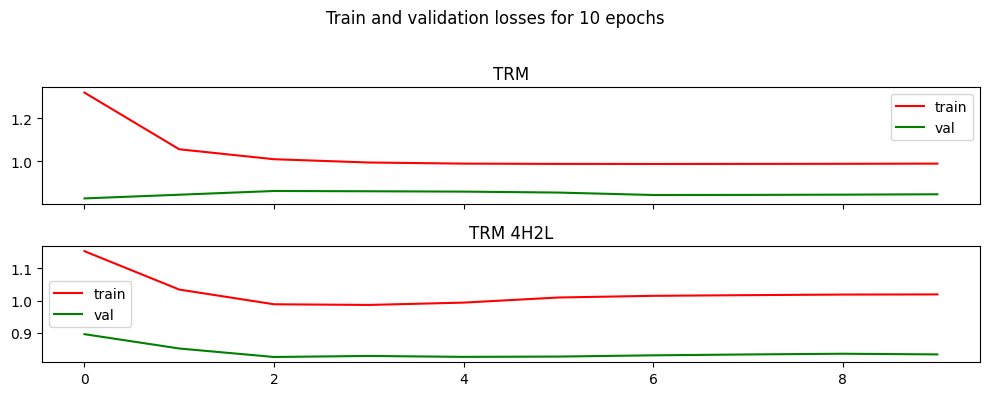

In [325]:
compare_losses(trm_base_diabetes1_10_model,
               trm_4h2l_diabetes1_10_model)

In [326]:
result = display_logs("diabetes1", 10, "regression")
result.iloc[[0, -1]]

,model_name,num_params,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,overfitting,underfitting
22,TRM,367,10,1.3203,0.9893,0.8270,0.8463,False,False
29,TRM 4H2L,367,10,1.1535,1.0192,0.8957,0.8329,False,True


### Conclusion

Models performed similary, althought `TRM` with more loops is underfitting. It could be worth exploring thought, as it exhibits slightly smaller final validation loss.

### 1.2.15. TRM, more inner loops

In [327]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=2,
    L_cycles=4,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_2h4l_diabetes1_10_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    num_epochs=10
)

trm_2h4l_diabetes1_10_model.name = "TRM 2H4L"
trm_2h4l_diabetes1_10_model.dataset = "diabetes1"

log_experiment(trm_2h4l_diabetes1_10_model)

Training / validation finished
Logging finished


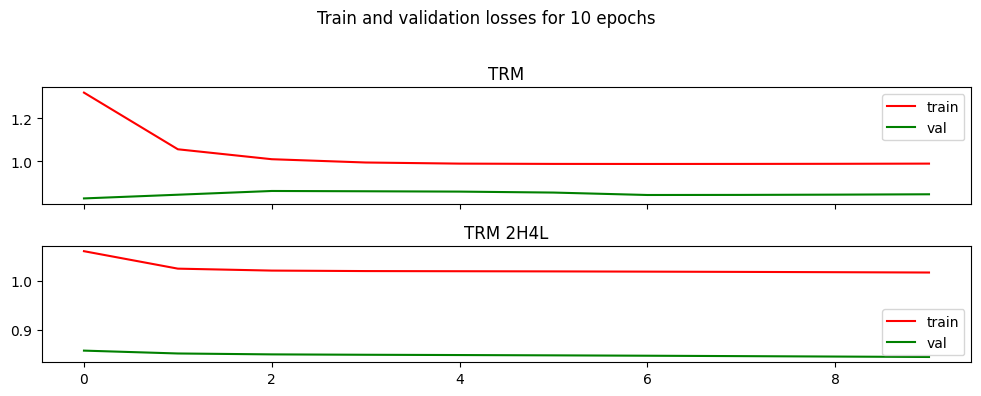

In [328]:
compare_losses(trm_base_diabetes1_10_model,
               trm_2h4l_diabetes1_10_model)

In [329]:
result = display_logs("diabetes1", 10, "regression")
result.iloc[[0, -1]]

,model_name,num_params,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,overfitting,underfitting
22,TRM,367,10,1.3203,0.9893,0.8270,0.8463,False,False
30,TRM 2H4L,367,10,1.0607,1.0172,0.8578,0.8449,False,True


### Conclusion

`TRM` with more inner loops is underfitting, but final validation loss as well as final train loss remain pretty similar.

### 1.2.16. TRM, more computational blocks

In [330]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=2,
    L_cycles=2,
    num_layers=4,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_4blocks_diabetes1_10_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    num_epochs=10
)

trm_4blocks_diabetes1_10_model.name = "TRM 4 blocks"
trm_4blocks_diabetes1_10_model.dataset = "diabetes1"

log_experiment(trm_4blocks_diabetes1_10_model)

Training / validation finished
Logging finished


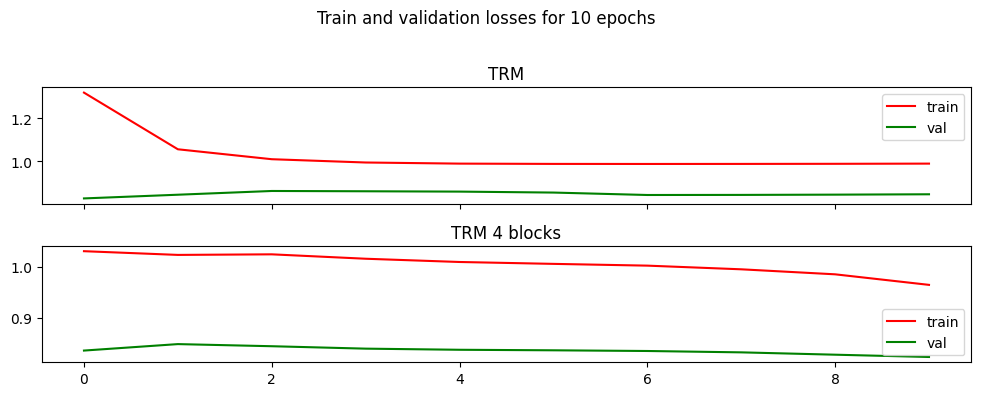

In [331]:
compare_losses(trm_base_diabetes1_10_model,
               trm_4blocks_diabetes1_10_model)

In [332]:
result = display_logs("diabetes1", 10, "regression")
result.iloc[[0, -1]]

,model_name,num_params,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,overfitting,underfitting
22,TRM,367,10,1.3203,0.9893,0.827,0.8463,False,False
31,TRM 4 blocks,711,10,1.0308,0.9648,0.836,0.8235,False,True


### Conclusion

Final losses are similar, but `TRM 4 blocs` is underfitting and has smaller gap between train-val. At the same `TRM 4 blocks` has 711 parameters, making it a bit extensive for similar losses as TRM.

In [333]:
final_result = display_logs("diabetes1", 10, "regression").sort_values(by=["final_train_loss", "final_val_loss"], ascending=[False, False])
final_result = final_result[final_result["model_name"].str.startswith("TRM")]
final_result.style.background_gradient(subset=["final_train_loss", "final_val_loss"], cmap="RdYlGn_r")

,model_name,num_params,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,overfitting,underfitting
29,TRM 4H2L,367,10,1.153500,1.019200,0.895700,0.832900,False,True
30,TRM 2H4L,367,10,1.060700,1.017200,0.857800,0.844900,False,True
27,TRM no sa,221,10,1.285600,0.995200,1.060800,0.817500,False,False
22,TRM,367,10,1.320300,0.989300,0.827000,0.846300,False,False
31,TRM 4 blocks,711,10,1.030800,0.964800,0.836000,0.823500,False,True
23,TRM no rec,367,10,1.297300,0.949000,1.010700,0.804700,False,False
25,TRM all grad,367,10,1.782600,0.868700,1.415300,0.857100,False,False
28,TRM 4 sa,367,10,1.171200,0.773700,0.850900,0.675700,False,False
26,TRM no act,367,10,0.927100,0.696600,0.765900,0.787500,False,False


### Conclusion

Overall, best beforming models are `TRM 4 sa` and `TRM no act`. `TRM 4 sa` exhibits lower final validation loss (0.6757), while `TRM no act` exhibits lower train loss (0.6966).

In [334]:
s = display_logs("sums", 10, "regression")[["model_name", "final_train_loss", "final_val_loss", "overfitting", "underfitting"]]
r = display_logs("diabetes1", 10, "regression")[["model_name", "final_train_loss", "final_val_loss", "overfitting", "underfitting"]]
m = s.merge(r, on="model_name", suffixes=["_s", "_r"])
m.style.background_gradient(subset=["final_train_loss_s", "final_val_loss_s", "final_train_loss_r", "final_val_loss_r"], cmap="RdYlGn_r")

,model_name,final_train_loss_s,final_val_loss_s,overfitting_s,underfitting_s,final_train_loss_r,final_val_loss_r,overfitting_r,underfitting_r
0,TRM,3.033600,3.163500,False,False,0.989300,0.846300,False,False
1,TRM no rec,1.145000,1.020400,False,False,0.949000,0.804700,False,False
2,MLP,0.010000,0.010500,False,False,0.997800,0.833300,False,True
3,TRM all grad,1.602000,1.299900,False,False,0.868700,0.857100,False,False
4,TRM no act,0.635500,0.608900,False,False,0.696600,0.787500,False,False
5,TRM no sa,4.138900,4.243300,False,True,0.995200,0.817500,False,False
6,TRM 4 sa,3.119800,2.836700,False,False,0.773700,0.675700,False,False
7,TRM 4H2L,0.470600,0.429600,False,False,1.019200,0.832900,False,True
8,TRM 2H4L,1.585100,1.332500,False,False,1.017200,0.844900,False,True
9,TRM 4 blocks,0.779200,0.880300,False,False,0.964800,0.823500,False,True


### Final conclusions

On synthetic data, `TRM` performance was average. The best result was achieved by `TRM 4H2L` (when we take into consideration only TRMs), and by `MLP` overall. On real data, TRMs performed better, as the range of losses is lower overall. The best performing model was `TRM 4 sa`.


# 2. Binary classification

## 2.1. Binary classification on synthetic data

__ROUND 1.__ Dataset `circle`: true if a point is outside of the unit-radius circle.

In [335]:
torch.manual_seed(0)

def make_circle_binary_dataset(num_samples=1024, hidden_dim=8):
    """
    x_emb: N x D standard normal
    y_true: 1 if x lies outside a circle in (x0, x1)-plane, else 0
    """
    x_emb = torch.randn(num_samples, hidden_dim)   # (N, D)

    x0 = x_emb[:, 0]
    x1 = x_emb[:, 1]

    r2 = x0**2 + x1**2               # squared radius
    y_true = (r2 > 1.0).float()      # outside circle -> 1, inside -> 0
    y_true = y_true.unsqueeze(1)     # (N, 1)

    return x_emb, y_true

# Example usage
hidden_dim = 8   # different from 4
x_train, y_train = make_circle_binary_dataset(num_samples=2000, hidden_dim=hidden_dim)
x_val,   y_val   = make_circle_binary_dataset(num_samples=500,  hidden_dim=hidden_dim)

D = x_train.shape[1]

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_val shape:",   x_val.shape)
print("y_val shape:",   y_val.shape)
print("hidden_dim:", D)

x_train shape: torch.Size([2000, 8])
y_train shape: torch.Size([2000, 1])
x_val shape: torch.Size([500, 8])
y_val shape: torch.Size([500, 1])
hidden_dim: 8


### 2.1.1. TRM, 50 epochs

In [336]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=2,
    L_cycles=2,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_base_circle_50_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    task="classification",
    num_classes=2
)

trm_base_circle_50_model.name = "TRM"
trm_base_circle_50_model.dataset = "circle"

log_experiment(trm_base_circle_50_model)

Training / validation finished
Logging finished


### 2.1.2. TRM no recursion, 50 epochs

In [337]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=1,
    L_cycles=1,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_norec_circle_50_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    task="classification",
    num_classes=2
)

trm_norec_circle_50_model.name = "TRM no rec"
trm_norec_circle_50_model.dataset = "circle"

log_experiment(trm_norec_circle_50_model)

Training / validation finished
Logging finished


### 2.1.3. MLP, 50 epochs

In [338]:
mlp_circle_50_model, _, _ = train_mlp(
    D,
    x_train, y_train,
    x_val, y_val,
    task="classification",
    num_classes=2,
)

mlp_circle_50_model.name = "MLP"
mlp_circle_50_model.dataset = "circle"

log_experiment(mlp_circle_50_model)

Training / validation finished
Logging finished


### Learning curves

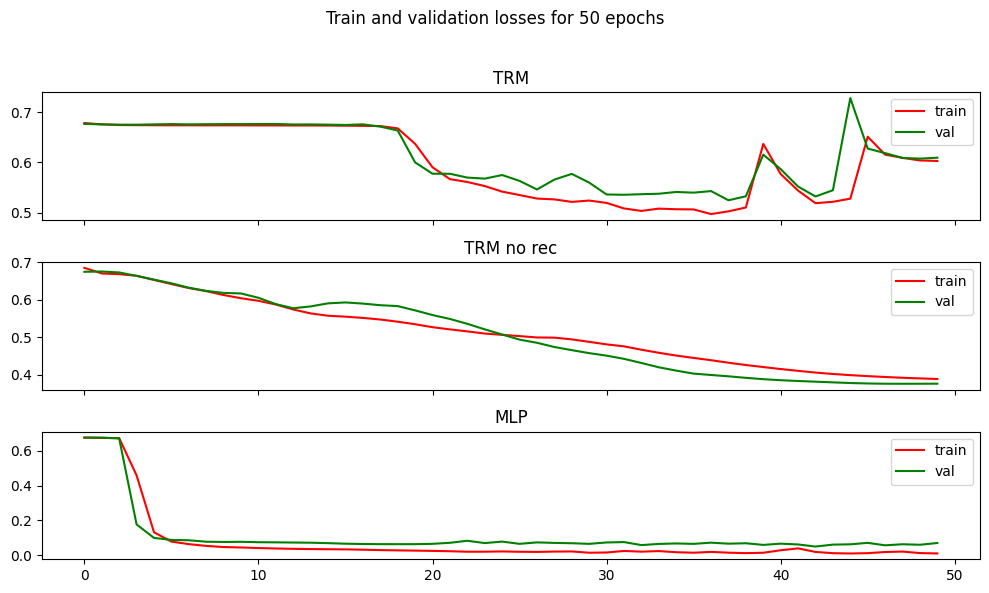

In [339]:
compare_losses(trm_base_circle_50_model,
               trm_norec_circle_50_model,
               mlp_circle_50_model)

In [340]:
display_logs("circle", 50)

,model_name,task,num_params,dataset,num_classes,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,initial_train_acc,final_train_acc,initial_val_acc,final_val_acc,overfitting,underfitting,near_random
32,TRM,classification,1243,circle,2.0,50,0.6782,0.6030,0.6764,0.6094,0.5950,0.6050,0.596,0.606,False,True,False
33,TRM no rec,classification,1243,circle,2.0,50,0.6850,0.3889,0.6745,0.3764,0.5865,0.8315,0.598,0.836,False,False,False
34,MLP,classification,1129,circle,2.0,50,0.6746,0.0106,0.6749,0.0706,0.6015,0.9965,0.596,0.980,True,False,False


### Conclusion

Based on losses `MLP` performs the best. We observed very instresting behavious of `TRM`, as in the middle we see that loss is slightly decreasing, and then at the end it performs several jumps and reached final losses, which are similar to initial ones. `TRM no rec` has more stable behaviour, so propably it is recursive mechanism which is making hard for `TRM` to lear pattern recognision.

### 2.1.4. TRM, 20 epochs

In [341]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=2,
    L_cycles=2,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_base_circle_20_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    task="classification",
    num_classes=2,
    num_epochs=20
)

trm_base_circle_20_model.name = "TRM"
trm_base_circle_20_model.dataset = "circle"

log_experiment(trm_base_circle_20_model)

Training / validation finished
Logging finished


### 2.1.5. TRM no recursion, 20 epochs

In [342]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=1,
    L_cycles=1,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_norec_circle_20_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    task="classification",
    num_classes=2,
    num_epochs=20
)

trm_norec_circle_20_model.name = "TRM no rec"
trm_norec_circle_20_model.dataset = "circle"

log_experiment(trm_norec_circle_20_model)

Training / validation finished
Logging finished


### 2.1.6. MLP, 20 epochs

In [343]:
mlp_circle_20_model, _, _ = train_mlp(
    D,
    x_train, y_train,
    x_val, y_val,
    task="classification",
    num_classes=2,
    num_epochs=20
)

mlp_circle_20_model.name = "MLP"
mlp_circle_20_model.dataset = "circle"

log_experiment(mlp_circle_20_model)

Training / validation finished
Logging finished


### Learning curves

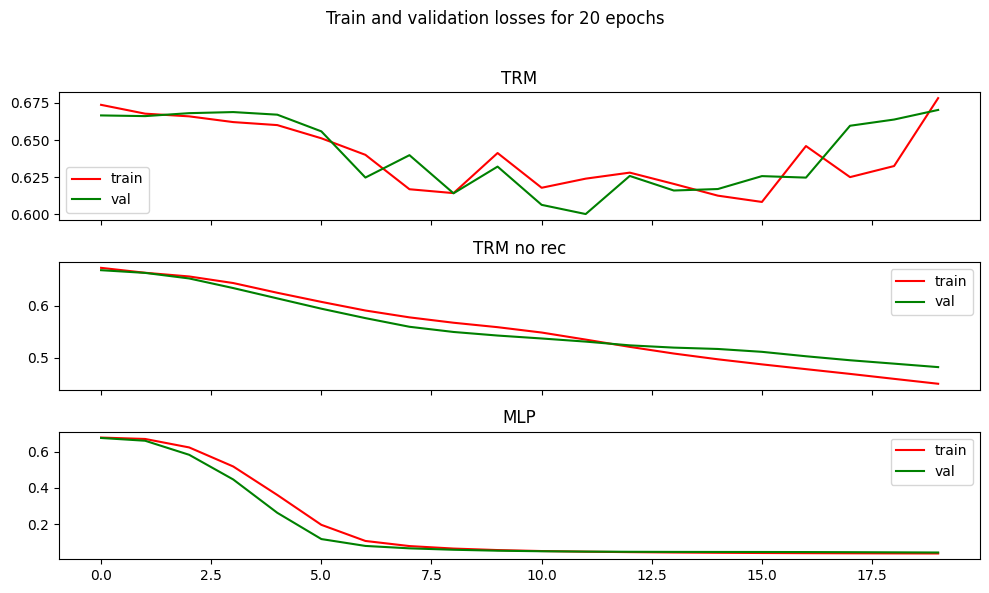

In [344]:
compare_losses(trm_base_circle_20_model,
               trm_norec_circle_20_model,
               mlp_circle_20_model)

In [345]:
display_logs("circle", 20)

,model_name,task,num_params,dataset,num_classes,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,initial_train_acc,final_train_acc,initial_val_acc,final_val_acc,overfitting,underfitting,near_random
35,TRM,classification,1243,circle,2.0,20,0.6737,0.6782,0.6666,0.6702,0.5930,0.6080,0.614,0.574,False,True,False
36,TRM no rec,classification,1243,circle,2.0,20,0.6725,0.4499,0.6680,0.4819,0.5825,0.7910,0.598,0.772,False,False,False
37,MLP,classification,1129,circle,2.0,20,0.6785,0.0375,0.6762,0.0429,0.6015,0.9845,0.596,0.980,False,False,False


### Conclusion

`MLP` performs the best here as well. While running for 20 epochs `TRM` and `TRM no rec` exhibit very similar behaviour to those of 50 epochs.

### 2.1.7. TRM, 10 epochs

In [346]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=2,
    L_cycles=2,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_base_circle_10_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    task="classification",
    num_classes=2,
    num_epochs=10
)

trm_base_circle_10_model.name = "TRM"
trm_base_circle_10_model.dataset = "circle"

log_experiment(trm_base_circle_10_model)

Training / validation finished
Logging finished


### 2.1.8. TRM no recursion, 10 epochs

In [347]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=1,
    L_cycles=1,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_norec_circle_10_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    task="classification",
    num_classes=2,
    num_epochs=10
)

trm_norec_circle_10_model.name = "TRM no rec"
trm_norec_circle_10_model.dataset = "circle"

log_experiment(trm_norec_circle_10_model)

Training / validation finished
Logging finished


### 2.1.9. MLP, 10 epochs

In [348]:
mlp_circle_10_model, _, _ = train_mlp(
    D,
    x_train, y_train,
    x_val, y_val,
    task="classification",
    num_classes=2,
    num_epochs=10
)

mlp_circle_10_model.name = "MLP"
mlp_circle_10_model.dataset = "circle"

log_experiment(mlp_circle_10_model)

Training / validation finished
Logging finished


### Learning curves

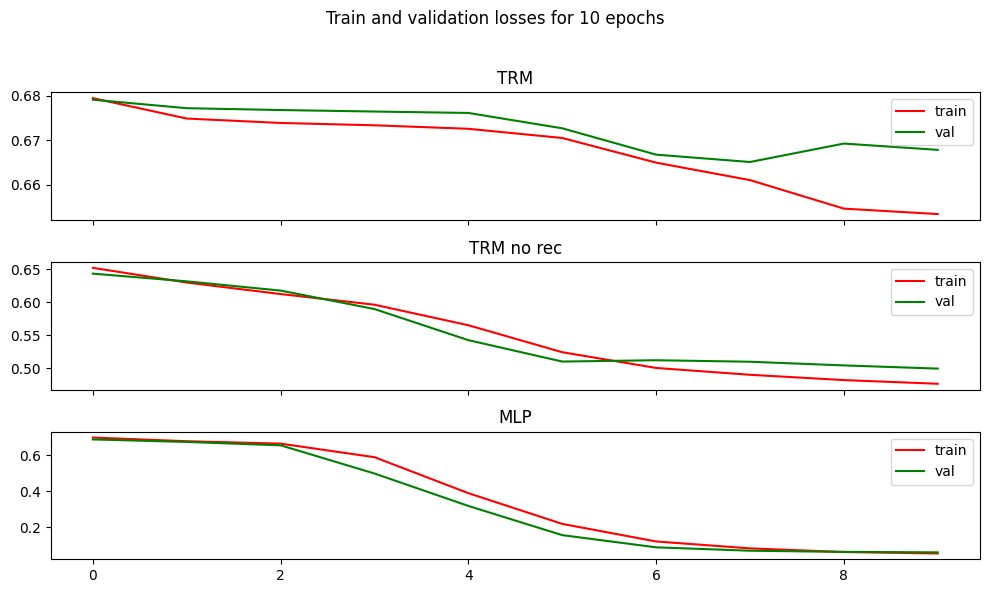

In [349]:
compare_losses(trm_base_circle_10_model,
               trm_norec_circle_10_model,
               mlp_circle_10_model)

In [350]:
display_logs("circle", 10)

,model_name,task,num_params,dataset,num_classes,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,initial_train_acc,final_train_acc,initial_val_acc,final_val_acc,overfitting,underfitting,near_random
38,TRM,classification,1243,circle,2.0,10,0.6795,0.6533,0.6791,0.6678,0.5885,0.6105,0.596,0.586,False,True,False
39,TRM no rec,classification,1243,circle,2.0,10,0.6518,0.4766,0.6431,0.4996,0.5940,0.7425,0.586,0.710,False,False,False
40,MLP,classification,1129,circle,2.0,10,0.6977,0.0533,0.6873,0.0595,0.4615,0.9780,0.596,0.972,False,False,False


### Conclusion

Towards the end `TRM` diverged, when `TRM no rec` behaviour slightly converges. `TRM` underfits.

### Overview

In [351]:
display_logs("circle", "all")

,model_name,task,num_params,dataset,num_classes,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,initial_train_acc,final_train_acc,initial_val_acc,final_val_acc,overfitting,underfitting,near_random
32,TRM,classification,1243,circle,2.0,50,0.6782,0.6030,0.6764,0.6094,0.5950,0.6050,0.596,0.606,False,True,False
33,TRM no rec,classification,1243,circle,2.0,50,0.6850,0.3889,0.6745,0.3764,0.5865,0.8315,0.598,0.836,False,False,False
34,MLP,classification,1129,circle,2.0,50,0.6746,0.0106,0.6749,0.0706,0.6015,0.9965,0.596,0.980,True,False,False
35,TRM,classification,1243,circle,2.0,20,0.6737,0.6782,0.6666,0.6702,0.5930,0.6080,0.614,0.574,False,True,False
36,TRM no rec,classification,1243,circle,2.0,20,0.6725,0.4499,0.6680,0.4819,0.5825,0.7910,0.598,0.772,False,False,False
37,MLP,classification,1129,circle,2.0,20,0.6785,0.0375,0.6762,0.0429,0.6015,0.9845,0.596,0.980,False,False,False
38,TRM,classification,1243,circle,2.0,10,0.6795,0.6533,0.6791,0.6678,0.5885,0.6105,0.596,0.586,False,True,False
39,TRM no rec,classification,1243,circle,2.0,10,0.6518,0.4766,0.6431,0.4996,0.5940,0.7425,0.586,0.710,False,False,False
40,MLP,classification,1129,circle,2.0,10,0.6977,0.0533,0.6873,0.0595,0.4615,0.9780,0.596,0.972,False,False,False


### Conclusion

`MLP` perform best on different epochs.

__ROUND 2.__ Effect of different settings.

### 2.1.10. TRM full grad

In [352]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=2,
    L_cycles=2,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
)

trm_allgrad_circle_10_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val,   y_val,
    model_cls=TRMRecOnlyModel,
    num_epochs=10,
    task="classification",
    num_classes=2
)

trm_allgrad_circle_10_model.name = "TRM all grad"
trm_allgrad_circle_10_model.dataset = "circle"

log_experiment(trm_allgrad_circle_10_model)

Training / validation finished
Logging finished


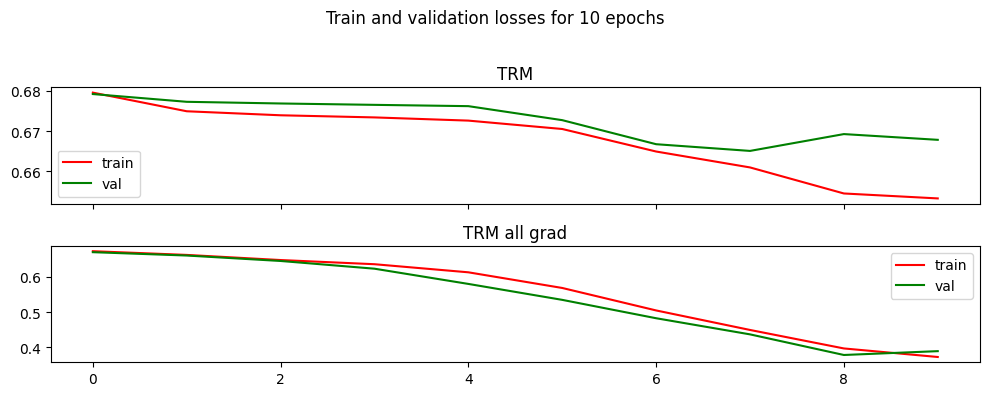

In [353]:
compare_losses(trm_base_circle_10_model,
               trm_allgrad_circle_10_model)

In [354]:
result = display_logs("circle", 10)
result.iloc[[0, -1]]

,model_name,task,num_params,dataset,num_classes,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,initial_train_acc,final_train_acc,initial_val_acc,final_val_acc,overfitting,underfitting,near_random
38,TRM,classification,1243,circle,2.0,10,0.6795,0.6533,0.6791,0.6678,0.5885,0.6105,0.596,0.586,False,True,False
41,TRM all grad,classification,1243,circle,2.0,10,0.6729,0.3725,0.6701,0.3891,0.5850,0.8470,0.596,0.830,False,False,False


### Conclusion

`TRM all grad` performs better than `TRM`.

### 2.1.11. TRM, ACT off

In [355]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=2,
    L_cycles=2,
    num_layers=2,
    halt_max_steps=1,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_noact_circle_10_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    num_epochs=10,
    task="classification",
    num_classes=2
)

trm_noact_circle_10_model.name = "TRM no act"
trm_noact_circle_10_model.dataset = "circle"

log_experiment(trm_noact_circle_10_model)

Training / validation finished
Logging finished


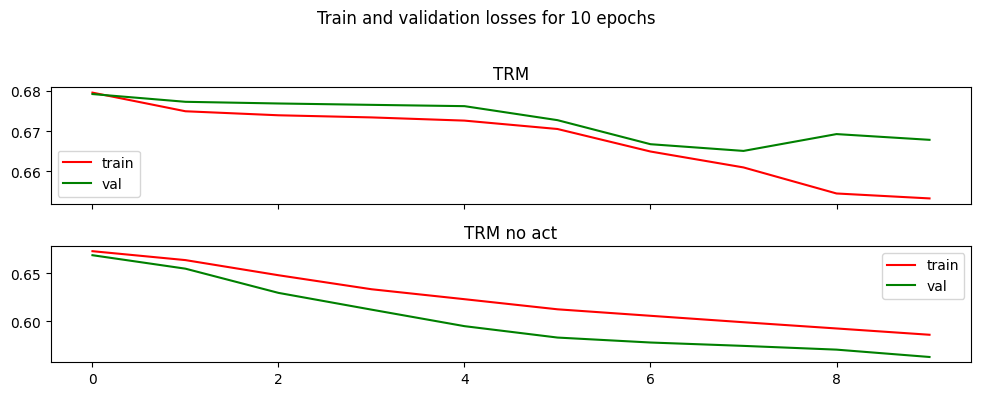

In [356]:
compare_losses(trm_base_circle_10_model,
               trm_noact_circle_10_model)

In [357]:
result = display_logs("circle", 10)
result.iloc[[0, -1]]

,model_name,task,num_params,dataset,num_classes,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,initial_train_acc,final_train_acc,initial_val_acc,final_val_acc,overfitting,underfitting,near_random
38,TRM,classification,1243,circle,2.0,10,0.6795,0.6533,0.6791,0.6678,0.5885,0.6105,0.596,0.586,False,True,False
42,TRM no act,classification,1243,circle,2.0,10,0.6730,0.5860,0.6688,0.5628,0.5925,0.6645,0.596,0.682,False,True,False


### Conclusion

Both models underfit. They have similar initial losses, at final losses comparison `TRM no act` wins.

### 2.1.12. TRM, no self-attention

In [358]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=2,
    L_cycles=2,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
    mlp_t=True
)

trm_nosa_circle_10_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    num_epochs=10,
    task="classification",
    num_classes=2
)

trm_nosa_circle_10_model.name = "TRM no sa"
trm_nosa_circle_10_model.dataset = "circle"

log_experiment(trm_nosa_circle_10_model)

Training / validation finished
Logging finished


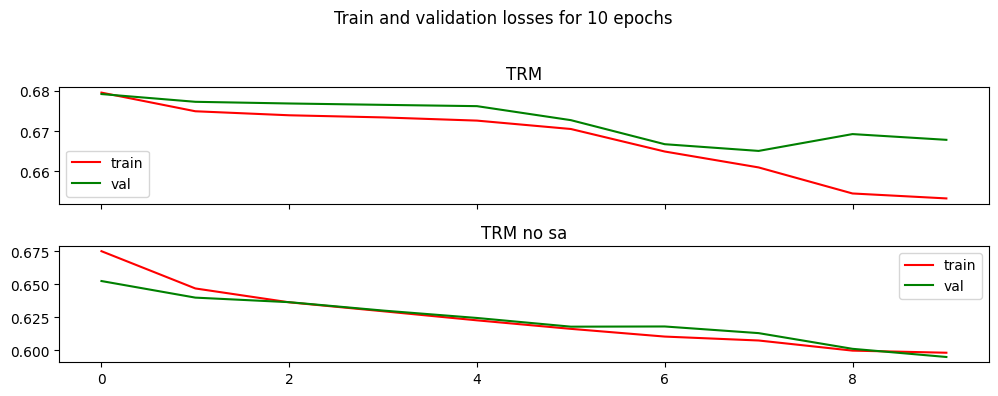

In [359]:
compare_losses(trm_base_circle_10_model,
               trm_nosa_circle_10_model)

In [360]:
result = display_logs("circle", 10)
result.iloc[[0, -1]]

,model_name,task,num_params,dataset,num_classes,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,initial_train_acc,final_train_acc,initial_val_acc,final_val_acc,overfitting,underfitting,near_random
38,TRM,classification,1243,circle,2.0,10,0.6795,0.6533,0.6791,0.6678,0.5885,0.6105,0.596,0.586,False,True,False
43,TRM no sa,classification,681,circle,2.0,10,0.6751,0.5979,0.6524,0.5947,0.5745,0.6385,0.596,0.632,False,True,False


### Conclusion

`TRM no sa` offers less parameters. It does not diverge as `TRM`.

### 2.1.13. TRM, more self-attention heads

In [361]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=2,
    L_cycles=2,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
    num_heads=4
)

trm_4sa_circle_10_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    num_epochs=10,
    task="classification",
    num_classes=2
)

trm_4sa_circle_10_model.name = "TRM 4 sa"
trm_4sa_circle_10_model.dataset = "circle"

log_experiment(trm_4sa_circle_10_model)

Training / validation finished
Logging finished


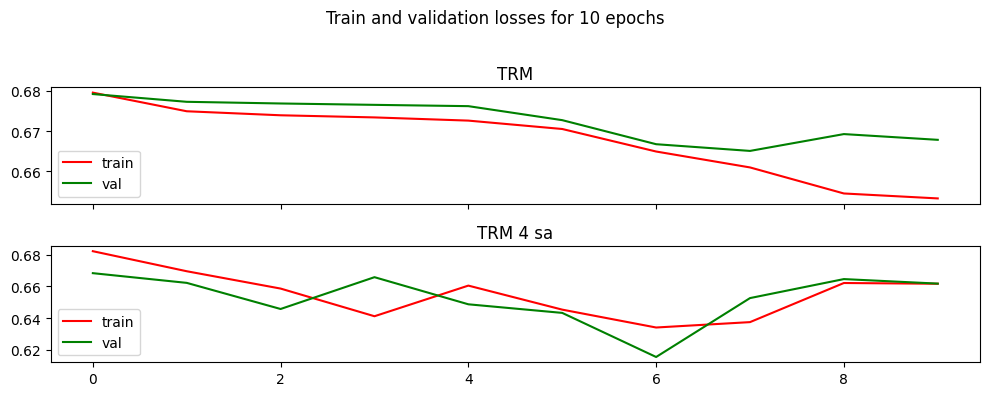

In [362]:
compare_losses(trm_base_circle_10_model,
               trm_4sa_circle_10_model)

In [363]:
result = display_logs("circle", 10)
result.iloc[[0, -1]]

,model_name,task,num_params,dataset,num_classes,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,initial_train_acc,final_train_acc,initial_val_acc,final_val_acc,overfitting,underfitting,near_random
38,TRM,classification,1243,circle,2.0,10,0.6795,0.6533,0.6791,0.6678,0.5885,0.6105,0.596,0.586,False,True,False
44,TRM 4 sa,classification,1243,circle,2.0,10,0.6821,0.6616,0.6683,0.6617,0.5670,0.6015,0.596,0.596,False,True,False


### Conclusion

Both models underfit, however `TRM 4 sa` exhibits unstable behaviour.

### 2.1.14. TRM, more outer loops

In [364]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=4,
    L_cycles=2,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_4h2l_circle_10_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    num_epochs=10,
    task="classification",
    num_classes=2
)

trm_4h2l_circle_10_model.name = "TRM 4H2L"
trm_4h2l_circle_10_model.dataset = "circle"

log_experiment(trm_4h2l_circle_10_model)

Training / validation finished
Logging finished


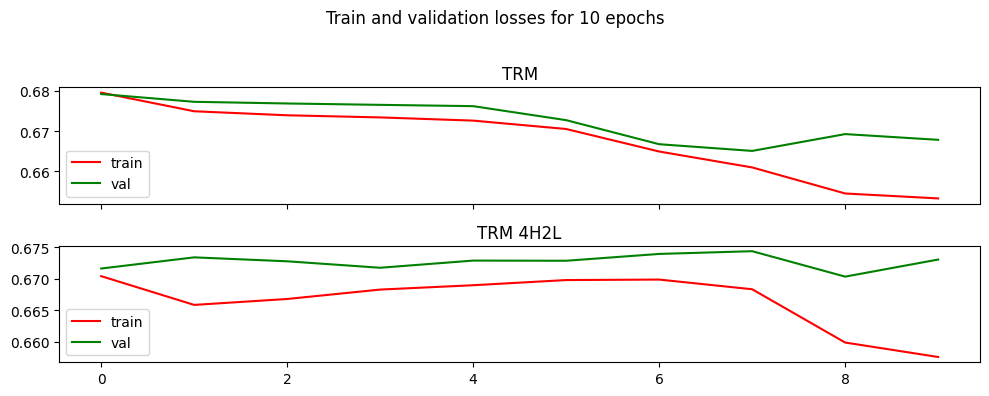

In [365]:
compare_losses(trm_base_circle_10_model,
               trm_4h2l_circle_10_model)

In [366]:
result = display_logs("circle", 10)
result.iloc[[0, -1]]

,model_name,task,num_params,dataset,num_classes,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,initial_train_acc,final_train_acc,initial_val_acc,final_val_acc,overfitting,underfitting,near_random
38,TRM,classification,1243,circle,2.0,10,0.6795,0.6533,0.6791,0.6678,0.5885,0.6105,0.596,0.586,False,True,False
45,TRM 4H2L,classification,1243,circle,2.0,10,0.6704,0.6576,0.6716,0.6731,0.5905,0.6095,0.596,0.604,False,True,False


### Conclusion

`TRM 4H2L` has similar behavious as `TRM`, however it's gap between train-val is bigger.

### 2.1.15. TRM, more inner loops

In [367]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=2,
    L_cycles=4,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_2h4l_circle_10_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    num_epochs=10,
    task="classification",
    num_classes=2
)

trm_2h4l_circle_10_model.name = "TRM 2H4L"
trm_2h4l_circle_10_model.dataset = "circle"

log_experiment(trm_2h4l_circle_10_model)

Training / validation finished
Logging finished


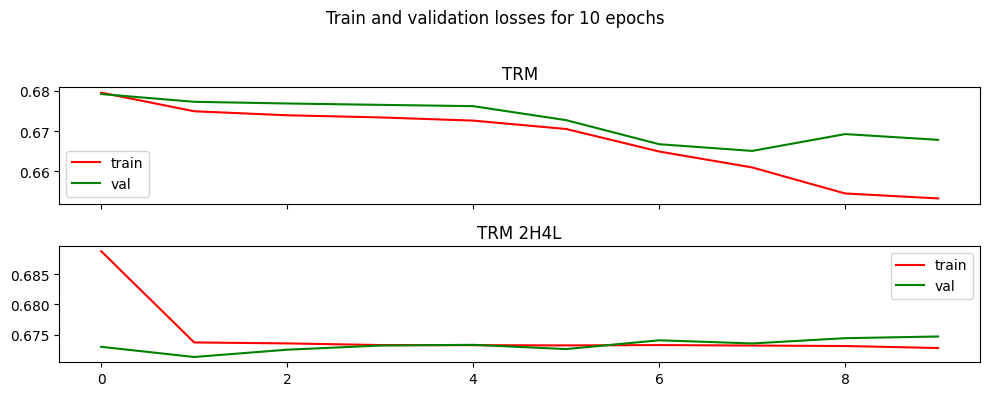

In [368]:
compare_losses(trm_base_circle_10_model,
               trm_2h4l_circle_10_model)

In [369]:
result = display_logs("circle", 10)
result.iloc[[0, -1]]

,model_name,task,num_params,dataset,num_classes,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,initial_train_acc,final_train_acc,initial_val_acc,final_val_acc,overfitting,underfitting,near_random
38,TRM,classification,1243,circle,2.0,10,0.6795,0.6533,0.6791,0.6678,0.5885,0.6105,0.596,0.586,False,True,False
46,TRM 2H4L,classification,1243,circle,2.0,10,0.6888,0.6728,0.6730,0.6747,0.5670,0.6010,0.596,0.596,False,True,False


### Conclusion

`TRM 2H4L` model converges the fastest, although it's loss still remains high.

### 2.1.16. TRM, more computational blocks

In [370]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=2,
    L_cycles=2,
    num_layers=4,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_4blocks_circle_10_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    num_epochs=10,
    task="classification",
    num_classes=2
)

trm_4blocks_circle_10_model.name = "TRM 4 blocks"
trm_4blocks_circle_10_model.dataset = "circle"

log_experiment(trm_4blocks_circle_10_model)

Training / validation finished
Logging finished


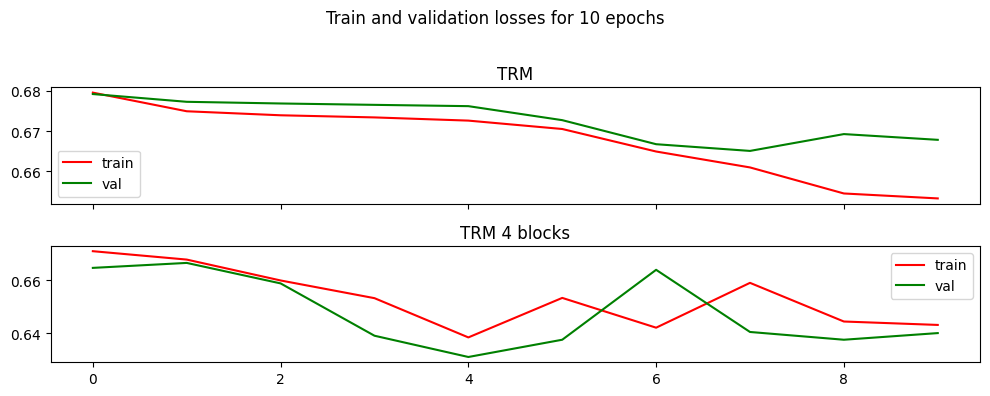

In [371]:
compare_losses(trm_base_circle_10_model,
               trm_4blocks_circle_10_model)

In [372]:
result = display_logs("circle", 10)
result.iloc[[0, -1]]

,model_name,task,num_params,dataset,num_classes,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,initial_train_acc,final_train_acc,initial_val_acc,final_val_acc,overfitting,underfitting,near_random
38,TRM,classification,1243,circle,2.0,10,0.6795,0.6533,0.6791,0.6678,0.5885,0.6105,0.596,0.586,False,True,False
47,TRM 4 blocks,classification,2443,circle,2.0,10,0.6710,0.6432,0.6647,0.6401,0.5970,0.6015,0.616,0.596,False,True,False


### Conclusion

`TRM 4 blocks` has bigger number of parameters, is underfitting and exhibits unstable behaviour.

In [373]:
final_result = display_logs("circle", 10).sort_values(by=["final_train_loss", "final_val_loss"], ascending=[False, False])
final_result = final_result[final_result["model_name"].str.startswith("TRM")]
final_result.style.background_gradient(subset=["final_train_loss", "final_val_loss"], cmap="RdYlGn_r")

,model_name,task,num_params,dataset,num_classes,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,initial_train_acc,final_train_acc,initial_val_acc,final_val_acc,overfitting,underfitting,near_random
46,TRM 2H4L,classification,1243,circle,2.000000,10,0.688800,0.672800,0.673000,0.674700,0.567000,0.601000,0.596000,0.596000,False,True,False
44,TRM 4 sa,classification,1243,circle,2.000000,10,0.682100,0.661600,0.668300,0.661700,0.567000,0.601500,0.596000,0.596000,False,True,False
45,TRM 4H2L,classification,1243,circle,2.000000,10,0.670400,0.657600,0.671600,0.673100,0.590500,0.609500,0.596000,0.604000,False,True,False
38,TRM,classification,1243,circle,2.000000,10,0.679500,0.653300,0.679100,0.667800,0.588500,0.610500,0.596000,0.586000,False,True,False
47,TRM 4 blocks,classification,2443,circle,2.000000,10,0.671000,0.643200,0.664700,0.640100,0.597000,0.601500,0.616000,0.596000,False,True,False
43,TRM no sa,classification,681,circle,2.000000,10,0.675100,0.597900,0.652400,0.594700,0.574500,0.638500,0.596000,0.632000,False,True,False
42,TRM no act,classification,1243,circle,2.000000,10,0.673000,0.586000,0.668800,0.562800,0.592500,0.664500,0.596000,0.682000,False,True,False
39,TRM no rec,classification,1243,circle,2.000000,10,0.651800,0.476600,0.643100,0.499600,0.594000,0.742500,0.586000,0.710000,False,False,False
41,TRM all grad,classification,1243,circle,2.000000,10,0.672900,0.372500,0.670100,0.389100,0.585000,0.847000,0.596000,0.830000,False,False,False


### Conclusion

`TRM all-grad` achieved the strongest performance, reaching the lowest final validation loss (0.3891) and the highest accuracy. Full-gradient formulation clearly enables meaningful iterative refinement.

The TRM without recursion also performed well (0.4996 val loss), even outperforming the standard TRM. This confirms that for a simple binary dataset, multi-step reasoning is unnecessary — a single update step captures the structure fully.

By contrast, deeper TRM variants (4H2L, 4 blocks) and TRMs with ACT consistently performed worse (around 0.64–0.67 val loss). Adding more computation here does not help and instead introduces instability or mild overfitting.

Finally, removing self-attention (`TRM no sa`) significantly degraded performance, showing that self-attention is essential for stable refinement.

Overall, iterative refinement does not emerge on this task — it is too simple. Only TRM all-grad manages to benefit from recursion; the others either plateau or regress.

## 2.2. Binary classification on real data

__ROUND 1.__ Dataset `diabetes2`: whether the patient has diabetes, based on pregnancies, glucose level, blood pressure, skin thickness, insulin, BMI, diabetes pedigree function, and age.

In [374]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv"
df = pd.read_csv(url, header=None)

X_np = df.iloc[:, :-1].values   # (N, 8)
y_np = df.iloc[:, -1].values    # (N,)

X_train_np, X_val_np, y_train_np, y_val_np = train_test_split(
    X_np,
    y_np,
    test_size=0.2,       # 80% train / 20% val
    random_state=42,
    stratify=y_np,       # keep class balance similar
)

scaler = StandardScaler()
X_train_np = scaler.fit_transform(X_train_np)
X_val_np   = scaler.transform(X_val_np)

x_train = torch.tensor(X_train_np, dtype=torch.float32)        # (N_train, D)
y_train = torch.tensor(y_train_np, dtype=torch.float32).unsqueeze(1)  # (N_train, 1)

x_val   = torch.tensor(X_val_np,   dtype=torch.float32)        # (N_val, D)
y_val   = torch.tensor(y_val_np,   dtype=torch.float32).unsqueeze(1)  # (N_val, 1)

D = x_train.shape[1]

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_val shape:",   x_val.shape)
print("y_val shape:",   y_val.shape)
print("hidden_dim:", D)

x_train shape: torch.Size([614, 8])
y_train shape: torch.Size([614, 1])
x_val shape: torch.Size([154, 8])
y_val shape: torch.Size([154, 1])
hidden_dim: 8


### 2.2.1. TRM, 50 epochs

In [375]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=2,
    L_cycles=2,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_base_diabetes2_50_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    task="classification",
    num_classes=2,
)

trm_base_diabetes2_50_model.name = "TRM"
trm_base_diabetes2_50_model.dataset = "diabetes2"

log_experiment(trm_base_diabetes2_50_model)

Training / validation finished
Logging finished


### 2.2.2. TRM no recursion, 50 epochs

In [376]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=1,
    L_cycles=1,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_norec_diabetes2_50_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    task="classification",
    num_classes=2,
)

trm_norec_diabetes2_50_model.name = "TRM no rec"
trm_norec_diabetes2_50_model.dataset = "diabetes2"

log_experiment(trm_norec_diabetes2_50_model)

Training / validation finished
Logging finished


### 2.2.3. MLP, 50 epochs

In [377]:
mlp_diabetes2_50_model, _, _ = train_mlp(
    D,
    x_train, y_train,
    x_val, y_val,
    task="classification",
    num_classes=2,
)

mlp_diabetes2_50_model.name = "MLP"
mlp_diabetes2_50_model.dataset = "diabetes2"

log_experiment(mlp_diabetes2_50_model)

Training / validation finished
Logging finished


### Learning curves

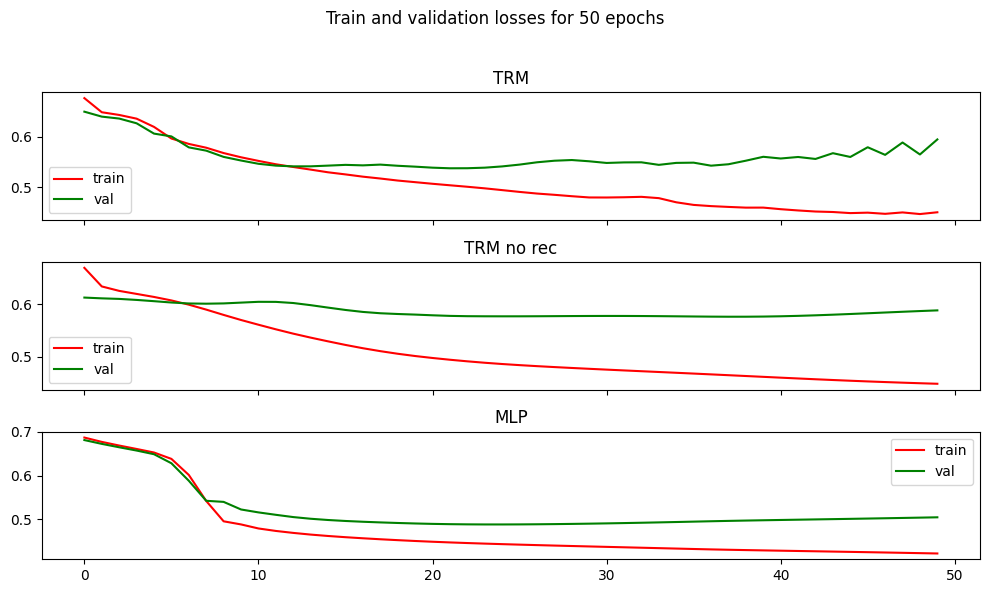

In [378]:
compare_losses(trm_base_diabetes2_50_model,
               trm_norec_diabetes2_50_model,
               mlp_diabetes2_50_model)

In [379]:
display_logs("diabetes2", 50)

,model_name,task,num_params,dataset,num_classes,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,initial_train_acc,final_train_acc,initial_val_acc,final_val_acc,overfitting,underfitting,near_random
48,TRM,classification,1243,diabetes2,2.0,50,0.6757,0.4506,0.6490,0.5943,0.5896,0.7915,0.6558,0.6883,True,False,False
49,TRM no rec,classification,1243,diabetes2,2.0,50,0.6694,0.4480,0.6126,0.5882,0.6189,0.7866,0.7013,0.7273,True,False,False
50,MLP,classification,1129,diabetes2,2.0,50,0.6870,0.4220,0.6812,0.5047,0.6515,0.8013,0.6494,0.7338,False,False,False


### Conclusion

In this case `TRM` and `TRM no grad` both overfit, althoug initial and linal losses for all models are quite low.

### 2.2.4. TRM, 20 epochs

In [380]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=2,
    L_cycles=2,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_base_diabetes2_20_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    task="classification",
    num_classes=2,
    num_epochs=20
)

trm_base_diabetes2_20_model.name = "TRM"
trm_base_diabetes2_20_model.dataset = "diabetes2"

log_experiment(trm_base_diabetes2_20_model)

Training / validation finished
Logging finished


### 2.2.5. TRM no recursion, 20 epochs

In [381]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=1,
    L_cycles=1,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_norec_diabetes2_20_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    task="classification",
    num_classes=2,
    num_epochs=20
)

trm_norec_diabetes2_20_model.name = "TRM no rec"
trm_norec_diabetes2_20_model.dataset = "diabetes2"

log_experiment(trm_norec_diabetes2_20_model)

Training / validation finished
Logging finished


### 2.2.6. MLP, 20 epochs

In [382]:
mlp_diabetes2_20_model, _, _ = train_mlp(
    D,
    x_train, y_train,
    x_val, y_val,
    task="classification",
    num_classes=2,
    num_epochs=20
)

mlp_diabetes2_20_model.name = "MLP"
mlp_diabetes2_20_model.dataset = "diabetes2"

log_experiment(mlp_diabetes2_20_model)

Training / validation finished
Logging finished


### Learning curves

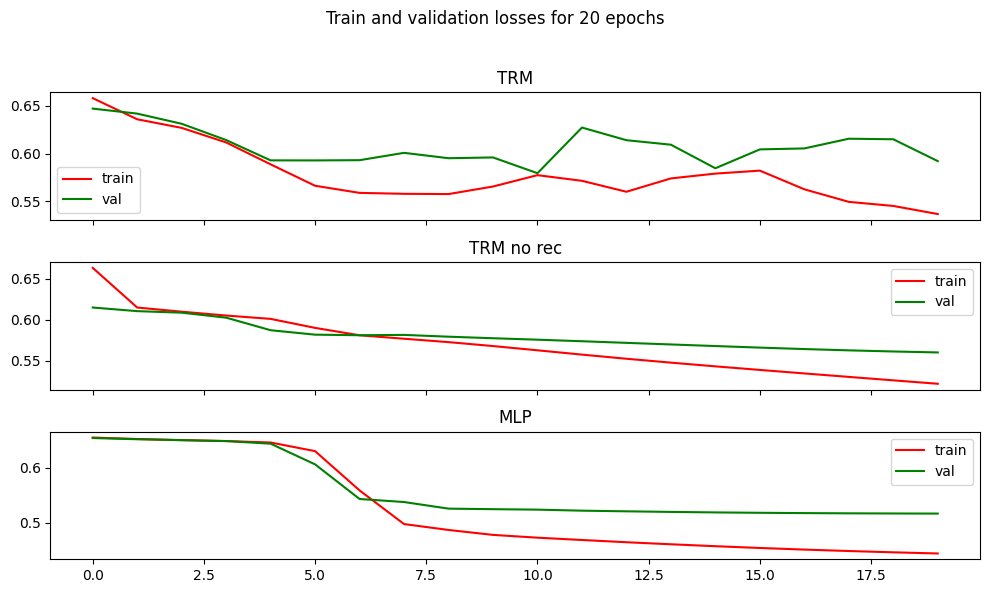

In [383]:
compare_losses(trm_base_diabetes2_20_model,
               trm_norec_diabetes2_20_model,
               mlp_diabetes2_20_model)

In [384]:
display_logs("diabetes2", 20)

,model_name,task,num_params,dataset,num_classes,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,initial_train_acc,final_train_acc,initial_val_acc,final_val_acc,overfitting,underfitting,near_random
51,TRM,classification,1243,diabetes2,2.0,20,0.6581,0.5367,0.6471,0.5921,0.6303,0.7427,0.6494,0.6948,False,True,False
52,TRM no rec,classification,1243,diabetes2,2.0,20,0.6634,0.5220,0.6150,0.5602,0.5928,0.7313,0.6429,0.6948,False,False,False
53,MLP,classification,1129,diabetes2,2.0,20,0.6553,0.4441,0.6544,0.5168,0.6515,0.7899,0.6494,0.7273,False,False,False


### Conclusion

In this case final losses for all three models are low, although `TRM`undefits.

### 2.2.7. TRM, 10 epochs

In [385]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=2,
    L_cycles=2,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_base_diabetes2_10_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    task="classification",
    num_classes=2,
    num_epochs=10
)

trm_base_diabetes2_10_model.name = "TRM"
trm_base_diabetes2_10_model.dataset = "diabetes2"

log_experiment(trm_base_diabetes2_10_model)

Training / validation finished
Logging finished


### 2.2.8. TRM no recursion, 10 epochs

In [386]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=1,
    L_cycles=1,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_norec_diabetes2_10_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    task="classification",
    num_classes=2,
    num_epochs=10
)

trm_norec_diabetes2_10_model.name = "TRM no rec"
trm_norec_diabetes2_10_model.dataset = "diabetes2"

log_experiment(trm_norec_diabetes2_10_model)

Training / validation finished
Logging finished


### 2.2.9. MLP, 10 epochs

In [387]:
mlp_diabetes2_10_model, _, _ = train_mlp(
    D,
    x_train, y_train,
    x_val, y_val,
    task="classification",
    num_classes=2,
    num_epochs=10
)

mlp_diabetes2_10_model.name = "MLP"
mlp_diabetes2_10_model.dataset = "diabetes2"

log_experiment(mlp_diabetes2_10_model)

Training / validation finished
Logging finished


### Learning curves

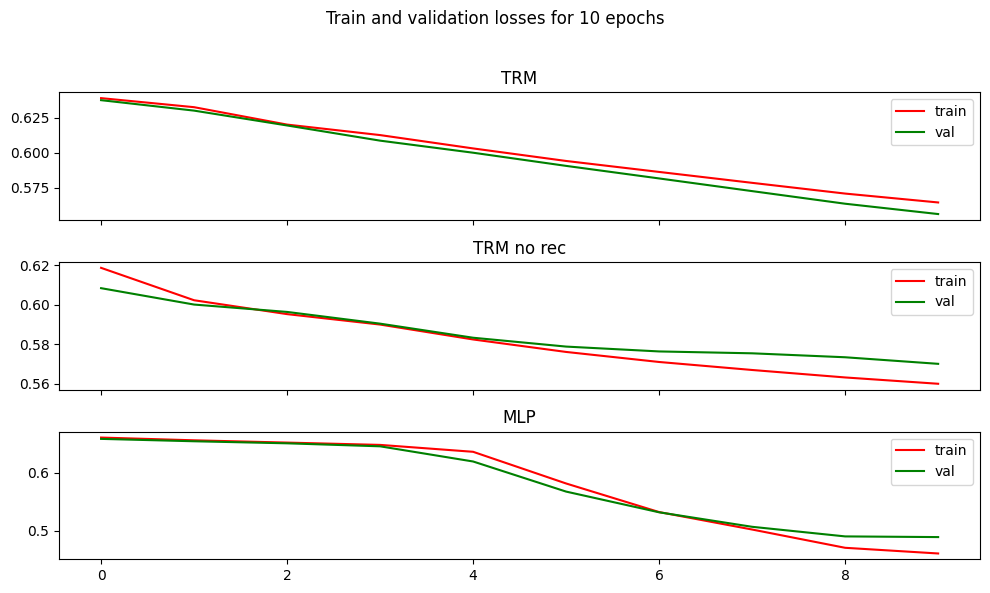

In [388]:
compare_losses(trm_base_diabetes2_10_model,
               trm_norec_diabetes2_10_model,
               mlp_diabetes2_10_model)

In [389]:
display_logs("diabetes2", 10)

,model_name,task,num_params,dataset,num_classes,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,initial_train_acc,final_train_acc,initial_val_acc,final_val_acc,overfitting,underfitting,near_random
54,TRM,classification,1243,diabetes2,2.0,10,0.6390,0.5644,0.6376,0.5561,0.6205,0.7052,0.6494,0.6623,False,True,False
55,TRM no rec,classification,1243,diabetes2,2.0,10,0.6188,0.5599,0.6085,0.5701,0.6694,0.7248,0.6364,0.7013,False,True,False
56,MLP,classification,1129,diabetes2,2.0,10,0.6615,0.4603,0.6592,0.4887,0.6515,0.7655,0.6494,0.7597,False,False,False


### Conclusion

In this case `TRM` and `TRM no rec` both underfit, although final losses for all models are quite low.

### Overview

In [390]:
display_logs("diabetes2", "all")

,model_name,task,num_params,dataset,num_classes,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,initial_train_acc,final_train_acc,initial_val_acc,final_val_acc,overfitting,underfitting,near_random
48,TRM,classification,1243,diabetes2,2.0,50,0.6757,0.4506,0.6490,0.5943,0.5896,0.7915,0.6558,0.6883,True,False,False
49,TRM no rec,classification,1243,diabetes2,2.0,50,0.6694,0.4480,0.6126,0.5882,0.6189,0.7866,0.7013,0.7273,True,False,False
50,MLP,classification,1129,diabetes2,2.0,50,0.6870,0.4220,0.6812,0.5047,0.6515,0.8013,0.6494,0.7338,False,False,False
51,TRM,classification,1243,diabetes2,2.0,20,0.6581,0.5367,0.6471,0.5921,0.6303,0.7427,0.6494,0.6948,False,True,False
52,TRM no rec,classification,1243,diabetes2,2.0,20,0.6634,0.5220,0.6150,0.5602,0.5928,0.7313,0.6429,0.6948,False,False,False
53,MLP,classification,1129,diabetes2,2.0,20,0.6553,0.4441,0.6544,0.5168,0.6515,0.7899,0.6494,0.7273,False,False,False
54,TRM,classification,1243,diabetes2,2.0,10,0.6390,0.5644,0.6376,0.5561,0.6205,0.7052,0.6494,0.6623,False,True,False
55,TRM no rec,classification,1243,diabetes2,2.0,10,0.6188,0.5599,0.6085,0.5701,0.6694,0.7248,0.6364,0.7013,False,True,False
56,MLP,classification,1129,diabetes2,2.0,10,0.6615,0.4603,0.6592,0.4887,0.6515,0.7655,0.6494,0.7597,False,False,False


### Conclusion

`TRM` for binary classification on real data doesn't show uniform behavior: for different duration of learning it can underfit or overfit.

__ROUND 2.__ Effect of different settings.

### 2.2.10. TRM full grad

In [391]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=2,
    L_cycles=2,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
)

trm_allgrad_diabetes2_10_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val,   y_val,
    model_cls=TRMRecOnlyModel,
    num_epochs=10,
    task="classification",
    num_classes=2
)

trm_allgrad_diabetes2_10_model.name = "TRM all grad"
trm_allgrad_diabetes2_10_model.dataset = "diabetes2"

log_experiment(trm_allgrad_diabetes2_10_model)

Training / validation finished
Logging finished


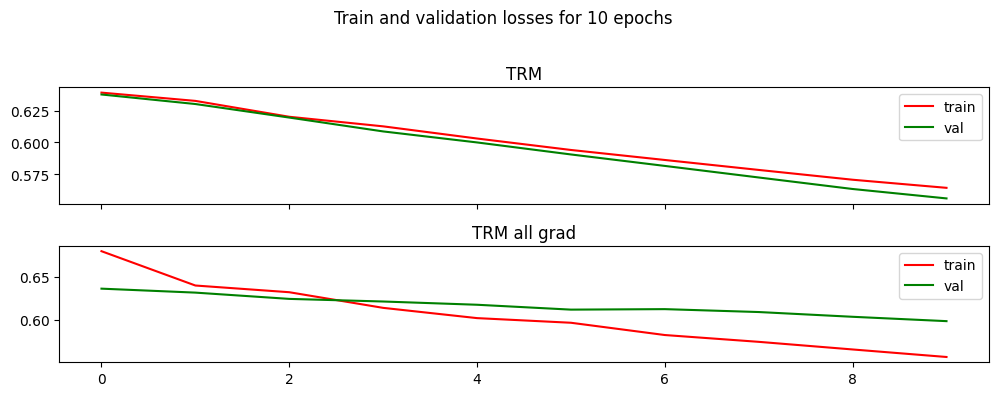

In [392]:
compare_losses(trm_base_diabetes2_10_model,
               trm_allgrad_diabetes2_10_model)

In [393]:
result = display_logs("diabetes2", 10)
result.iloc[[0, -1]]

,model_name,task,num_params,dataset,num_classes,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,initial_train_acc,final_train_acc,initial_val_acc,final_val_acc,overfitting,underfitting,near_random
54,TRM,classification,1243,diabetes2,2.0,10,0.6390,0.5644,0.6376,0.5561,0.6205,0.7052,0.6494,0.6623,False,True,False
57,TRM all grad,classification,1243,diabetes2,2.0,10,0.6793,0.5573,0.6361,0.5986,0.5798,0.7362,0.6753,0.6818,False,True,False


### Conclusion

Fully trained `TRM` didn't solve undefitting problem and didn't increase learning capability.

### 2.2.11. TRM, ACT off

In [394]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=2,
    L_cycles=2,
    num_layers=2,
    halt_max_steps=1,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_noact_diabetes2_10_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    num_epochs=10,
    task="classification",
    num_classes=2
)

trm_noact_diabetes2_10_model.name = "TRM no act"
trm_noact_diabetes2_10_model.dataset = "diabetes2"

log_experiment(trm_noact_diabetes2_10_model)

Training / validation finished
Logging finished


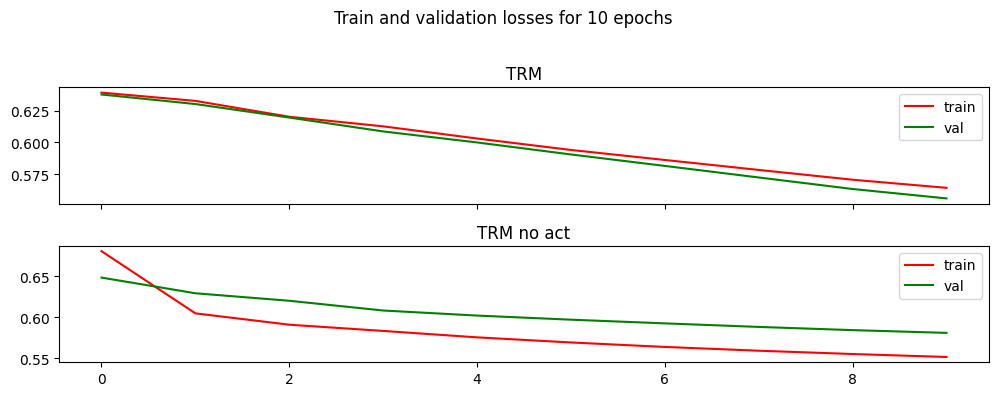

In [395]:
compare_losses(trm_base_diabetes2_10_model,
               trm_noact_diabetes2_10_model)

In [396]:
result = display_logs("diabetes2", 10)
result.iloc[[0, -1]]

,model_name,task,num_params,dataset,num_classes,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,initial_train_acc,final_train_acc,initial_val_acc,final_val_acc,overfitting,underfitting,near_random
54,TRM,classification,1243,diabetes2,2.0,10,0.6390,0.5644,0.6376,0.5561,0.6205,0.7052,0.6494,0.6623,False,True,False
58,TRM no act,classification,1243,diabetes2,2.0,10,0.6802,0.5514,0.6481,0.5807,0.5684,0.7134,0.6234,0.6623,False,True,False


### Conclusion

Absence of adaptive computational time had no effect on `TRM` in terms of undefitting and didn't improve peformance (initial and final losses are overall higher).

### 2.2.12. TRM, no self-attention

In [397]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=2,
    L_cycles=2,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
    mlp_t=True
)

trm_nosa_diabetes2_10_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    num_epochs=10,
    task="classification",
    num_classes=2
)

trm_nosa_diabetes2_10_model.name = "TRM no sa"
trm_nosa_diabetes2_10_model.dataset = "diabetes2"

log_experiment(trm_nosa_diabetes2_10_model)

Training / validation finished
Logging finished


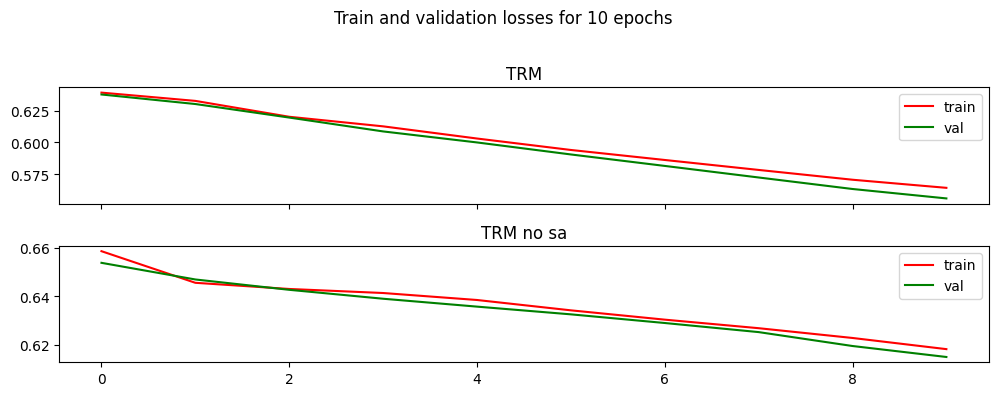

In [398]:
compare_losses(trm_base_diabetes2_10_model,
               trm_nosa_diabetes2_10_model)

In [399]:
result = display_logs("diabetes2", 10)
result.iloc[[0, -1]]

,model_name,task,num_params,dataset,num_classes,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,initial_train_acc,final_train_acc,initial_val_acc,final_val_acc,overfitting,underfitting,near_random
54,TRM,classification,1243,diabetes2,2.0,10,0.6390,0.5644,0.6376,0.5561,0.6205,0.7052,0.6494,0.6623,False,True,False
59,TRM no sa,classification,681,diabetes2,2.0,10,0.6587,0.6181,0.6538,0.6149,0.6466,0.6433,0.6494,0.6364,False,True,False


### Conclusion

Absence of self-attention as well had no effect on `TRM` in terms of undefitting and didn't improve peformance (initial and final losses are overall higher).

### 2.2.13. TRM, more self-attention heads

In [400]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=2,
    L_cycles=2,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
    num_heads=4
)

trm_4sa_diabetes2_10_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    num_epochs=10,
    task="classification",
    num_classes=2
)

trm_4sa_diabetes2_10_model.name = "TRM 4 sa"
trm_4sa_diabetes2_10_model.dataset = "diabetes2"

log_experiment(trm_4sa_diabetes2_10_model)

Training / validation finished
Logging finished


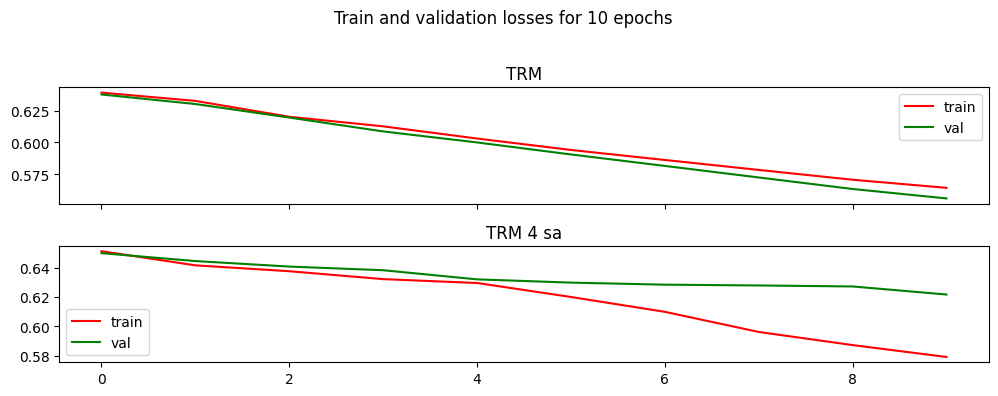

In [401]:
compare_losses(trm_base_diabetes2_10_model,
               trm_4sa_diabetes2_10_model)

In [402]:
result = display_logs("diabetes2", 10)
result.iloc[[0, -1]]

,model_name,task,num_params,dataset,num_classes,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,initial_train_acc,final_train_acc,initial_val_acc,final_val_acc,overfitting,underfitting,near_random
54,TRM,classification,1243,diabetes2,2.0,10,0.6390,0.5644,0.6376,0.5561,0.6205,0.7052,0.6494,0.6623,False,True,False
60,TRM 4 sa,classification,1243,diabetes2,2.0,10,0.6512,0.5791,0.6499,0.6217,0.6450,0.6906,0.6494,0.6494,False,True,False


### Conclusion

Four self-attention heads instead of one, again, had no effect on `TRM` in terms of undefitting and didn't improve peformance (initial and final losses are overall higher).

### 2.2.14. TRM, more outer loops

In [403]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=4,
    L_cycles=2,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_4h2l_diabetes2_10_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    num_epochs=10,
    task="classification",
    num_classes=2
)

trm_4h2l_diabetes2_10_model.name = "TRM 4H2L"
trm_4h2l_diabetes2_10_model.dataset = "diabetes2"

log_experiment(trm_4h2l_diabetes2_10_model)

Training / validation finished
Logging finished


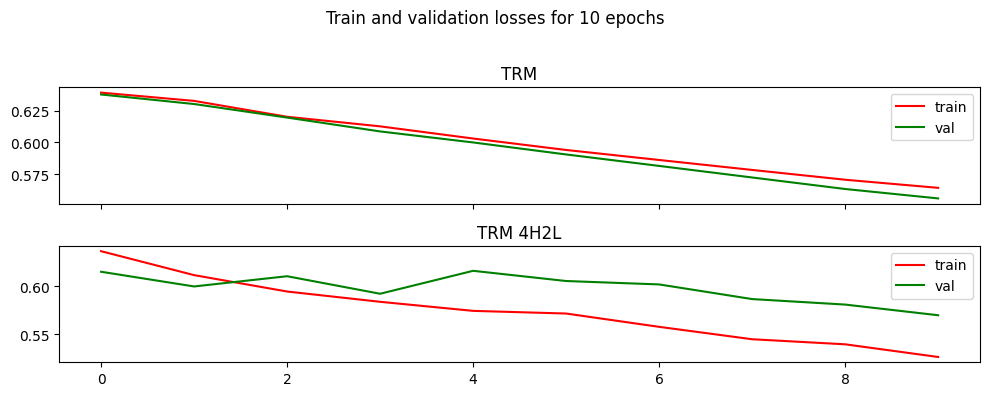

In [404]:
compare_losses(trm_base_diabetes2_10_model,
               trm_4h2l_diabetes2_10_model)

In [405]:
result = display_logs("diabetes2", 10)
result.iloc[[0, -1]]

,model_name,task,num_params,dataset,num_classes,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,initial_train_acc,final_train_acc,initial_val_acc,final_val_acc,overfitting,underfitting,near_random
54,TRM,classification,1243,diabetes2,2.0,10,0.6390,0.5644,0.6376,0.5561,0.6205,0.7052,0.6494,0.6623,False,True,False
61,TRM 4H2L,classification,1243,diabetes2,2.0,10,0.6361,0.5266,0.6148,0.5698,0.6759,0.7524,0.7078,0.6883,False,True,False


### Conclusion

Four outer loops versus two also didn't prevent `TRM` from underfitting.

### 2.2.15. TRM, more inner loops

In [406]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=2,
    L_cycles=4,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_2h4l_diabetes2_10_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    num_epochs=10,
    task="classification",
    num_classes=2
)

trm_2h4l_diabetes2_10_model.name = "TRM 2H4L"
trm_2h4l_diabetes2_10_model.dataset = "diabetes2"

log_experiment(trm_2h4l_diabetes2_10_model)

Training / validation finished
Logging finished


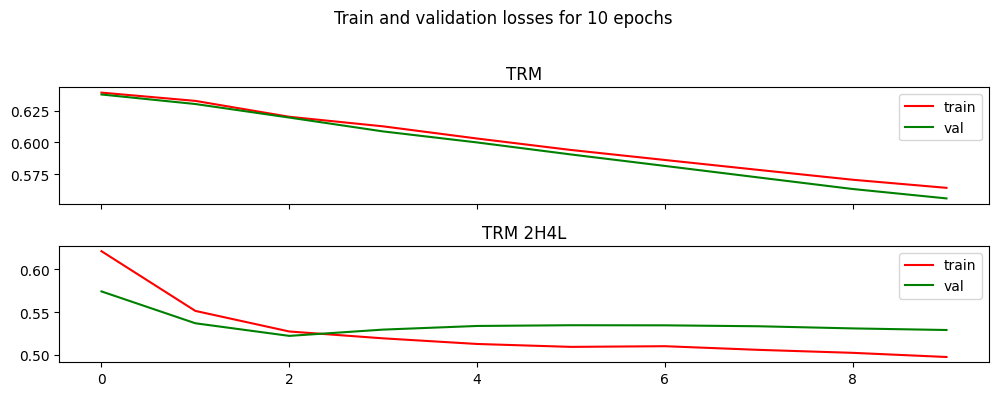

In [407]:
compare_losses(trm_base_diabetes2_10_model,
               trm_2h4l_diabetes2_10_model)

In [408]:
result = display_logs("diabetes2", 10)
result.iloc[[0, -1]]

,model_name,task,num_params,dataset,num_classes,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,initial_train_acc,final_train_acc,initial_val_acc,final_val_acc,overfitting,underfitting,near_random
54,TRM,classification,1243,diabetes2,2.0,10,0.6390,0.5644,0.6376,0.5561,0.6205,0.7052,0.6494,0.6623,False,True,False
62,TRM 2H4L,classification,1243,diabetes2,2.0,10,0.6215,0.4972,0.5742,0.5289,0.6352,0.7866,0.7143,0.7403,False,False,False


### Conclusion

Four inner loops versus two helped to concer undefitting and led to the better model performance: initial and final validation losses are lover than those for trainiig; initial and final validation accuracies are higher than those for training. Adding more inner loops helped `TRM` learn better.

### 2.2.16. TRM, more computational blocks

In [409]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=2,
    L_cycles=2,
    num_layers=4,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_4blocks_diabetes2_10_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    num_epochs=10,
    task="classification",
    num_classes=2
)

trm_4blocks_diabetes2_10_model.name = "TRM 4 blocks"
trm_4blocks_diabetes2_10_model.dataset = "diabetes2"

log_experiment(trm_4blocks_diabetes2_10_model)

Training / validation finished
Logging finished


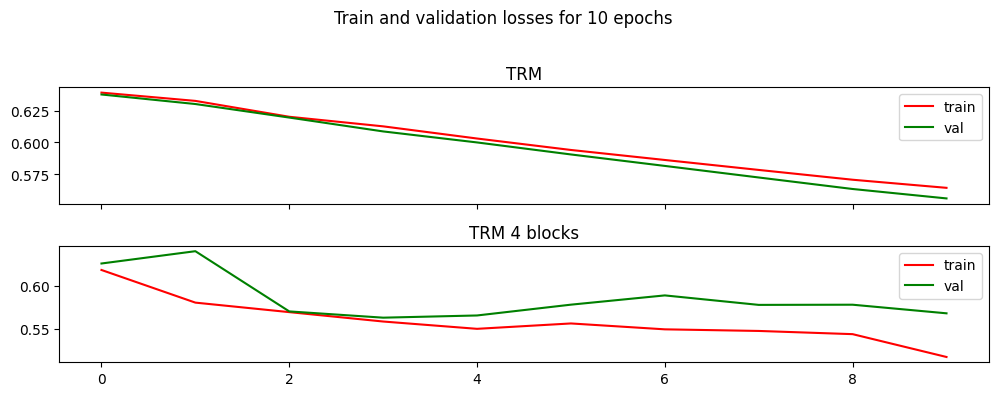

In [410]:
compare_losses(trm_base_diabetes2_10_model,
               trm_4blocks_diabetes2_10_model)

In [411]:
result = display_logs("diabetes2", 10)
result.iloc[[0, -1]]

,model_name,task,num_params,dataset,num_classes,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,initial_train_acc,final_train_acc,initial_val_acc,final_val_acc,overfitting,underfitting,near_random
54,TRM,classification,1243,diabetes2,2.0,10,0.639,0.5644,0.6376,0.5561,0.6205,0.7052,0.6494,0.6623,False,True,False
63,TRM 4 blocks,classification,2443,diabetes2,2.0,10,0.618,0.5173,0.6255,0.5679,0.6759,0.7671,0.6558,0.7338,False,True,False


### Conclusion

More computetional blocks didn't prevent from undefitting. Although train and validation accuracies grew, loss didn't dicrease significantly.

In [412]:
final_result = display_logs("diabetes2", 10).sort_values(by=["final_train_loss", "final_val_loss"], ascending=[False, False])
final_result = final_result[final_result["model_name"].str.startswith("TRM")]
final_result.style.background_gradient(subset=["final_train_loss", "final_val_loss"], cmap="RdYlGn_r")

,model_name,task,num_params,dataset,num_classes,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,initial_train_acc,final_train_acc,initial_val_acc,final_val_acc,overfitting,underfitting,near_random
59,TRM no sa,classification,681,diabetes2,2.000000,10,0.658700,0.618100,0.653800,0.614900,0.646600,0.643300,0.649400,0.636400,False,True,False
60,TRM 4 sa,classification,1243,diabetes2,2.000000,10,0.651200,0.579100,0.649900,0.621700,0.645000,0.690600,0.649400,0.649400,False,True,False
54,TRM,classification,1243,diabetes2,2.000000,10,0.639000,0.564400,0.637600,0.556100,0.620500,0.705200,0.649400,0.662300,False,True,False
55,TRM no rec,classification,1243,diabetes2,2.000000,10,0.618800,0.559900,0.608500,0.570100,0.669400,0.724800,0.636400,0.701300,False,True,False
57,TRM all grad,classification,1243,diabetes2,2.000000,10,0.679300,0.557300,0.636100,0.598600,0.579800,0.736200,0.675300,0.681800,False,True,False
58,TRM no act,classification,1243,diabetes2,2.000000,10,0.680200,0.551400,0.648100,0.580700,0.568400,0.713400,0.623400,0.662300,False,True,False
61,TRM 4H2L,classification,1243,diabetes2,2.000000,10,0.636100,0.526600,0.614800,0.569800,0.675900,0.752400,0.707800,0.688300,False,True,False
63,TRM 4 blocks,classification,2443,diabetes2,2.000000,10,0.618000,0.517300,0.625500,0.567900,0.675900,0.767100,0.655800,0.733800,False,True,False
62,TRM 2H4L,classification,1243,diabetes2,2.000000,10,0.621500,0.497200,0.574200,0.528900,0.635200,0.786600,0.714300,0.740300,False,False,False


### Conclusion

For real data, almost all modifications of `TRM` led to underfitting when trained for 10 epochs. The only effctive modification is `TRM 2H4L` - it prevented underfitting. None of modifications was randomly guessing.

In [413]:
s = display_logs("circle", 10)[["model_name", "final_train_loss", "final_val_loss", "overfitting", "underfitting", "near_random"]]
r = display_logs("diabetes2", 10)[["model_name", "final_train_loss", "final_val_loss", "overfitting", "underfitting", "near_random"]]
m = s.merge(r, on="model_name", suffixes=["_s", "_r"])
m.style.background_gradient(subset=["final_train_loss_s", "final_val_loss_s", "final_train_loss_r", "final_val_loss_r"], cmap="RdYlGn_r")

,model_name,final_train_loss_s,final_val_loss_s,overfitting_s,underfitting_s,near_random_s,final_train_loss_r,final_val_loss_r,overfitting_r,underfitting_r,near_random_r
0,TRM,0.653300,0.667800,False,True,False,0.564400,0.556100,False,True,False
1,TRM no rec,0.476600,0.499600,False,False,False,0.559900,0.570100,False,True,False
2,MLP,0.053300,0.059500,False,False,False,0.460300,0.488700,False,False,False
3,TRM all grad,0.372500,0.389100,False,False,False,0.557300,0.598600,False,True,False
4,TRM no act,0.586000,0.562800,False,True,False,0.551400,0.580700,False,True,False
5,TRM no sa,0.597900,0.594700,False,True,False,0.618100,0.614900,False,True,False
6,TRM 4 sa,0.661600,0.661700,False,True,False,0.579100,0.621700,False,True,False
7,TRM 4H2L,0.657600,0.673100,False,True,False,0.526600,0.569800,False,True,False
8,TRM 2H4L,0.672800,0.674700,False,True,False,0.497200,0.528900,False,False,False
9,TRM 4 blocks,0.643200,0.640100,False,True,False,0.517300,0.567900,False,True,False


### Final conclusions

Overall, `MLP` is the strongest model for the task. It gets the lowest losses on both splits and trains very stable. The task is simple, and `MLP` just learns it fast without any problems.

`TRM no rec` also works quite good. One update step is enough for this dataset, so removing recursion actually helps. It does better than the normal TRM.

Most TRM variants (2H4, 4 blocks, TRM 4 sa, etc.) underfit. They basically "think too much" for such a small binary problem and never reach low validation loss.

`TRM all grad` is the only recursive model that behaves well, because all updates are trained together. Still, it doesn’t beat MLP.

Removing self-attention (`TRM no sa`) breaks learning almost completely.

Conclusion: on a simple datasets like these, iterative refinement does not appear, recursion doesn’t help, and simple models (MLP, 1-step TRM) work best.

On real dataset, though, `TRM 2H4L` performs a bit better and actually benefit from the recursive updates.

# 3. Multi-class classification

## 3.1. Multi-class classification on synthetic data

__ROUND 1.__ Dataset `words`: mapping between words meaning numerals and actual numerals.

In [414]:
DIGIT_WORDS = ["zero","one","two","three","four","five","six","seven","eight","nine"]
NUM_CLASSES = len(DIGIT_WORDS)

# build alphabet from all characters in the digit words
ALPHABET = sorted({ch for w in DIGIT_WORDS for ch in w})
CHAR2IDX = {ch: i for i, ch in enumerate(ALPHABET)}
ALPHABET_SIZE = len(ALPHABET)

MAX_LEN = max(len(w) for w in DIGIT_WORDS)  # should be 5


def encode_word_as_flat_onehot(word: str) -> torch.Tensor:
    """
    Encode a word as a (MAX_LEN * ALPHABET_SIZE,) float tensor.

    - Each position up to len(word) is one-hot over ALPHABET.
    - Remaining positions are all zeros (padding).
    """
    x = torch.zeros(MAX_LEN, ALPHABET_SIZE, dtype=torch.float32)

    for pos, ch in enumerate(word):
        if pos >= MAX_LEN:
            break
        j = CHAR2IDX[ch]
        x[pos, j] = 1.0

    # flatten to (MAX_LEN * ALPHABET_SIZE,)
    return x.view(-1)


def make_digit_char_dataset(num_samples: int):
    """
    Synthetic multi-class dataset:

      Input:  x_emb  (N, D)   where D = MAX_LEN * ALPHABET_SIZE
              each row is a flattened char-level one-hot encoding of a digit word

      Target: y_true (N,)     integer class 0..9 (digit index)
    """
    # sample random digit indices 0..9
    idx = torch.randint(0, NUM_CLASSES, (num_samples,))  # (N,)

    # encode each chosen word
    x_list = []
    for i in idx:
        word = DIGIT_WORDS[int(i.item())]
        x_vec = encode_word_as_flat_onehot(word)   # (D,)
        x_list.append(x_vec)

    x_emb = torch.stack(x_list, dim=0)  # (N, D)
    y_true = idx                        # (N,)

    return x_emb, y_true


torch.manual_seed(0)

# build train / val
x_train, y_train = make_digit_char_dataset(num_samples=2000)
x_val,   y_val   = make_digit_char_dataset(num_samples=500)

D = x_train.shape[1]

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_val shape:",   x_val.shape)
print("y_val shape:",   y_val.shape)
print("hidden_dim:", D)

x_train shape: torch.Size([2000, 75])
y_train shape: torch.Size([2000])
x_val shape: torch.Size([500, 75])
y_val shape: torch.Size([500])
hidden_dim: 75


### 3.1.1. TRM, 50 epochs

In [415]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=2,
    L_cycles=2,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_base_words_50_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    task="classification",
    num_classes=10
)

trm_base_words_50_model.name = "TRM"
trm_base_words_50_model.dataset = "words"

log_experiment(trm_base_words_50_model)

Training / validation finished
Logging finished


### 3.1.2. TRM no recursion, 50 epochs

In [416]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=1,
    L_cycles=1,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_norec_words_50_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    task="classification",
    num_classes=10
)

trm_norec_words_50_model.name = "TRM no rec"
trm_norec_words_50_model.dataset = "words"

log_experiment(trm_norec_words_50_model)

Training / validation finished
Logging finished


### 3.1.3. MLP, 50 epochs

In [417]:
mlp_words_50_model, _, _ = train_mlp(
    D,
    x_train, y_train,
    x_val, y_val,
    task="classification",
    num_classes=10,
)

mlp_words_50_model.name = "MLP"
mlp_words_50_model.dataset = "words"

log_experiment(mlp_words_50_model)

Training / validation finished
Logging finished


### Learning curves

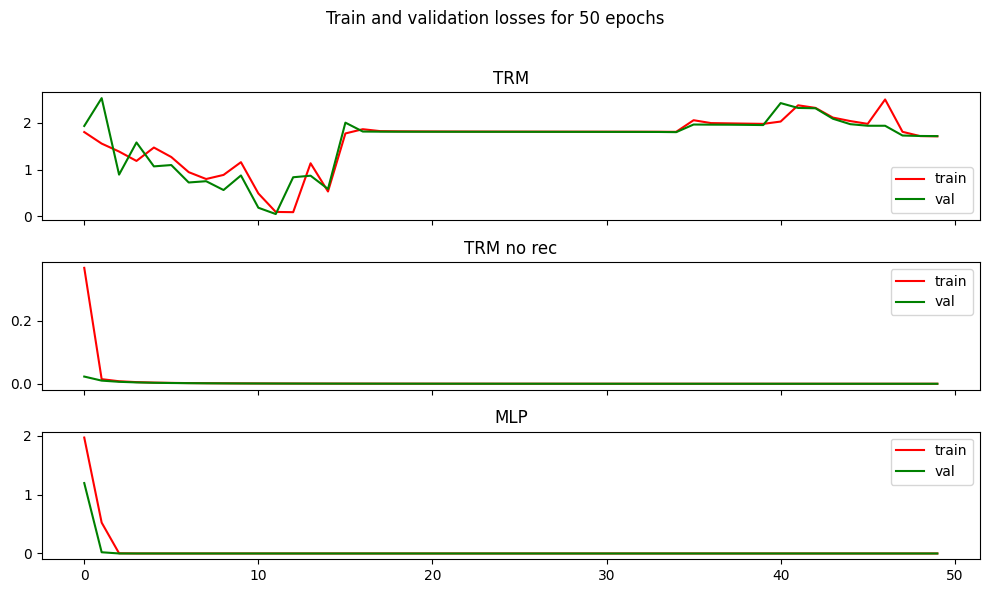

In [418]:
compare_losses(trm_base_words_50_model,
               trm_norec_words_50_model,
               mlp_words_50_model)

In [419]:
display_logs("words", 50)

,model_name,task,num_params,dataset,num_classes,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,initial_train_acc,final_train_acc,initial_val_acc,final_val_acc,overfitting,underfitting,near_random
64,TRM,classification,92712,words,10.0,50,1.7979,1.7072,1.9275,1.7117,0.3540,0.1965,0.198,0.206,False,True,False
65,TRM no rec,classification,92712,words,10.0,50,0.3678,0.0001,0.0229,0.0001,0.9335,1.0000,1.000,1.000,False,False,False
66,MLP,classification,91660,words,10.0,50,1.9686,0.0000,1.1957,0.0000,0.2025,1.0000,0.516,1.000,False,False,False


### Conclusion

`TRM` shows quite interesting and unstable behavior, while other models converge.

### 3.1.4. TRM, 20 epochs

In [420]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=2,
    L_cycles=2,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_base_words_20_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    task="classification",
    num_classes=10,
    num_epochs=20
)

trm_base_words_20_model.name = "TRM"
trm_base_words_20_model.dataset = "words"

log_experiment(trm_base_words_20_model)

Training / validation finished
Logging finished


### 3.1.5. TRM no recursion, 20 epochs

In [421]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=1,
    L_cycles=1,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_norec_words_20_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    task="classification",
    num_classes=10,
    num_epochs=20
)

trm_norec_words_20_model.name = "TRM no rec"
trm_norec_words_20_model.dataset = "words"

log_experiment(trm_norec_words_20_model)

Training / validation finished
Logging finished


### 3.1.6. MLP, 20 epochs

In [422]:
mlp_words_20_model, _, _ = train_mlp(
    D,
    x_train, y_train,
    x_val, y_val,
    task="classification",
    num_classes=10,
    num_epochs=20
)

mlp_words_20_model.name = "MLP"
mlp_words_20_model.dataset = "words"

log_experiment(mlp_words_20_model)

Training / validation finished
Logging finished


### Learning curves

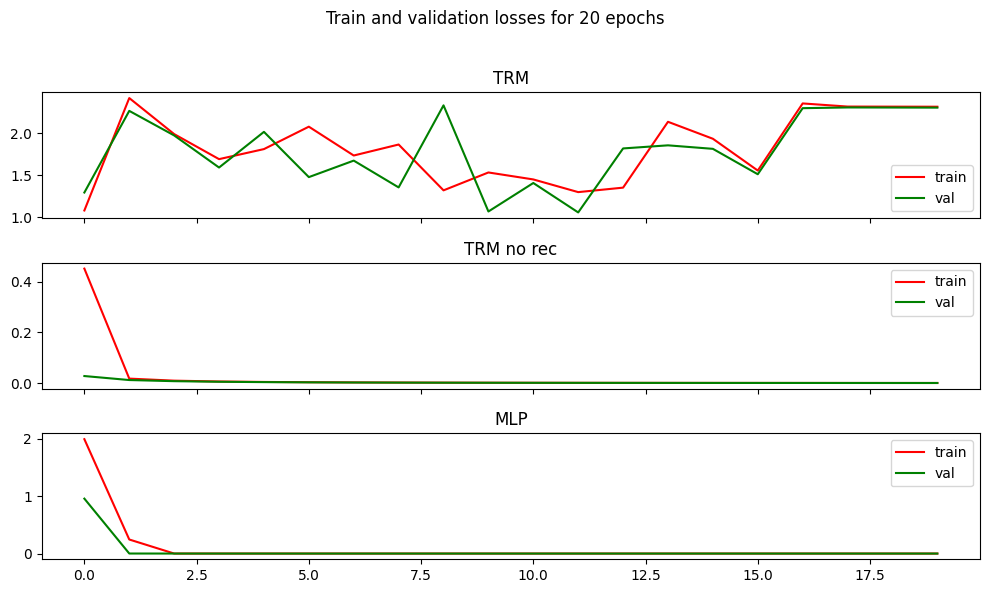

In [423]:
compare_losses(trm_base_words_20_model,
               trm_norec_words_20_model,
               mlp_words_20_model)

In [424]:
display_logs("words", 20)

,model_name,task,num_params,dataset,num_classes,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,initial_train_acc,final_train_acc,initial_val_acc,final_val_acc,overfitting,underfitting,near_random
67,TRM,classification,92712,words,10.0,20,1.0795,2.3169,1.2936,2.3059,0.6360,0.0925,0.392,0.106,False,True,True
68,TRM no rec,classification,92712,words,10.0,20,0.4519,0.0004,0.0279,0.0004,0.9145,1.0000,1.000,1.000,False,False,False
69,MLP,classification,91660,words,10.0,20,1.9950,0.0000,0.9579,0.0000,0.1965,1.0000,0.690,1.000,False,False,False


### Conclusion

Samw as for 5o epochs.

### 3.1.7. TRM, 10 epochs

In [425]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=2,
    L_cycles=2,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_base_words_10_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    task="classification",
    num_classes=10,
    num_epochs=10
)

trm_base_words_10_model.name = "TRM"
trm_base_words_10_model.dataset = "words"

log_experiment(trm_base_words_10_model)

Training / validation finished
Logging finished


### 3.1.8. TRM no recursion, 10 epochs

In [426]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=1,
    L_cycles=1,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_norec_words_10_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    task="classification",
    num_classes=10,
    num_epochs=10
)

trm_norec_words_10_model.name = "TRM no rec"
trm_norec_words_10_model.dataset = "words"

log_experiment(trm_norec_words_10_model)

Training / validation finished
Logging finished


### 3.1.9. MLP, 10 epochs

In [427]:
mlp_words_10_model, _, _ = train_mlp(
    D,
    x_train, y_train,
    x_val, y_val,
    task="classification",
    num_classes=10,
    num_epochs=10
)

mlp_words_10_model.name = "MLP"
mlp_words_10_model.dataset = "words"

log_experiment(mlp_words_10_model)

Training / validation finished
Logging finished


### Learning curves

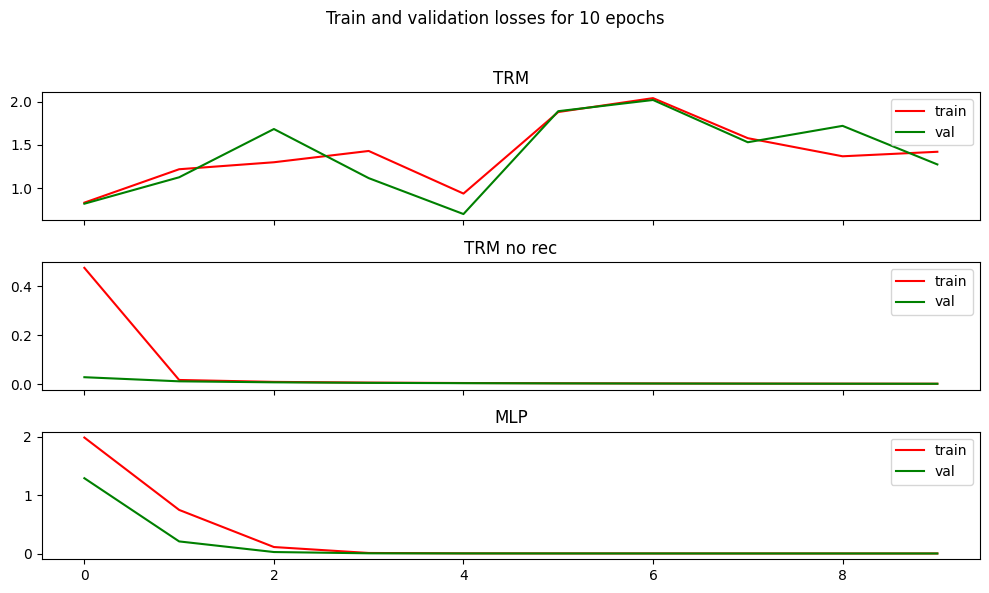

In [428]:
compare_losses(trm_base_words_10_model,
               trm_norec_words_10_model,
               mlp_words_10_model)

In [429]:
display_logs("words", 10)

,model_name,task,num_params,dataset,num_classes,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,initial_train_acc,final_train_acc,initial_val_acc,final_val_acc,overfitting,underfitting,near_random
70,TRM,classification,92712,words,10.0,10,0.8332,1.4210,0.8210,1.2747,0.7760,0.36,0.700,0.506,False,True,False
71,TRM no rec,classification,92712,words,10.0,10,0.4764,0.0016,0.0283,0.0014,0.8890,1.00,1.000,1.000,False,False,False
72,MLP,classification,91660,words,10.0,10,1.9820,0.0004,1.2869,0.0003,0.1825,1.00,0.472,1.000,False,False,False


### Conclusion

Same as for 50 epochs

### Overview

In [430]:
display_logs("words", "all")

,model_name,task,num_params,dataset,num_classes,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,initial_train_acc,final_train_acc,initial_val_acc,final_val_acc,overfitting,underfitting,near_random
64,TRM,classification,92712,words,10.0,50,1.7979,1.7072,1.9275,1.7117,0.3540,0.1965,0.198,0.206,False,True,False
65,TRM no rec,classification,92712,words,10.0,50,0.3678,0.0001,0.0229,0.0001,0.9335,1.0000,1.000,1.000,False,False,False
66,MLP,classification,91660,words,10.0,50,1.9686,0.0000,1.1957,0.0000,0.2025,1.0000,0.516,1.000,False,False,False
67,TRM,classification,92712,words,10.0,20,1.0795,2.3169,1.2936,2.3059,0.6360,0.0925,0.392,0.106,False,True,True
68,TRM no rec,classification,92712,words,10.0,20,0.4519,0.0004,0.0279,0.0004,0.9145,1.0000,1.000,1.000,False,False,False
69,MLP,classification,91660,words,10.0,20,1.9950,0.0000,0.9579,0.0000,0.1965,1.0000,0.690,1.000,False,False,False
70,TRM,classification,92712,words,10.0,10,0.8332,1.4210,0.8210,1.2747,0.7760,0.3600,0.700,0.506,False,True,False
71,TRM no rec,classification,92712,words,10.0,10,0.4764,0.0016,0.0283,0.0014,0.8890,1.0000,1.000,1.000,False,False,False
72,MLP,classification,91660,words,10.0,10,1.9820,0.0004,1.2869,0.0003,0.1825,1.0000,0.472,1.000,False,False,False


### Conclusion

From this expiriment we can make a conclusion that recursion is actually damaging for the training procedure. If we take away recursion or use `MLP` we can see that training procedure stabilizes and converges to high accuracy very quickly (over 1, 2 epoch). Therefore, from the synthetic data we can make a hypothesis that `TRM` is unstable and expensive model.

Also, we trained for different numbers of epoch to see, which number is optimal.

__ROUND 2.__ Effect of different settings.

### 3.1.10. TRM full grad

In [431]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=2,
    L_cycles=2,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
)

trm_allgrad_words_10_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val,   y_val,
    model_cls=TRMRecOnlyModel,
    num_epochs=10,
    task="classification",
    num_classes=10,
)

trm_allgrad_words_10_model.name = "TRM all grad"
trm_allgrad_words_10_model.dataset = "words"

log_experiment(trm_allgrad_words_10_model)

Training / validation finished
Logging finished


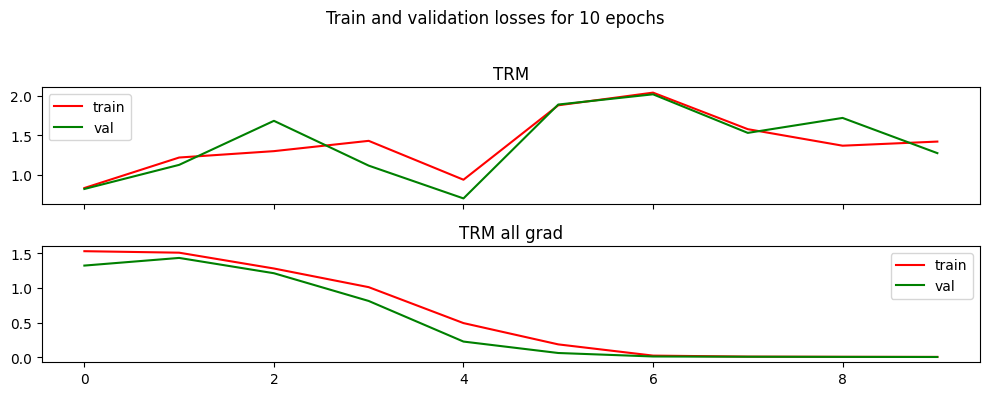

In [432]:
compare_losses(trm_base_words_10_model,
               trm_allgrad_words_10_model)

In [433]:
result = display_logs("words", 10)
result.iloc[[0, -1]]

,model_name,task,num_params,dataset,num_classes,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,initial_train_acc,final_train_acc,initial_val_acc,final_val_acc,overfitting,underfitting,near_random
70,TRM,classification,92712,words,10.0,10,0.8332,1.4210,0.8210,1.2747,0.776,0.36,0.700,0.506,False,True,False
73,TRM all grad,classification,92712,words,10.0,10,1.5268,0.0077,1.3201,0.0070,0.369,1.00,0.318,1.000,False,False,False


### Conclusion

If we track all gradients, we can see that training becomes smoth and converges to low loss. Therefore, we can make a hypothesis that based on synthetic data, mechanism, which was implemented to decrease computational costs, actually damages the training procedure and makes it inefficient

### 3.1.11. TRM, ACT off

In [434]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=2,
    L_cycles=2,
    num_layers=2,
    halt_max_steps=1,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_noact_words_10_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    num_epochs=10,
    task="classification",
    num_classes=10,
)

trm_noact_words_10_model.name = "TRM no act"
trm_noact_words_10_model.dataset = "words"

log_experiment(trm_noact_words_10_model)

Training / validation finished
Logging finished


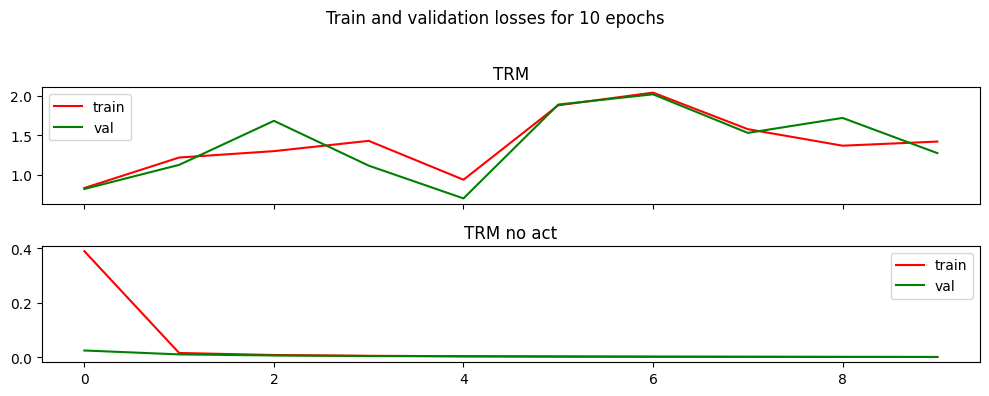

In [435]:
compare_losses(trm_base_words_10_model,
               trm_noact_words_10_model)

In [436]:
result = display_logs("words", 10)
result.iloc[[0, -1]]

,model_name,task,num_params,dataset,num_classes,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,initial_train_acc,final_train_acc,initial_val_acc,final_val_acc,overfitting,underfitting,near_random
70,TRM,classification,92712,words,10.0,10,0.8332,1.4210,0.8210,1.2747,0.7760,0.36,0.7,0.506,False,True,False
74,TRM no act,classification,92712,words,10.0,10,0.3889,0.0014,0.0251,0.0013,0.9265,1.00,1.0,1.000,False,False,False


### Conclusion

Without ACT TRM is able to start from lower loss and converge quickly. Also The training procedure becomes smooth. Therefore, from the synthetic data we can make a hypothesis that ACT is not that needed.

### 3.1.12. TRM, no self-attention

In [437]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=2,
    L_cycles=2,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
    mlp_t=True
)

trm_nosa_words_10_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    num_epochs=10,
    task="classification",
    num_classes=10,
)

trm_nosa_words_10_model.name = "TRM no sa"
trm_nosa_words_10_model.dataset = "words"

log_experiment(trm_nosa_words_10_model)

Training / validation finished
Logging finished


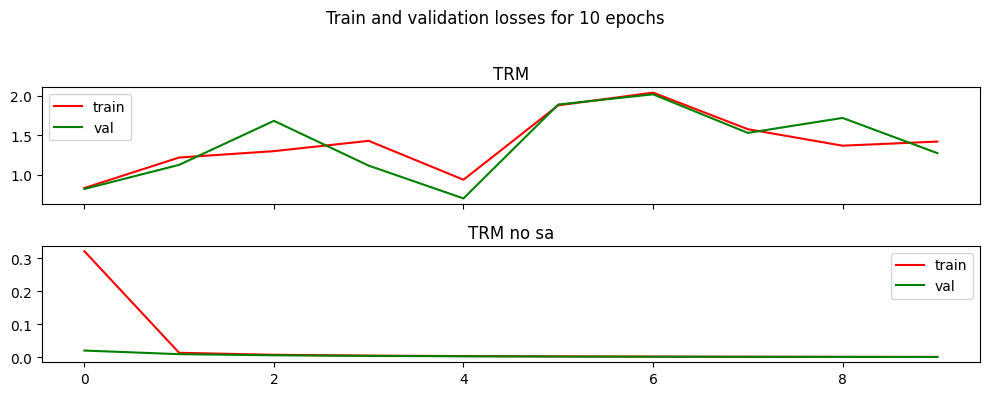

In [438]:
compare_losses(trm_base_words_10_model,
               trm_nosa_words_10_model)

In [439]:
result = display_logs("words", 10)
result.iloc[[0, -1]]

,model_name,task,num_params,dataset,num_classes,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,initial_train_acc,final_train_acc,initial_val_acc,final_val_acc,overfitting,underfitting,near_random
70,TRM,classification,92712,words,10.0,10,0.8332,1.4210,0.8210,1.2747,0.776,0.36,0.7,0.506,False,True,False
75,TRM no sa,classification,47126,words,10.0,10,0.3214,0.0013,0.0206,0.0012,0.943,1.00,1.0,1.000,False,False,False


### Conclusion

Again, we see that self attention, one of important parts of `TRM`, makes training unstable

### 3.1.13. TRM, more self-attention heads

In [440]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=2,
    L_cycles=2,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
    num_heads=5
)

trm_4sa_words_10_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    num_epochs=10,
    task="classification",
    num_classes=10,
)

trm_4sa_words_10_model.name = "TRM 4 sa"
trm_4sa_words_10_model.dataset = "words"

log_experiment(trm_4sa_words_10_model)

Training / validation finished
Logging finished


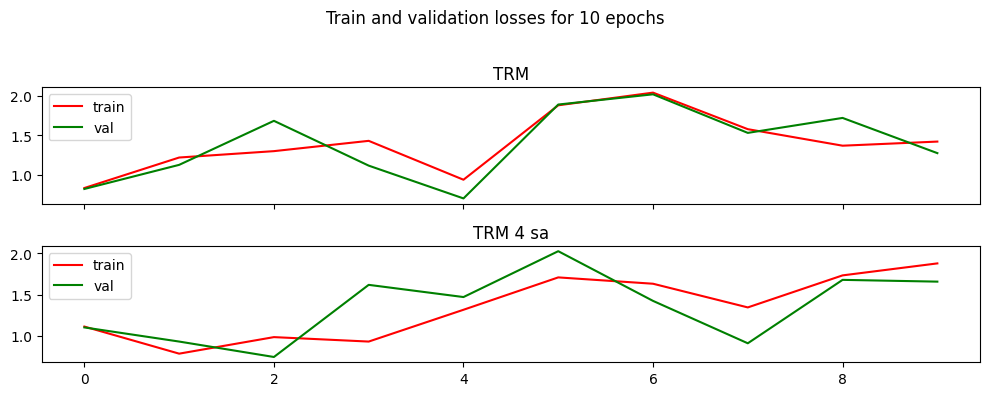

In [441]:
compare_losses(trm_base_words_10_model,
               trm_4sa_words_10_model)

In [442]:
result = display_logs("words", 10)
result.iloc[[0, -1]]

,model_name,task,num_params,dataset,num_classes,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,initial_train_acc,final_train_acc,initial_val_acc,final_val_acc,overfitting,underfitting,near_random
70,TRM,classification,92712,words,10.0,10,0.8332,1.4210,0.8210,1.2747,0.7760,0.360,0.700,0.506,False,True,False
76,TRM 4 sa,classification,92712,words,10.0,10,1.1127,1.8775,1.1023,1.6568,0.6325,0.286,0.672,0.294,False,True,False


### Conclusion

After increasinfg the number of self-attention heads we can see that final validation loss has increased, and although tarining is unstable, we can make a hypothesis that self-attention is extremely damaging

### 3.1.14. TRM, more outer loops

In [443]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=4,
    L_cycles=2,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_4h2l_words_10_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    num_epochs=10,
    task="classification",
    num_classes=10,
)

trm_4h2l_words_10_model.name = "TRM 4H2L"
trm_4h2l_words_10_model.dataset = "words"

log_experiment(trm_4h2l_words_10_model)

Training / validation finished
Logging finished


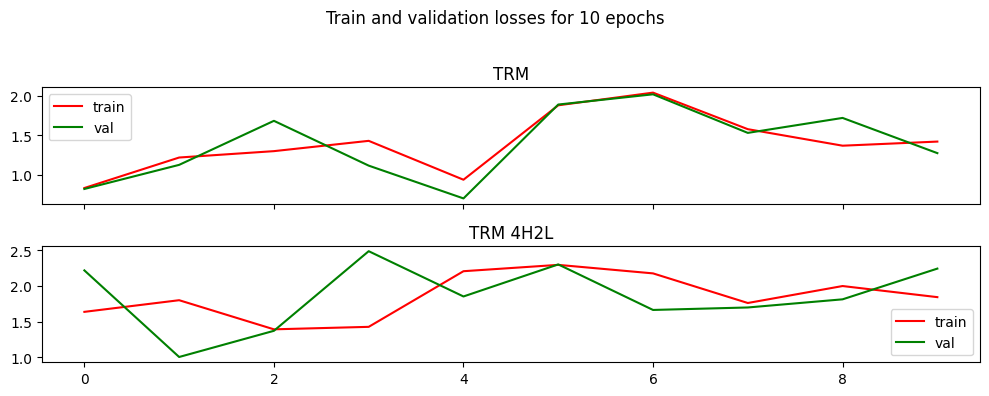

In [444]:
compare_losses(trm_base_words_10_model,
               trm_4h2l_words_10_model)

In [445]:
result = display_logs("words", 10)
result.iloc[[0, -1]]

,model_name,task,num_params,dataset,num_classes,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,initial_train_acc,final_train_acc,initial_val_acc,final_val_acc,overfitting,underfitting,near_random
70,TRM,classification,92712,words,10.0,10,0.8332,1.4210,0.8210,1.2747,0.7760,0.3600,0.700,0.506,False,True,False
77,TRM 4H2L,classification,92712,words,10.0,10,1.6370,1.8433,2.2182,2.2432,0.4055,0.2325,0.512,0.188,False,True,False


### Conclusion

Although final validation loss is smaller after adding more outerloops, model remains unstable and final loss highly depends on number of epochs. Therefore, no reliable conclusion can be made

### 3.1.15. TRM, more inner loops

In [446]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=2,
    L_cycles=4,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_2h4l_words_10_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    num_epochs=10,
    task="classification",
    num_classes=10,
)

trm_2h4l_words_10_model.name = "TRM 2H4L"
trm_2h4l_words_10_model.dataset = "words"

log_experiment(trm_2h4l_words_10_model)

Training / validation finished
Logging finished


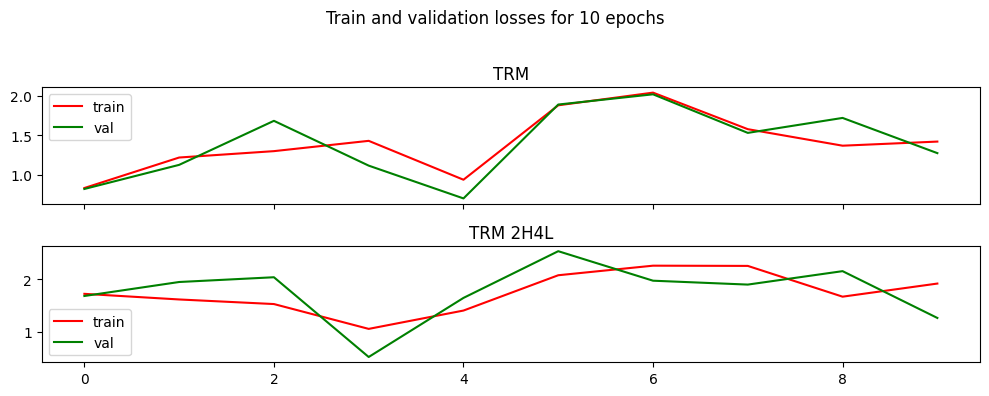

In [447]:
compare_losses(trm_base_words_10_model,
               trm_2h4l_words_10_model)

In [448]:
result = display_logs("words", 10)
result.iloc[[0, -1]]

,model_name,task,num_params,dataset,num_classes,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,initial_train_acc,final_train_acc,initial_val_acc,final_val_acc,overfitting,underfitting,near_random
70,TRM,classification,92712,words,10.0,10,0.8332,1.4210,0.8210,1.2747,0.7760,0.3600,0.700,0.506,False,True,False
78,TRM 2H4L,classification,92712,words,10.0,10,1.7246,1.9208,1.6836,1.2644,0.3475,0.2635,0.412,0.592,False,True,False


### Conclusion

Same situation as for increased outter loops - no reliable conclusion can be made because of instabilty

### 3.1.16. TRM, more computational blocks

In [449]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=2,
    L_cycles=2,
    num_layers=4,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_4blocks_words_10_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    num_epochs=10,
    task="classification",
    num_classes=10,
)

trm_4blocks_words_10_model.name = "TRM 4 blocks"
trm_4blocks_words_10_model.dataset = "words"

log_experiment(trm_4blocks_words_10_model)

Training / validation finished
Logging finished


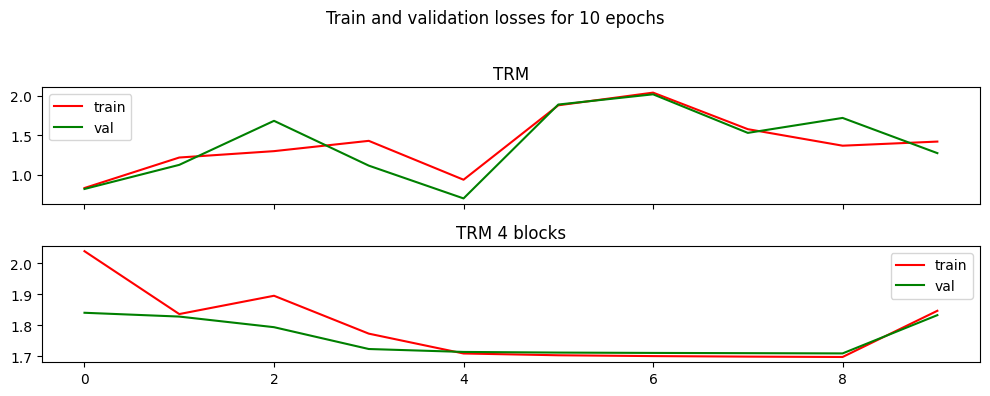

In [450]:
compare_losses(trm_base_words_10_model,
               trm_4blocks_words_10_model)

In [451]:
result = display_logs("words", 10)
result.iloc[[0, -1]]

,model_name,task,num_params,dataset,num_classes,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,initial_train_acc,final_train_acc,initial_val_acc,final_val_acc,overfitting,underfitting,near_random
70,TRM,classification,92712,words,10.0,10,0.8332,1.4210,0.8210,1.2747,0.7760,0.3600,0.700,0.506,False,True,False
79,TRM 4 blocks,classification,184362,words,10.0,10,2.0390,1.8471,1.8407,1.8331,0.1805,0.1925,0.176,0.198,False,True,False


### Conclusion

With more computational blocks moddel became stable but the valiadtion loss is slightly better than random guessing. Therefore, on synthetic data it doesn't make sence to have more computational blocks

In [452]:
final_result = display_logs("words", 10).sort_values(by=["final_train_loss", "final_val_loss"], ascending=[False, False])
final_result = final_result[final_result["model_name"].str.startswith("TRM")]
final_result.style.background_gradient(subset=["final_train_loss", "final_val_loss"], cmap="RdYlGn_r")

,model_name,task,num_params,dataset,num_classes,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,initial_train_acc,final_train_acc,initial_val_acc,final_val_acc,overfitting,underfitting,near_random
78,TRM 2H4L,classification,92712,words,10.000000,10,1.724600,1.920800,1.683600,1.264400,0.347500,0.263500,0.412000,0.592000,False,True,False
76,TRM 4 sa,classification,92712,words,10.000000,10,1.112700,1.877500,1.102300,1.656800,0.632500,0.286000,0.672000,0.294000,False,True,False
79,TRM 4 blocks,classification,184362,words,10.000000,10,2.039000,1.847100,1.840700,1.833100,0.180500,0.192500,0.176000,0.198000,False,True,False
77,TRM 4H2L,classification,92712,words,10.000000,10,1.637000,1.843300,2.218200,2.243200,0.405500,0.232500,0.512000,0.188000,False,True,False
70,TRM,classification,92712,words,10.000000,10,0.833200,1.421000,0.821000,1.274700,0.776000,0.360000,0.700000,0.506000,False,True,False
73,TRM all grad,classification,92712,words,10.000000,10,1.526800,0.007700,1.320100,0.007000,0.369000,1.000000,0.318000,1.000000,False,False,False
71,TRM no rec,classification,92712,words,10.000000,10,0.476400,0.001600,0.028300,0.001400,0.889000,1.000000,1.000000,1.000000,False,False,False
74,TRM no act,classification,92712,words,10.000000,10,0.388900,0.001400,0.025100,0.001300,0.926500,1.000000,1.000000,1.000000,False,False,False
75,TRM no sa,classification,47126,words,10.000000,10,0.321400,0.001300,0.020600,0.001200,0.943000,1.000000,1.000000,1.000000,False,False,False


### Conclusion

Overall oll features which define `TRM` turned out to be useless. There might be two reasins, either task was easy (which is likely as in the beggining MLP converged very quickly) or the tabular data is unsuitable for `TRM`. to check that we will take a look at real data - wine quality dataset, which has more complex classification task

## 3.2. Multi-class classification on real data

__ROUND 1.__ Dataset `wines`: wine's class label indicating which of three grape cultivars it comes from based on 13 chemical and physical properties of each wine sample.

In [453]:
class TabularDataset(Dataset):
    def __init__(self, X, y):
        """
        X: np.ndarray or torch.Tensor (num_samples, num_features)
        y: np.ndarray or torch.Tensor (num_samples,)
        """
        if isinstance(X, np.ndarray):
            X = torch.from_numpy(X).float()
        if isinstance(y, np.ndarray):
            # classification -> long
            y = torch.from_numpy(y).long()
        self.X = X
        self.y = y

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def inject_label_noise(y, noise_level, num_classes, rng=None):
    """
    y: np.ndarray of ints (class labels)
    noise_level: float in [0,1], probability of corrupting each label
    num_classes: K
    rng: np.random.Generator or None
    """
    if rng is None:
        rng = np.random.default_rng()

    y_noisy = y.copy()
    n = len(y)
    mask = rng.random(n) < noise_level
    num_noisy = mask.sum()
    if num_noisy == 0:
        return y_noisy

    random_labels = rng.integers(low=0, high=num_classes, size=num_noisy)
    y_noisy[mask] = random_labels
    return y_noisy

In [454]:
def prepare_wine_dataloaders(
    batch_size=128,
    val_size=0.2,
    test_size=0.2,
    noise_level=0.0,
    seed=42,
    standardize=True,
    shuffle_train=True,
):
    """
    Returns:
        loaders: dict with 'train', 'val', 'test' DataLoaders
        meta: dict with dataset metadata
    """
    rng = np.random.default_rng(seed)

    data = load_wine()
    X = data['data']           # shape (n_samples, n_features)
    y = data['target']         # shape (n_samples,)
    num_classes = len(np.unique(y))

    # First split off test
    X_trainval_wine, X_test_wine, y_trainval_wine, y_test_wine = train_test_split(
        X, y, test_size=test_size, random_state=seed, stratify=y
    )

    # Then split train/val
    val_relative = val_size / (1.0 - test_size)
    X_train_wine, X_val_wine, y_train_wine, y_val_wine = train_test_split(
        X_trainval_wine, y_trainval_wine,
        test_size=val_relative,
        random_state=seed,
        stratify=y_trainval_wine
    )

    # Standardization (fit on train only)
    if standardize:
        scaler = StandardScaler()
        X_train_wine = scaler.fit_transform(X_train_wine)
        X_val_wine = scaler.transform(X_val_wine)
        X_test_wine = scaler.transform(X_test_wine)
    else:
        scaler = None

    # Optional label noise on TRAIN ONLY
    if noise_level > 0.0:
        y_train = inject_label_noise(y_train, noise_level, num_classes, rng=rng)

    # Build datasets & loaders
    train_ds = TabularDataset(X_train_wine, y_train_wine)
    val_ds   = TabularDataset(X_val_wine, y_val_wine)
    test_ds  = TabularDataset(X_test_wine, y_test_wine)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=shuffle_train)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    loaders = {
        'train': train_loader,
        'val': val_loader,
        'test': test_loader,
    }

    meta = {
        'num_features': X.shape[1],
        'num_classes': num_classes,
        'scaler': scaler,
        'class_names': data.get('target_names', None),
        'dataset_name': 'wine',
    }

    return loaders, meta

In [455]:
# 1. Load dataset
loaders_wine, meta_wine = prepare_wine_dataloaders(
    batch_size=128,
    val_size=0.2,
    test_size=0.2,
    noise_level=0.0,
)

# Helper: convert DataLoader → numpy arrays
def dataloader_to_numpy(dataloader):
    X_list, y_list = [], []
    for X, y in dataloader:
        X_list.append(X.numpy())
        y_list.append(y.numpy())
    return np.concatenate(X_list, axis=0), np.concatenate(y_list, axis=0)

# 2. Build train/val/test arrays
x_train_wine, y_train_wine = dataloader_to_numpy(loaders_wine['train'])
x_val_wine,   y_val_wine   = dataloader_to_numpy(loaders_wine['val'])

x_train = torch.from_numpy(x_train_wine).float()
y_train = torch.from_numpy(y_train_wine).float()

x_val = torch.from_numpy(x_val_wine).float()
y_val = torch.from_numpy(y_val_wine).float()

D = x_train.shape[1]

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_val shape:",   x_val.shape)
print("y_val shape:",   y_val.shape)
print("hidden_dim:", D)

x_train shape: torch.Size([106, 13])
y_train shape: torch.Size([106])
x_val shape: torch.Size([36, 13])
y_val shape: torch.Size([36])
hidden_dim: 13


### 3.2.1. TRM, 50 epochs

In [460]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=2,
    L_cycles=2,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_base_wines_50_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    task="classification",
    num_classes=10
)

trm_base_wines_50_model.name = "TRM"
trm_base_wines_50_model.dataset = "wines"

log_experiment(trm_base_wines_50_model)

Training / validation finished
Logging finished


### 3.2.2. TRM no recursion, 50 epochs

In [461]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=1,
    L_cycles=1,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_norec_wines_50_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    task="classification",
    num_classes=7,
)

trm_norec_wines_50_model.name = "TRM no rec"
trm_norec_wines_50_model.dataset = "wines"

log_experiment(trm_norec_wines_50_model)

Training / validation finished
Logging finished


### 3.2.3. MLP, 50 epochs

In [462]:
mlp_wines_50_model, _, _ = train_mlp(
    D,
    x_train, y_train,
    x_val, y_val,
    task="classification",
    num_classes=7,
)

mlp_wines_50_model.name = "MLP"
mlp_wines_50_model.dataset = "wines"

log_experiment(mlp_wines_50_model)

Training / validation finished
Logging finished


### Learning curves

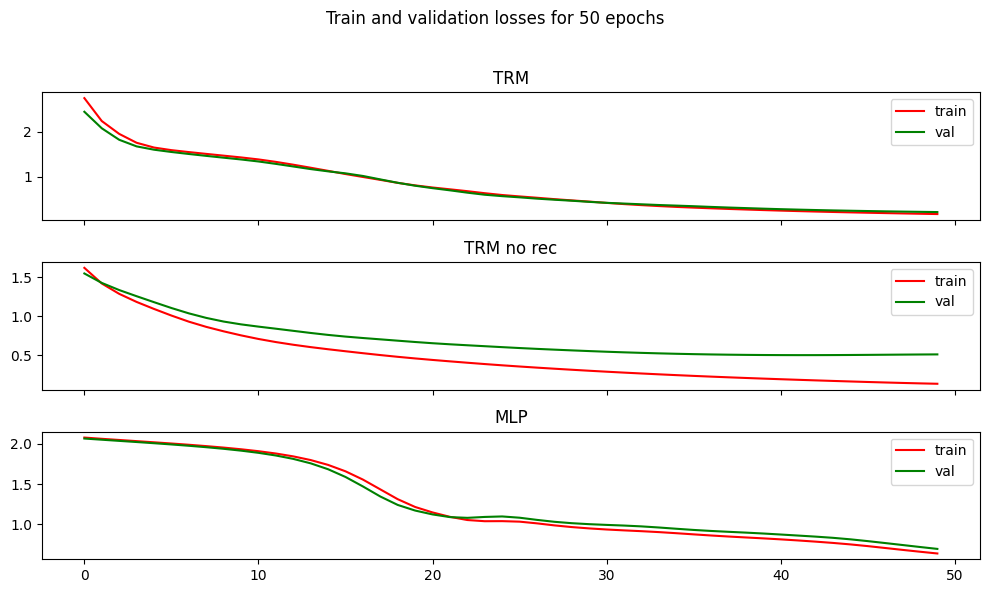

In [463]:
compare_losses(trm_base_wines_50_model,
               trm_norec_wines_50_model,
               mlp_wines_50_model)

In [464]:
display_logs("wines", 50)

,model_name,task,num_params,dataset,num_classes,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,initial_train_acc,final_train_acc,initial_val_acc,final_val_acc,overfitting,underfitting,near_random
81,TRM no rec,classification,3142,wines,7.0,50,2.2306,0.0821,1.9710,0.3058,0.2170,1.0000,0.3056,0.9167,True,False,False
82,MLP,classification,2958,wines,7.0,50,2.0120,0.3625,2.0035,0.4361,0.0000,0.7358,0.0000,0.6944,False,False,False
83,TRM,classification,3184,wines,10.0,50,2.7553,0.1662,2.4508,0.2104,0.0472,0.9906,0.1667,0.9722,False,False,False
84,TRM no rec,classification,3142,wines,7.0,50,1.6180,0.1346,1.5460,0.5104,0.4811,0.9906,0.4722,0.8889,True,False,False
85,MLP,classification,2958,wines,7.0,50,2.0765,0.6384,2.0643,0.6952,0.0000,0.7358,0.0000,0.6944,False,False,False


### Conclusions

After entire "50/20/10 epochs" block.

### 3.2.4. TRM, 20 epochs

In [465]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=2,
    L_cycles=2,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_base_wines_20_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    task="classification",
    num_classes=7,
    num_epochs=20
)

trm_base_wines_20_model.name = "TRM"
trm_base_wines_20_model.dataset = "wines"

log_experiment(trm_base_wines_20_model)

Training / validation finished
Logging finished


### 3.2.5. TRM no recursion, 20 epochs

In [466]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=1,
    L_cycles=1,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_norec_wines_20_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    task="classification",
    num_classes=7,
    num_epochs=20
)

trm_norec_wines_20_model.name = "TRM no rec"
trm_norec_wines_20_model.dataset = "wines"

log_experiment(trm_norec_wines_20_model)

Training / validation finished
Logging finished


### 3.2.6. MLP, 20 epochs

In [467]:
mlp_wines_20_model, _, _ = train_mlp(
    D,
    x_train, y_train,
    x_val, y_val,
    task="classification",
    num_classes=7,
    num_epochs=20
)

mlp_wines_20_model.name = "MLP"
mlp_wines_20_model.dataset = "wines"

log_experiment(mlp_wines_20_model)

Training / validation finished
Logging finished


### Learning curves

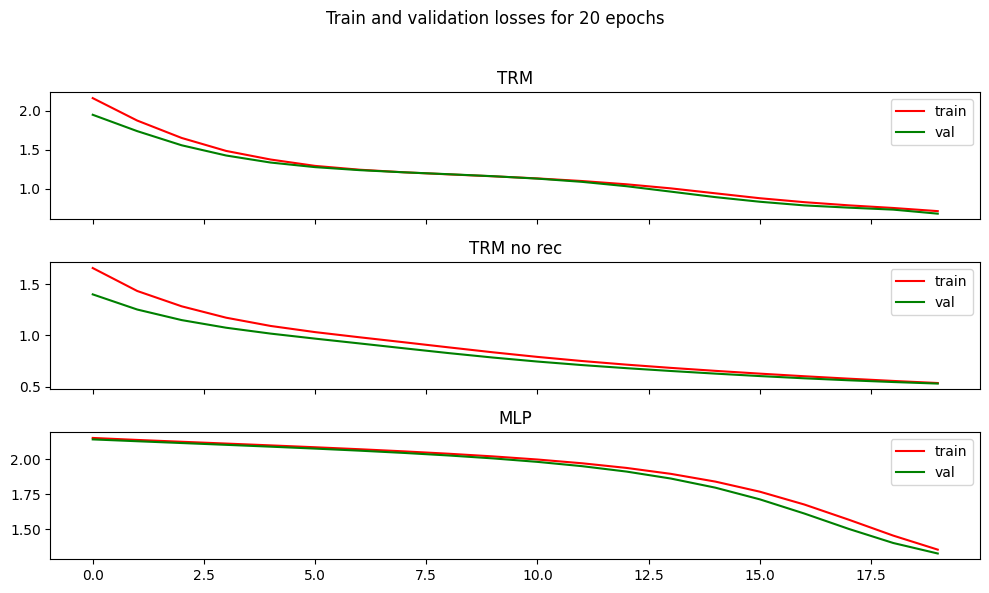

In [468]:
compare_losses(trm_base_wines_20_model,
               trm_norec_wines_20_model,
               mlp_wines_20_model)

In [469]:
display_logs("wines", 20)

,model_name,task,num_params,dataset,num_classes,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,initial_train_acc,final_train_acc,initial_val_acc,final_val_acc,overfitting,underfitting,near_random
86,TRM,classification,3142,wines,7.0,20,2.1584,0.7170,1.9458,0.6846,0.0566,0.8585,0.1667,0.8611,False,False,False
87,TRM no rec,classification,3142,wines,7.0,20,1.6575,0.5342,1.4002,0.5288,0.4434,0.8962,0.5000,0.9167,False,False,False
88,MLP,classification,2958,wines,7.0,20,2.1532,1.3556,2.1428,1.3280,0.0000,0.4057,0.0000,0.3889,False,False,False


### 3.2.7. TRM, 10 epochs

In [470]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=2,
    L_cycles=2,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_base_wines_10_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    task="classification",
    num_classes=7,
    num_epochs=10
)

trm_base_wines_10_model.name = "TRM"
trm_base_wines_10_model.dataset = "wines"

log_experiment(trm_base_wines_10_model)

Training / validation finished
Logging finished


### 3.2.8. TRM no recursion, 10 epochs

In [471]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=1,
    L_cycles=1,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_norec_wines_10_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    task="classification",
    num_classes=7,
    num_epochs=10
)

trm_norec_wines_10_model.name = "TRM no rec"
trm_norec_wines_10_model.dataset = "wines"

log_experiment(trm_norec_wines_10_model)

Training / validation finished
Logging finished


### 3.2.9. MLP, 10 epochs

In [472]:
mlp_wines_10_model, _, _ = train_mlp(
    D,
    x_train, y_train,
    x_val, y_val,
    task="classification",
    num_classes=7,
    num_epochs=10
)

mlp_wines_10_model.name = "MLP"
mlp_wines_10_model.dataset = "wines"

log_experiment(mlp_wines_10_model)

Training / validation finished
Logging finished


### Learning curves

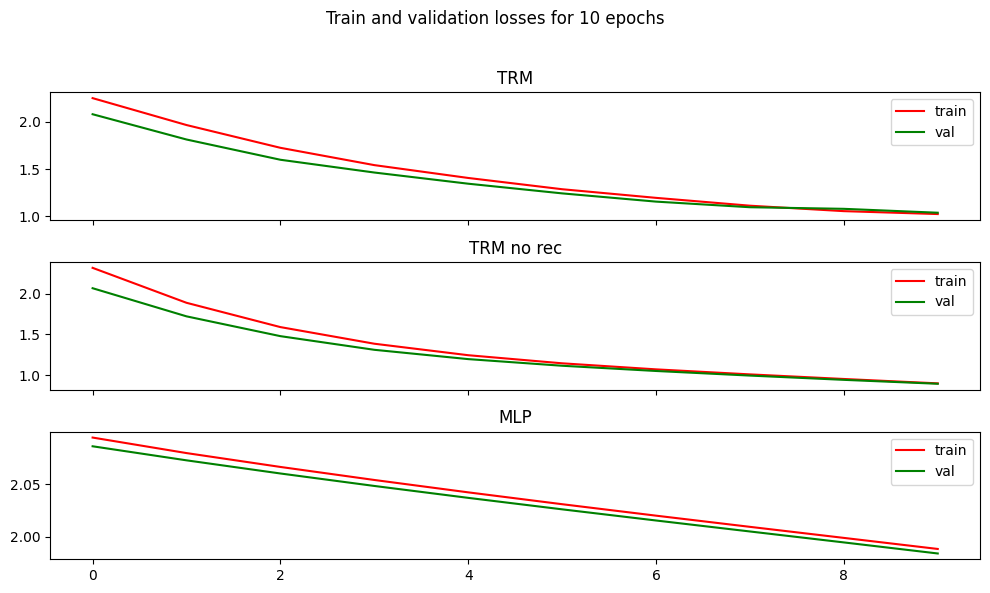

In [473]:
compare_losses(trm_base_wines_10_model,
               trm_norec_wines_10_model,
               mlp_wines_10_model)

In [474]:
display_logs("wines", 10)

,model_name,task,num_params,dataset,num_classes,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,initial_train_acc,final_train_acc,initial_val_acc,final_val_acc,overfitting,underfitting,near_random
89,TRM,classification,3142,wines,7.0,10,2.2502,1.0236,2.0798,1.0376,0.0000,0.6981,0.0000,0.6667,False,False,False
90,TRM no rec,classification,3142,wines,7.0,10,2.3153,0.8997,2.0657,0.8946,0.0283,0.7170,0.0278,0.6944,False,False,False
91,MLP,classification,2958,wines,7.0,10,2.0942,1.9882,2.0859,1.9839,0.0000,0.0000,0.0000,0.0000,False,True,False


### Overview

In [475]:
display_logs("wines", "all")

,model_name,task,num_params,dataset,num_classes,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,initial_train_acc,final_train_acc,initial_val_acc,final_val_acc,overfitting,underfitting,near_random
81,TRM no rec,classification,3142,wines,7.0,50,2.2306,0.0821,1.9710,0.3058,0.2170,1.0000,0.3056,0.9167,True,False,False
82,MLP,classification,2958,wines,7.0,50,2.0120,0.3625,2.0035,0.4361,0.0000,0.7358,0.0000,0.6944,False,False,False
83,TRM,classification,3184,wines,10.0,50,2.7553,0.1662,2.4508,0.2104,0.0472,0.9906,0.1667,0.9722,False,False,False
84,TRM no rec,classification,3142,wines,7.0,50,1.6180,0.1346,1.5460,0.5104,0.4811,0.9906,0.4722,0.8889,True,False,False
85,MLP,classification,2958,wines,7.0,50,2.0765,0.6384,2.0643,0.6952,0.0000,0.7358,0.0000,0.6944,False,False,False
86,TRM,classification,3142,wines,7.0,20,2.1584,0.7170,1.9458,0.6846,0.0566,0.8585,0.1667,0.8611,False,False,False
87,TRM no rec,classification,3142,wines,7.0,20,1.6575,0.5342,1.4002,0.5288,0.4434,0.8962,0.5000,0.9167,False,False,False
88,MLP,classification,2958,wines,7.0,20,2.1532,1.3556,2.1428,1.3280,0.0000,0.4057,0.0000,0.3889,False,False,False
89,TRM,classification,3142,wines,7.0,10,2.2502,1.0236,2.0798,1.0376,0.0000,0.6981,0.0000,0.6667,False,False,False
90,TRM no rec,classification,3142,wines,7.0,10,2.3153,0.8997,2.0657,0.8946,0.0283,0.7170,0.0278,0.6944,False,False,False


### Conclusion

Now we can see that `MLP` is not performing so well on real data. It takes longer for the model to converge to low loss, for 10 epochs it is simply randomly guessing. Also real data shows that the issue was in the complexity of the task. Now wee see that `TRM` started to train smoothly and converges to lower validation loss than `MLP`. Although if `TRM` is without recursion it is able to decrease loss twice as `TRM` (over 50 epoch). Important to note that `TRM` is also overfitting on more epochs, which disapproves hypothesis of creators that `TRM` is a solution for overfitting. Important to note, `wines` dataset is quite small, less than 200 observations, but `TRM` is able to converge to low loss. We will move forward with 10 epoch to decrease time needed for training, as if some setting will improve training over 10 epoch it will also work and for 50.

__ROUND 2.__ Effect of different settings.

### 3.2.10. TRM full grad

In [476]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=2,
    L_cycles=2,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
)

trm_allgrad_wines_10_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val,   y_val,
    model_cls=TRMRecOnlyModel,
    num_epochs=10,
    task="classification",
    num_classes=7,
)

trm_allgrad_wines_10_model.name = "TRM all grad"
trm_allgrad_wines_10_model.dataset = "wines"

log_experiment(trm_allgrad_wines_10_model)

Training / validation finished
Logging finished


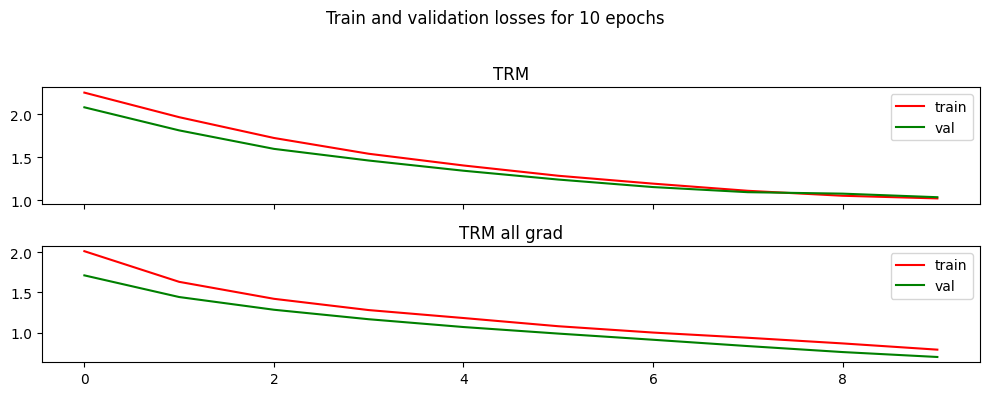

In [477]:
compare_losses(trm_base_wines_10_model,
               trm_allgrad_wines_10_model)

In [478]:
result = display_logs("wines", 10)
result.iloc[[0, -1]]

,model_name,task,num_params,dataset,num_classes,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,initial_train_acc,final_train_acc,initial_val_acc,final_val_acc,overfitting,underfitting,near_random
89,TRM,classification,3142,wines,7.0,10,2.2502,1.0236,2.0798,1.0376,0.0000,0.6981,0.0000,0.6667,False,False,False
92,TRM all grad,classification,3142,wines,7.0,10,2.0104,0.7937,1.7116,0.7030,0.2264,0.9340,0.3056,0.9444,False,False,False


### Conclusion

Traking gradients on all steps helps a bit, but taking into account computational expensiveness of the gradient traking, we think that not tracking the gradients is actually good thing to do

### 3.2.11. TRM, ACT off

In [479]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=2,
    L_cycles=2,
    num_layers=2,
    halt_max_steps=1,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_noact_wines_10_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    num_epochs=10,
    task="classification",
    num_classes=7,
)

trm_noact_wines_10_model.name = "TRM no act"
trm_noact_wines_10_model.dataset = "wines"

log_experiment(trm_noact_wines_10_model)

Training / validation finished
Logging finished


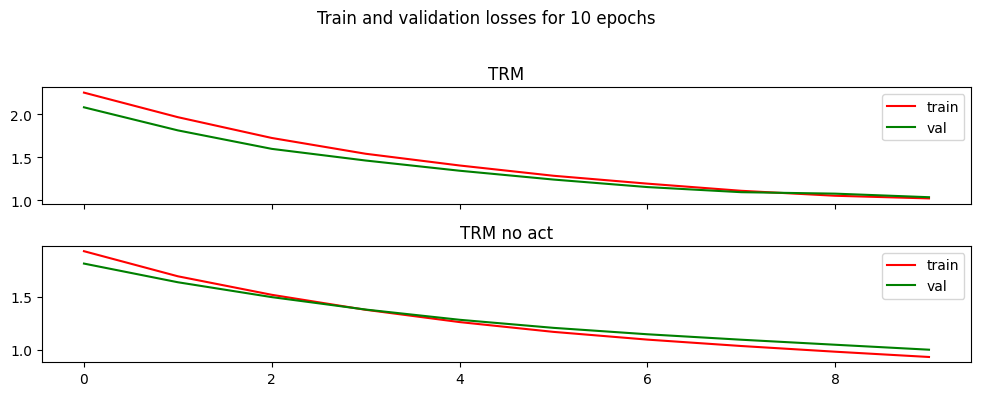

In [480]:
compare_losses(trm_base_wines_10_model,
               trm_noact_wines_10_model)

In [481]:
result = display_logs("wines", 10)
result.iloc[[0, -1]]

,model_name,task,num_params,dataset,num_classes,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,initial_train_acc,final_train_acc,initial_val_acc,final_val_acc,overfitting,underfitting,near_random
89,TRM,classification,3142,wines,7.0,10,2.2502,1.0236,2.0798,1.0376,0.0000,0.6981,0.0000,0.6667,False,False,False
93,TRM no act,classification,3142,wines,7.0,10,1.9287,0.9297,1.8117,0.9986,0.0283,0.7453,0.0556,0.5833,False,False,False


### Conclusion

Validation accuracy increased and loss decreased after we turned off ACT, therefore we can make a conclusion that ACT is damaging the training procedure. Also from the synthetic data we remember that it was introducing instability of training and validation, therefore we prove the hypothesis that ACT part of TRM is not that needed

### 3.2.12. TRM, no self-attention

In [482]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=2,
    L_cycles=2,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
    mlp_t=True
)

trm_nosa_wines_10_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    num_epochs=10,
    task="classification",
    num_classes=7,
)

trm_nosa_wines_10_model.name = "TRM no sa"
trm_nosa_wines_10_model.dataset = "wines"

log_experiment(trm_nosa_wines_10_model)

Training / validation finished
Logging finished


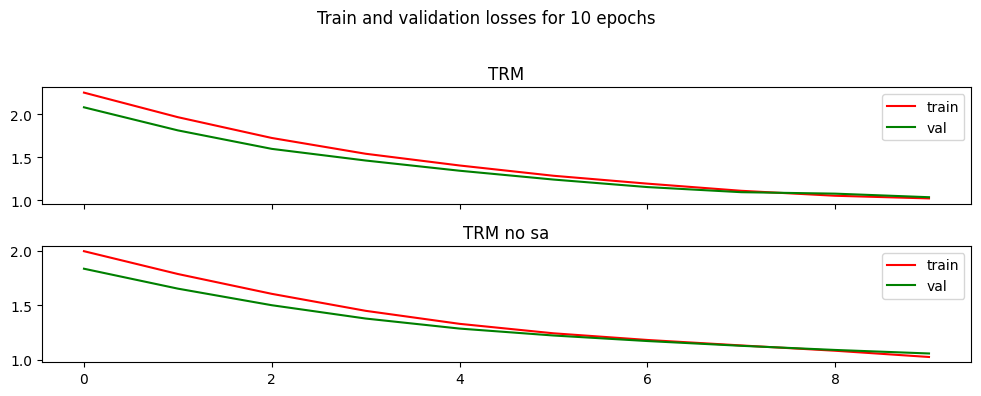

In [483]:
compare_losses(trm_base_wines_10_model,
               trm_nosa_wines_10_model)

In [484]:
result = display_logs("wines", 10)
result.iloc[[0, -1]]

,model_name,task,num_params,dataset,num_classes,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,initial_train_acc,final_train_acc,initial_val_acc,final_val_acc,overfitting,underfitting,near_random
89,TRM,classification,3142,wines,7.0,10,2.2502,1.0236,2.0798,1.0376,0.0000,0.6981,0.00,0.6667,False,False,False
94,TRM no sa,classification,1700,wines,7.0,10,1.9960,1.0242,1.8349,1.0564,0.2453,0.6226,0.25,0.5833,False,False,False


### Conclusion

In this case our hypothesis wasn't proved. Self-attention in `TRM` is an extremely important part, which decreases loss significantely and improves effiency of training massively

### 3.2.13. TRM, more self-attention heads

In [485]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=2,
    L_cycles=2,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
    num_heads=13
)

trm_4sa_wines_10_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    num_epochs=10,
    task="classification",
    num_classes=7,
)

trm_4sa_wines_10_model.name = "TRM 4 sa"
trm_4sa_wines_10_model.dataset = "wines"

log_experiment(trm_4sa_wines_10_model)

Training / validation finished
Logging finished


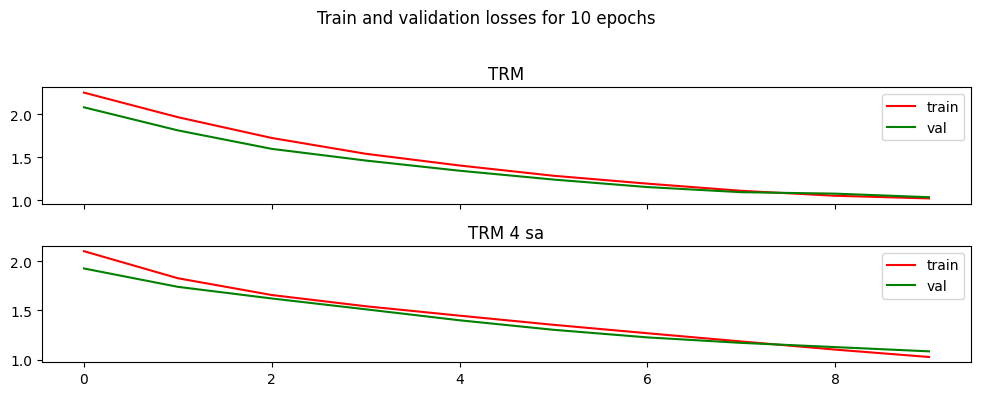

In [486]:
compare_losses(trm_base_wines_10_model,
               trm_4sa_wines_10_model)

In [487]:
result = display_logs("wines", 10)
result.iloc[[0, -1]]

,model_name,task,num_params,dataset,num_classes,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,initial_train_acc,final_train_acc,initial_val_acc,final_val_acc,overfitting,underfitting,near_random
89,TRM,classification,3142,wines,7.0,10,2.2502,1.0236,2.0798,1.0376,0.000,0.6981,0.00,0.6667,False,False,False
95,TRM 4 sa,classification,3142,wines,7.0,10,2.1002,1.0281,1.9250,1.0854,0.066,0.6698,0.25,0.5833,False,False,False


### Conclusion

Although self-attention turned out to be important, adding multiple self-atention heads is not beneficial and keeps the validation accuracy quite low.

### 3.2.14. TRM, more outer loops

In [488]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=4,
    L_cycles=2,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_4h2l_wines_10_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    num_epochs=10,
    task="classification",
    num_classes=7,
)

trm_4h2l_wines_10_model.name = "TRM 4H2L"
trm_4h2l_wines_10_model.dataset = "wines"

log_experiment(trm_4h2l_wines_10_model)

Training / validation finished
Logging finished


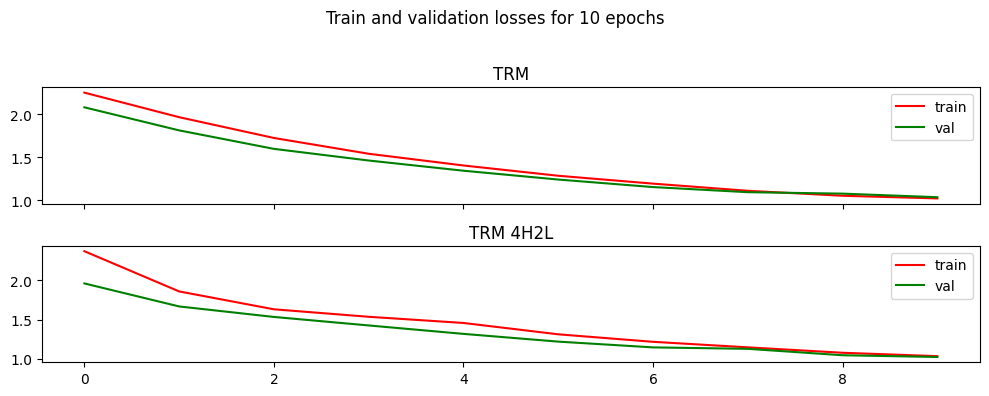

In [489]:
compare_losses(trm_base_wines_10_model,
               trm_4h2l_wines_10_model)

In [490]:
result = display_logs("wines", 10)
result.iloc[[0, -1]]

,model_name,task,num_params,dataset,num_classes,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,initial_train_acc,final_train_acc,initial_val_acc,final_val_acc,overfitting,underfitting,near_random
89,TRM,classification,3142,wines,7.0,10,2.2502,1.0236,2.0798,1.0376,0.0000,0.6981,0.0000,0.6667,False,False,False
96,TRM 4H2L,classification,3142,wines,7.0,10,2.3695,1.0351,1.9598,1.0247,0.0472,0.6698,0.1111,0.6667,False,False,False


### Conclusion

In case of increased outer loops we can see that loss has increased the validation loss, therefore, we can make a conclusion that outer loops are not that helpful. Also `TRM no rec` on 50 epoch converged to a lower loss than `TRM`, so the less outer loops the better

### 3.2.15. TRM, more inner loops

In [491]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=2,
    L_cycles=4,
    num_layers=2,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_2h4l_wines_10_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    num_epochs=10,
    task="classification",
    num_classes=7,
)

trm_2h4l_wines_10_model.name = "TRM 2H4L"
trm_2h4l_wines_10_model.dataset = "wines"

log_experiment(trm_2h4l_wines_10_model)

Training / validation finished
Logging finished


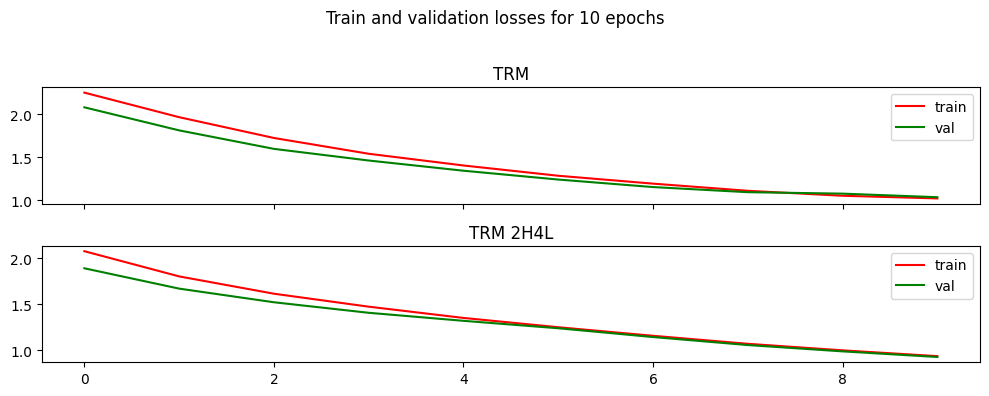

In [492]:
compare_losses(trm_base_wines_10_model,
               trm_2h4l_wines_10_model)

In [493]:
result = display_logs("wines", 10)
result.iloc[[0, -1]]

,model_name,task,num_params,dataset,num_classes,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,initial_train_acc,final_train_acc,initial_val_acc,final_val_acc,overfitting,underfitting,near_random
89,TRM,classification,3142,wines,7.0,10,2.2502,1.0236,2.0798,1.0376,0.0000,0.6981,0.0000,0.6667,False,False,False
97,TRM 2H4L,classification,3142,wines,7.0,10,2.0762,0.9340,1.8900,0.9248,0.0377,0.7075,0.0556,0.7222,False,False,False


### Conclusion

Inner loops at the same time don't make much of the change, only slightly decreasing validation loss. But they are more importnat than numebr of outer loops

### 3.2.16. TRM, more computational blocks

In [494]:
model_config = TRMConfig(
    hidden_size=D,
    H_cycles=2,
    L_cycles=2,
    num_layers=4,
    halt_max_steps=3,
    halt_exploration_prob=0.0,
    use_q_continue=False,
)

trm_4blocks_wines_10_model, _, _ = train_trm(
    model_config,
    x_train, y_train,
    x_val, y_val,
    num_epochs=10,
    task="classification",
    num_classes=7,
)

trm_4blocks_wines_10_model.name = "TRM 4 blocks"
trm_4blocks_wines_10_model.dataset = "wines"

log_experiment(trm_4blocks_wines_10_model)

Training / validation finished
Logging finished


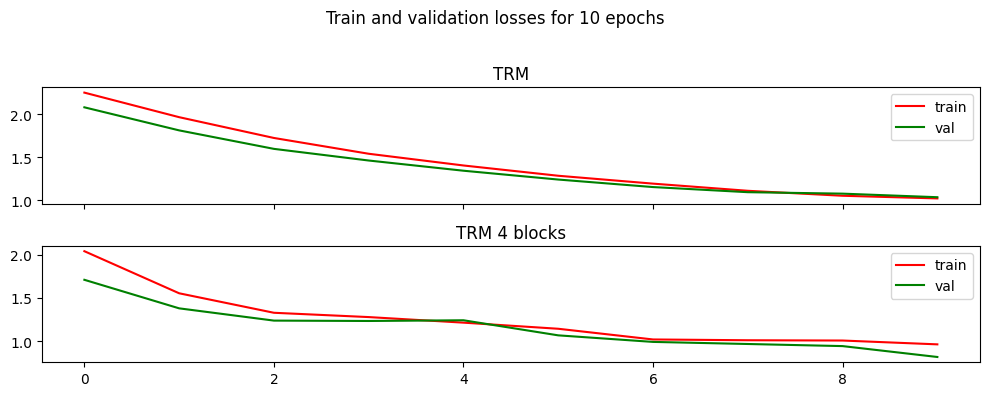

In [495]:
compare_losses(trm_base_wines_10_model,
               trm_4blocks_wines_10_model)

In [496]:
result = display_logs("wines", 10)
result.iloc[[0, -1]]

,model_name,task,num_params,dataset,num_classes,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,initial_train_acc,final_train_acc,initial_val_acc,final_val_acc,overfitting,underfitting,near_random
89,TRM,classification,3142,wines,7.0,10,2.2502,1.0236,2.0798,1.0376,0.0000,0.6981,0.0000,0.6667,False,False,False
98,TRM 4 blocks,classification,6132,wines,7.0,10,2.0408,0.9633,1.7099,0.8172,0.0377,0.7453,0.2778,0.8889,False,False,False


### Conclusion

More computational blocks damage the validation loss, which might be likely due to complication of calculation of gradients afterwards

In [497]:
final_result = display_logs("wines", 10).sort_values(by=["final_train_loss", "final_val_loss"], ascending=[False, False])
final_result = final_result[final_result["model_name"].str.startswith("TRM")]
final_result.style.background_gradient(subset=["final_train_loss", "final_val_loss"], cmap="RdYlGn_r")

,model_name,task,num_params,dataset,num_classes,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,initial_train_acc,final_train_acc,initial_val_acc,final_val_acc,overfitting,underfitting,near_random
96,TRM 4H2L,classification,3142,wines,7.000000,10,2.369500,1.035100,1.959800,1.024700,0.047200,0.669800,0.111100,0.666700,False,False,False
95,TRM 4 sa,classification,3142,wines,7.000000,10,2.100200,1.028100,1.925000,1.085400,0.066000,0.669800,0.250000,0.583300,False,False,False
94,TRM no sa,classification,1700,wines,7.000000,10,1.996000,1.024200,1.834900,1.056400,0.245300,0.622600,0.250000,0.583300,False,False,False
89,TRM,classification,3142,wines,7.000000,10,2.250200,1.023600,2.079800,1.037600,0.000000,0.698100,0.000000,0.666700,False,False,False
98,TRM 4 blocks,classification,6132,wines,7.000000,10,2.040800,0.963300,1.709900,0.817200,0.037700,0.745300,0.277800,0.888900,False,False,False
97,TRM 2H4L,classification,3142,wines,7.000000,10,2.076200,0.934000,1.890000,0.924800,0.037700,0.707500,0.055600,0.722200,False,False,False
93,TRM no act,classification,3142,wines,7.000000,10,1.928700,0.929700,1.811700,0.998600,0.028300,0.745300,0.055600,0.583300,False,False,False
90,TRM no rec,classification,3142,wines,7.000000,10,2.315300,0.899700,2.065700,0.894600,0.028300,0.717000,0.027800,0.694400,False,False,False
92,TRM all grad,classification,3142,wines,7.000000,10,2.010400,0.793700,1.711600,0.703000,0.226400,0.934000,0.305600,0.944400,False,False,False


### Conclusion

From the validation loss we can make a conclusion that ACT and self-attention heads are two things that are less needed. More outer loops are less important than more inner loops.

The only way to improve model is to increase number of inner loops and too turm off ACT. Other than that all other changes are not efficient. Increase in innr loops helps as it makes updates of network more cerfull, helping with producing better gradients. ACT might be damaging, as it adds stochasticity  to the model.Therefore letting the model to decide when to stop the recursion might be not the best idea, as the model can stop at suboptimal level

In [498]:
s = display_logs("words", 10)[["model_name", "final_train_loss", "final_val_loss", "overfitting", "underfitting", "near_random"]]
r = display_logs("wines", 10)[["model_name", "final_train_loss", "final_val_loss", "overfitting", "underfitting", "near_random"]]
m = s.merge(r, on="model_name", suffixes=["_s", "_r"])
m.style.background_gradient(subset=["final_train_loss_s", "final_val_loss_s", "final_train_loss_r", "final_val_loss_r"], cmap="RdYlGn_r")

,model_name,final_train_loss_s,final_val_loss_s,overfitting_s,underfitting_s,near_random_s,final_train_loss_r,final_val_loss_r,overfitting_r,underfitting_r,near_random_r
0,TRM,1.421000,1.274700,False,True,False,1.023600,1.037600,False,False,False
1,TRM no rec,0.001600,0.001400,False,False,False,0.899700,0.894600,False,False,False
2,MLP,0.000400,0.000300,False,False,False,1.988200,1.983900,False,True,False
3,TRM all grad,0.007700,0.007000,False,False,False,0.793700,0.703000,False,False,False
4,TRM no act,0.001400,0.001300,False,False,False,0.929700,0.998600,False,False,False
5,TRM no sa,0.001300,0.001200,False,False,False,1.024200,1.056400,False,False,False
6,TRM 4 sa,1.877500,1.656800,False,True,False,1.028100,1.085400,False,False,False
7,TRM 4H2L,1.843300,2.243200,False,True,False,1.035100,1.024700,False,False,False
8,TRM 2H4L,1.920800,1.264400,False,True,False,0.934000,0.924800,False,False,False
9,TRM 4 blocks,1.847100,1.833100,False,True,False,0.963300,0.817200,False,False,False


## Final conclusions

Overall, we can see that synthetic dataset was not best choice for such model as the task was too easy. Therefore, `TRM` is more suitable for complex tasks. `MLP` is performing worse as soon as task becomes more complex. Out of all parameters, number of inner loops is most important for improvement of model performance. Adaptive Computation Time is the parameter which significantly decreases the model performance.

# Bonus experiment: does `TRM` help with different data distributions?


### Context

Following experiment probes how robust `TRM`, `TRM no rec`, and `MLP` are to distribution shift on synthetic tabular data.

For each base distribution (Gaussian, Laplace, mixture) and each type of test-time shift (none, Gaussian, Laplace, uniform), we generate train/val/test sets, train all three models on the training split, and then compare their training and validation losses to see which architecture handles the shifted test distribution best.

In [499]:
def add_label_noise(y, noise_level, n_classes):
    n = len(y)
    mask = np.random.rand(n) < noise_level
    random_labels = np.random.randint(0, n_classes, size=mask.sum())
    y_noisy = y.copy()
    y_noisy[mask] = random_labels

    return y_noisy

In [500]:
def generate_gaussian_blobs(n, n_features, n_classes, seed=0):
    rng = np.random.default_rng(seed)

    X = []
    y = []

    means = rng.uniform(-3, 3, size=(n_classes, n_features))

    for k in range(n_classes):
        cov = np.eye(n_features)
        samples = rng.multivariate_normal(means[k], cov, size=n//n_classes)
        X.append(samples)
        y.append(np.full(n//n_classes, k))

    return np.vstack(X), np.hstack(y)

In [501]:
def generate_distribution_shift(n_train, n_test, n_features, n_classes, seed=0):
    rng = np.random.default_rng(seed)

    # Train distribution: Gaussian
    X_train, y_train = generate_gaussian_blobs(n_train, n_features, n_classes, seed)

    # Test distribution: Laplace
    X_test = rng.laplace(0, 1, size=(n_test, n_features))
    y_test = rng.integers(0, n_classes, size=n_test)

    return X_train, y_train, X_test, y_test

In [502]:
def generate_xor(n, seed=0):
    rng = np.random.default_rng(seed)
    x1 = rng.normal(0,1,n)
    x2 = rng.normal(0,1,n)

    X = np.stack([x1, x2], axis=1)
    y = ((x1>0) ^ (x2>0)).astype(int)  # XOR

    return X, y

In [503]:
def generate_synthetic_dataset(
    dist="gaussian",
    noise=0.0,
    shift=None,
    n_train=2000,
    n_val=1000,
    n_test=1000,
    n_features=20,
    n_classes=3,
    seed=0,
):
    rng = np.random.default_rng(seed)

    # --- Generate distributions ---
    if dist == "gaussian":
        X, y = generate_gaussian_blobs(
            n_train + n_val + n_test, n_features, n_classes, seed
        )

    elif dist == "mixture":
        X, y = generate_gaussian_blobs(
            n_train + n_val + n_test, n_features, n_classes, seed
        )
        # Add overlap
        X += rng.normal(0, 0.5, size=X.shape)

    elif dist == "laplace":
        X = rng.laplace(0, 1, size=(n_train + n_val + n_test, n_features))
        y = rng.integers(0, n_classes, size=len(X))

    elif dist == "xor":
        X, y = generate_xor(n_train + n_val + n_test, seed)

    else:
        raise ValueError("Unknown distribution type.")


    # --- Split into train/val/test ---
    X_train, X_tmp, y_train, y_tmp = train_test_split(
        X, y, test_size=(n_val + n_test),
        random_state=seed, stratify=y
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_tmp, y_tmp, test_size=n_test/(n_val+n_test),
        random_state=seed+1, stratify=y_tmp
    )


    # --- Apply distribution shift to test ---
    if shift == "laplace_test":
        X_test = rng.laplace(0, 1, size=X_test.shape)
    elif shift == "uniform_test":
        X_test = rng.uniform(-3, 3, size=X_test.shape)
    elif shift == "gaussian_test":
        X_test = rng.normal(0, 1, size=X_test.shape)
    # else: no shift


    # --- Add label noise ---
    if noise > 0:
        y_train = add_label_noise(y_train, noise, n_classes)


    return X_train, y_train, X_val, y_val, X_test, y_test

In [504]:
x_train_gaussian,y_train_gaussian, x_val_gaussian, y_val_gaussian, x_test_gaussian, y_test_gaussian = generate_synthetic_dataset(
    dist="gaussian",
    shift="laplace_test",
    noise=0.2,
    n_features=20,
    n_classes=3,
)

In [505]:
# Convert everything to torch exactly once
x_train_gaussian = torch.tensor(x_train_gaussian, dtype=torch.float32)
y_train_gaussian = torch.tensor(y_train_gaussian, dtype=torch.float32)

x_val_gaussian = torch.tensor(x_val_gaussian, dtype=torch.float32)
y_val_gaussian = torch.tensor(y_val_gaussian, dtype=torch.float32)

x_test_gaussian = torch.tensor(x_test_gaussian, dtype=torch.float32)
y_test_gaussian = torch.tensor(y_test_gaussian, dtype=torch.float32)

In [506]:
def run_dist_shift_experiment(
    dist: str,
    shift: str = "none",        # "none", "gaussian_test", "laplace_test", "uniform_test"
    noise: float = 0.2,
    n_features: int = 20,
    n_classes: int = 3,
    seed: int = 0,
):
    """
    dist  : "gaussian", "laplace", "mixture", ...
    shift : "none" or one of {"gaussian_test", "laplace_test", "uniform_test"}
    """

    # --- 1. Generate synthetic dataset ---
    shift_arg = None if shift == "none" else shift

    x_train_np, y_train_np, \
    x_val_np,   y_val_np, \
    x_test_np,  y_test_np = generate_synthetic_dataset(
        dist=dist,
        shift=shift_arg,
        noise=noise,
        n_features=n_features,
        n_classes=n_classes,
        seed=seed,
    )

    # --- 2. Convert to torch.float32 (everything) ---
    x_train = torch.tensor(x_train_np, dtype=torch.float32)
    y_train = torch.tensor(y_train_np, dtype=torch.float32)

    x_val   = torch.tensor(x_val_np,   dtype=torch.float32)
    y_val   = torch.tensor(y_val_np,   dtype=torch.float32)

    # --- Human-readable names for plots ---
    dist_name  = dist.capitalize()
    if shift == "none":
        shift_name = "no shift"
    else:
        # e.g. "gaussian_test" -> "Gaussian shift"
        base = shift.replace("_test", "").capitalize()
        shift_name = f"{base} shift"

    # =============== base TRM ===============
    trm_cfg = TRMConfig(
        hidden_size=20,   # must match input dim
        H_cycles=2,
        L_cycles=2,
        num_layers=2,
        halt_max_steps=3,
        halt_exploration_prob=0.0,
        use_q_continue=False,
    )

    trm_model, _, _ = train_trm(
        trm_cfg,
        x_train, y_train,
        x_val,   y_val,
    )

    trm_model.name = f"TRM ({dist_name} with {shift_name})"
    trm_model.dataset = f"{dist_name}-{shift_name}"
    log_experiment(trm_model)

    # =============== TRM without recursion ===============
    trm_norec_cfg = TRMConfig(
        hidden_size=20,
        H_cycles=1,   # no recursion (single outer + inner step)
        L_cycles=1,
        num_layers=2,
        halt_max_steps=3,
        halt_exploration_prob=0.0,
        use_q_continue=False,
    )

    trm_norec_model, _, _ = train_trm(
        trm_norec_cfg,
        x_train, y_train,
        x_val,   y_val,
    )

    trm_norec_model.name = f"TRM no rec ({dist_name} with {shift_name})"
    trm_norec_model.dataset = f"{dist_name}-{shift_name}"
    log_experiment(trm_norec_model)

    # =============== baseline MLP ===============
    mlp_model, _, _ = train_mlp(
        20,
        x_train, y_train,
        x_val,   y_val,
    )

    mlp_model.name = f"MLP ({dist_name} with {shift_name})"
    mlp_model.dataset = f"{dist_name}-{shift_name}"
    log_experiment(mlp_model)

    # =============== Plot train/val losses ===============
    compare_losses(
        trm_model,
        trm_norec_model,
        mlp_model,
    )


=== gaussian with none ===
Training / validation finished
Logging finished
Training / validation finished
Logging finished
Training / validation finished
Logging finished


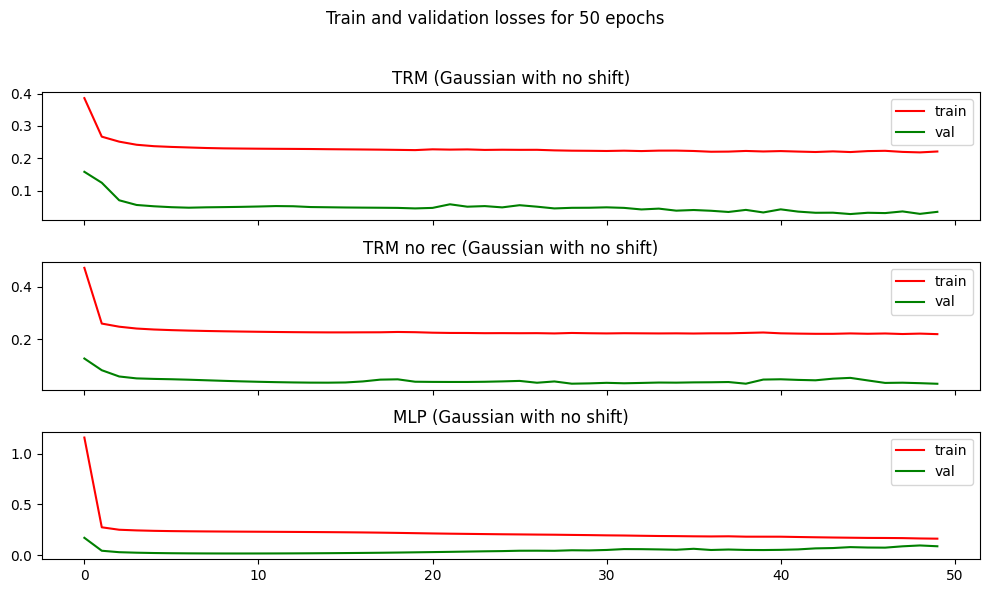


=== gaussian with gaussian_test ===
Training / validation finished
Logging finished
Training / validation finished
Logging finished
Training / validation finished
Logging finished


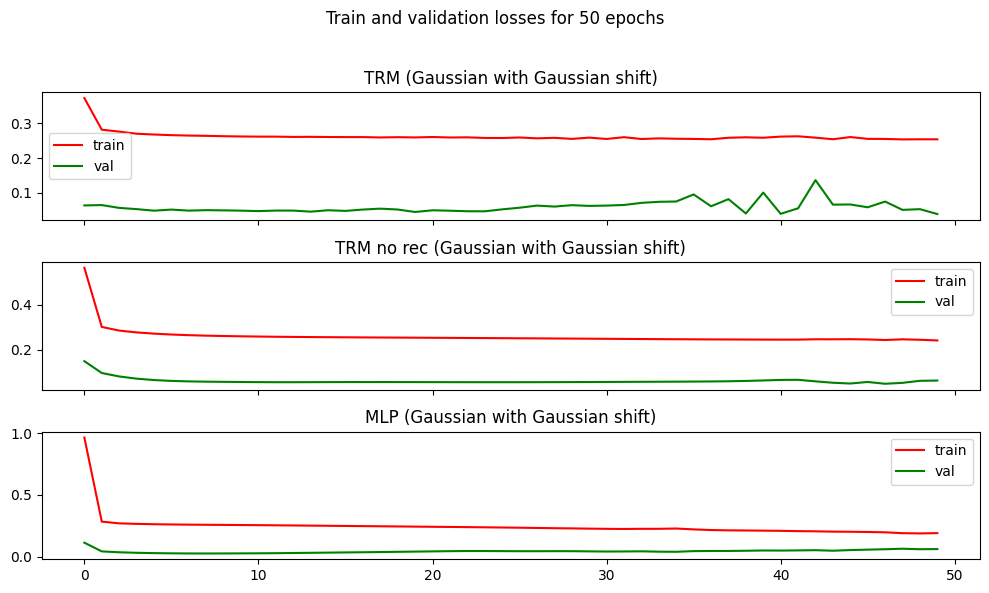


=== gaussian with laplace_test ===
Training / validation finished
Logging finished
Training / validation finished
Logging finished
Training / validation finished
Logging finished


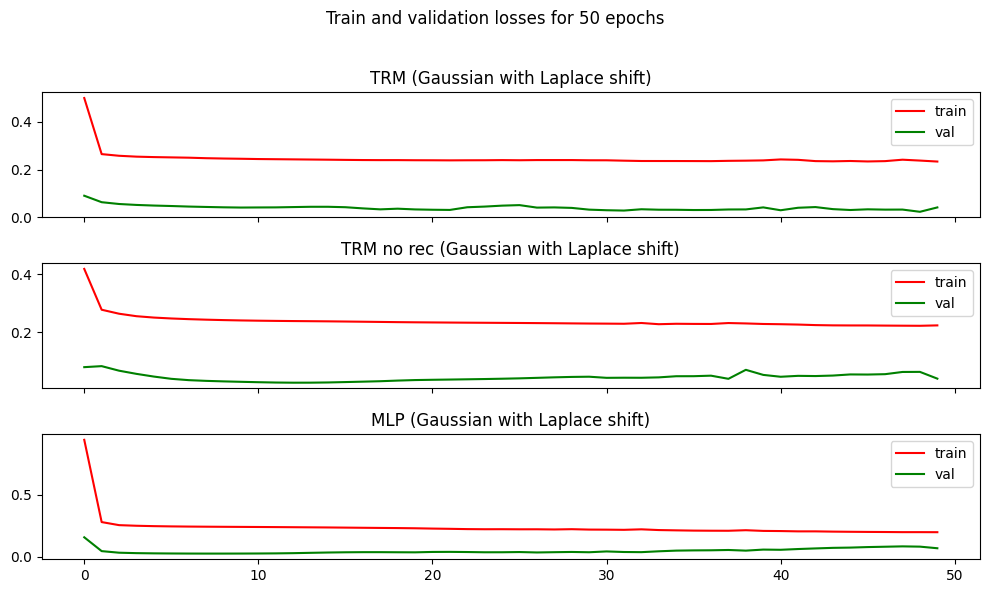


=== gaussian with uniform_test ===
Training / validation finished
Logging finished
Training / validation finished
Logging finished
Training / validation finished
Logging finished


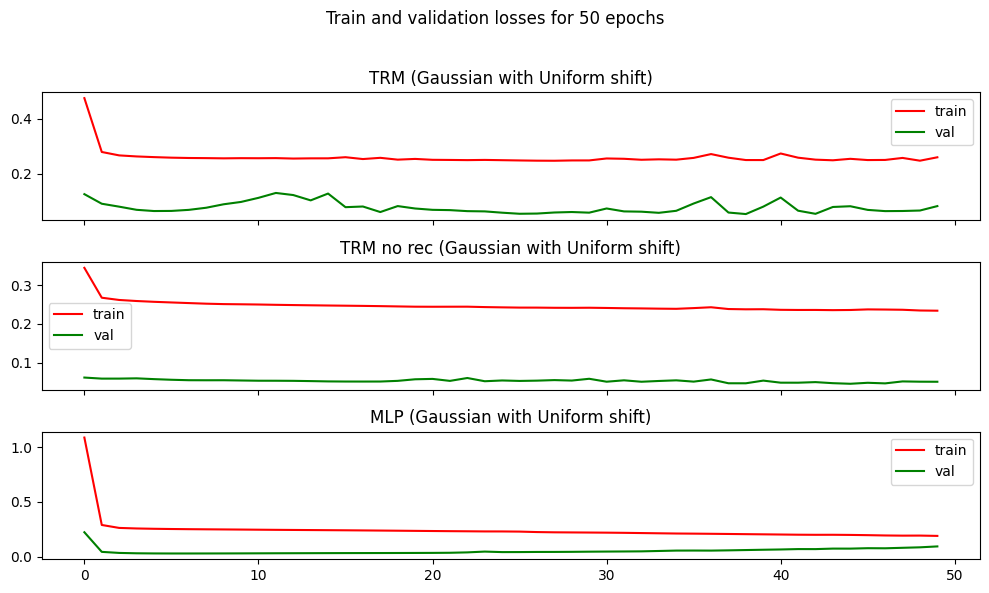


=== laplace with none ===
Training / validation finished
Logging finished
Training / validation finished
Logging finished
Training / validation finished
Logging finished


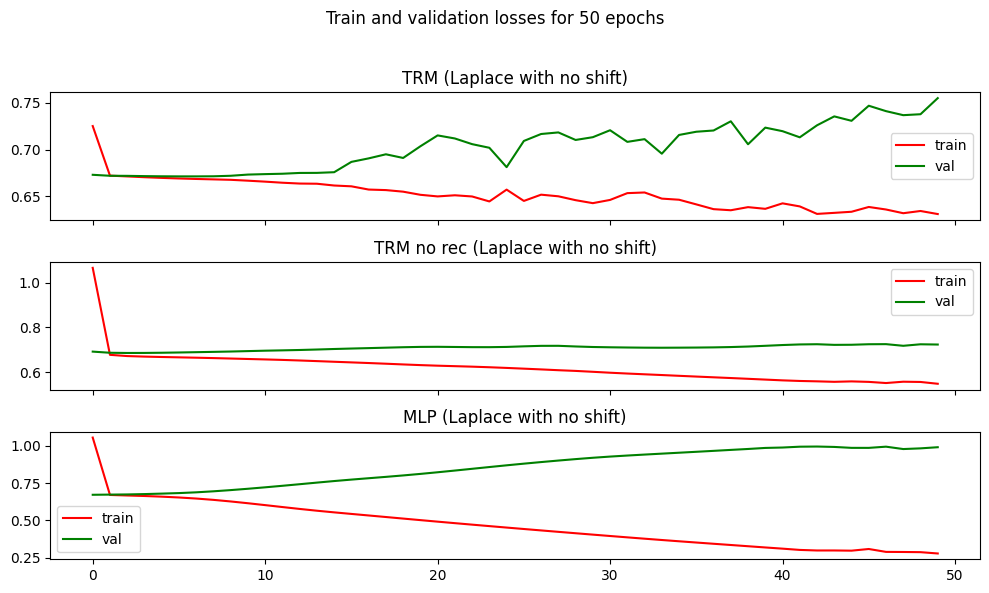


=== laplace with gaussian_test ===
Training / validation finished
Logging finished
Training / validation finished
Logging finished
Training / validation finished
Logging finished


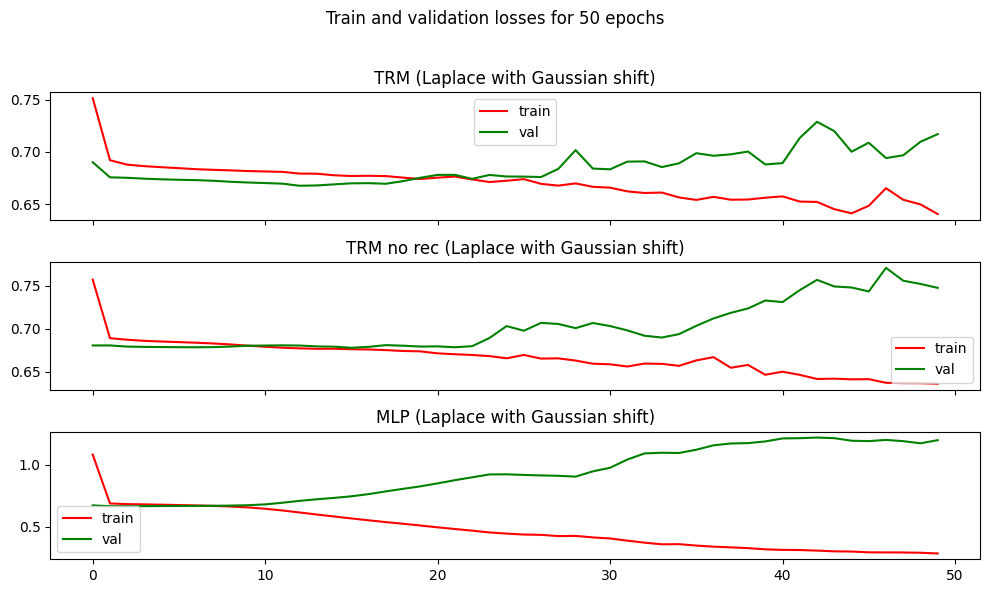


=== laplace with laplace_test ===
Training / validation finished
Logging finished
Training / validation finished
Logging finished
Training / validation finished
Logging finished


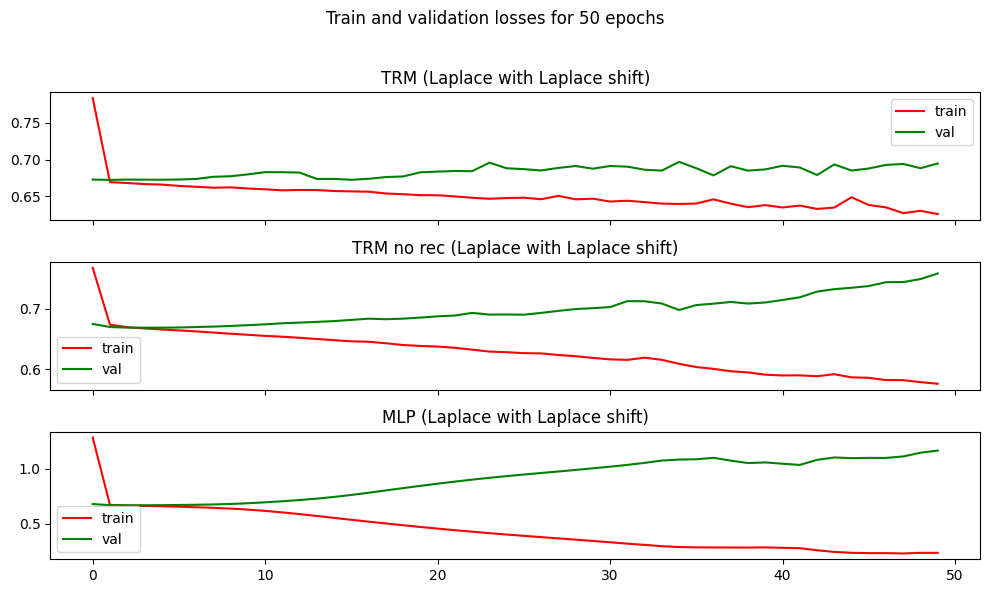


=== laplace with uniform_test ===
Training / validation finished
Logging finished
Training / validation finished
Logging finished
Training / validation finished
Logging finished


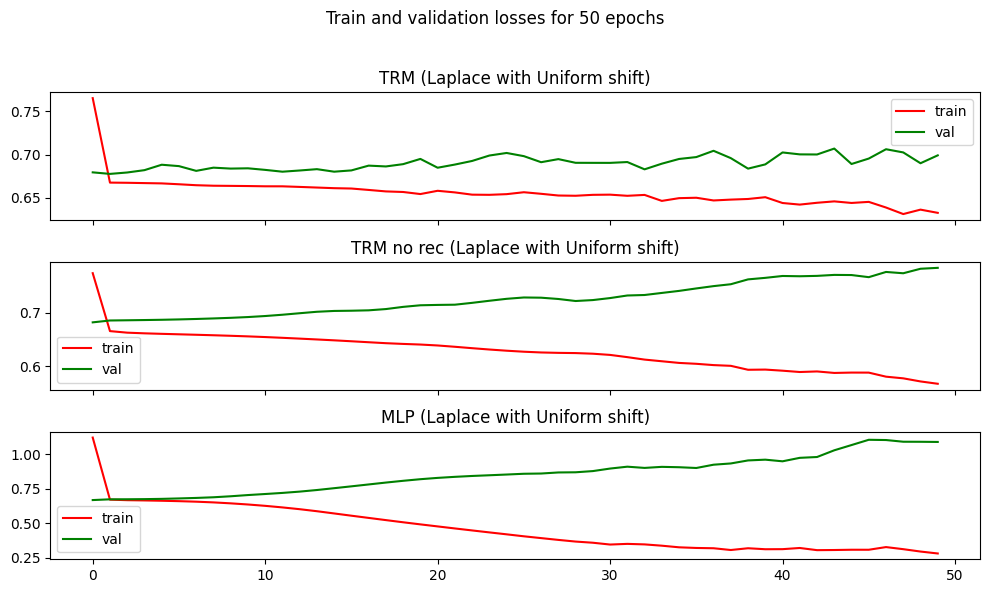


=== mixture with none ===
Training / validation finished
Logging finished
Training / validation finished
Logging finished
Training / validation finished
Logging finished


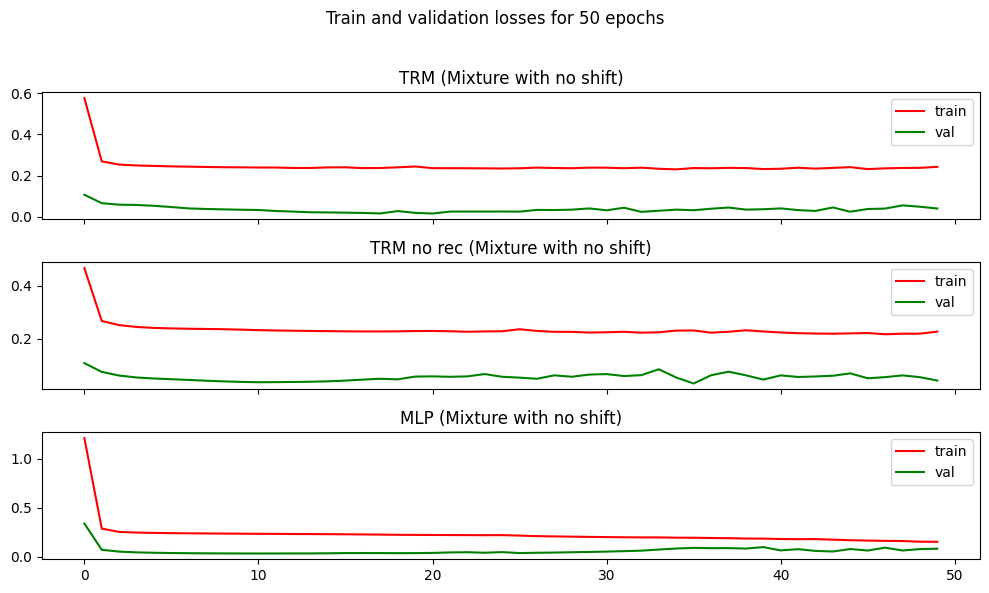


=== mixture with gaussian_test ===
Training / validation finished
Logging finished
Training / validation finished
Logging finished
Training / validation finished
Logging finished


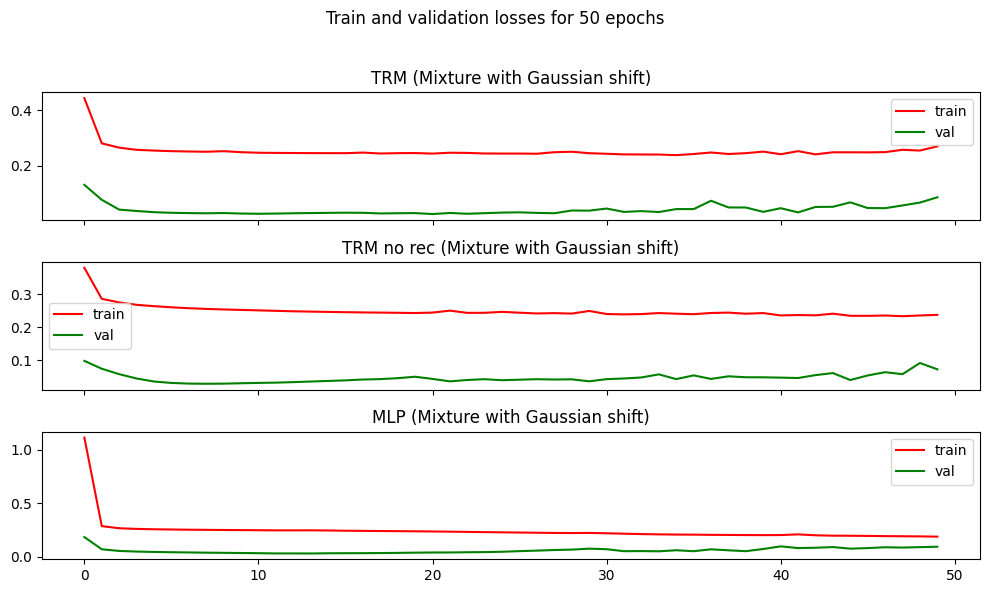


=== mixture with laplace_test ===
Training / validation finished
Logging finished
Training / validation finished
Logging finished
Training / validation finished
Logging finished


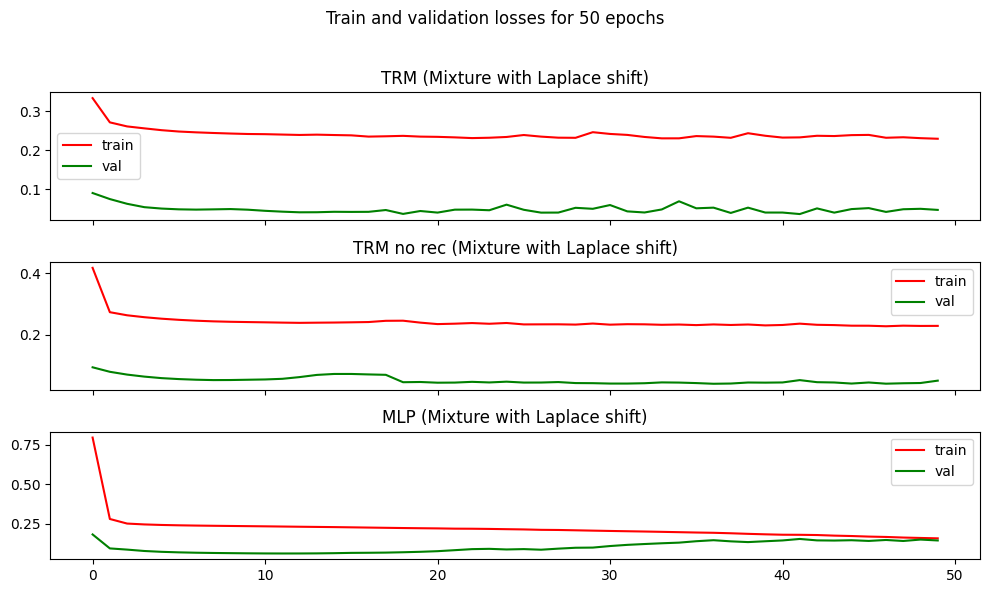


=== mixture with uniform_test ===
Training / validation finished
Logging finished
Training / validation finished
Logging finished
Training / validation finished
Logging finished


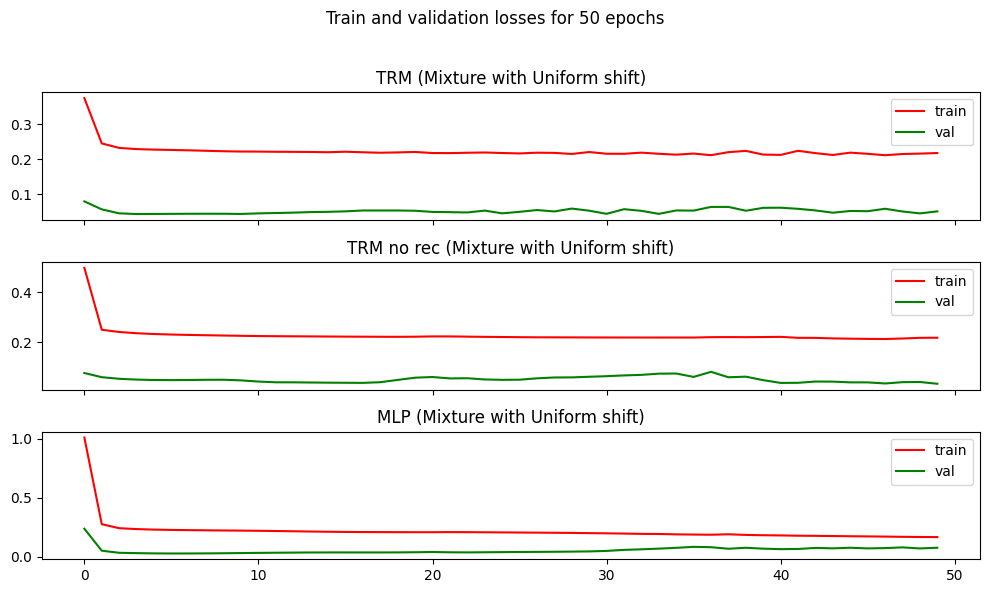

In [507]:
for dist in ["gaussian", "laplace", "mixture"]:
    for shift in ["none", "gaussian_test", "laplace_test", "uniform_test"]:
        print(f"\n=== {dist} with {shift} ===")
        run_dist_shift_experiment(dist=dist, shift=shift)

In [508]:
final_result = pd.read_csv('experiments_log.csv')
final_result = final_result[final_result["dataset"].str.contains('-')]
final_result.style.background_gradient(subset=["final_train_loss", "final_val_loss"], cmap="RdYlGn_r")

,model_name,task,num_params,dataset,num_classes,num_epochs,initial_train_loss,final_train_loss,initial_val_loss,final_val_loss,initial_train_acc,final_train_acc,initial_val_acc,final_val_acc,overfitting,underfitting,near_random
99,TRM (Gaussian with no shift),regression,6943,Gaussian-no shift,nan,50,0.385800,0.220700,0.157900,0.034100,nan,nan,nan,nan,False,False,False
100,TRM no rec (Gaussian with no shift),regression,6943,Gaussian-no shift,nan,50,0.471500,0.219500,0.126800,0.030800,nan,nan,nan,nan,False,False,False
101,MLP (Gaussian with no shift),regression,6661,Gaussian-no shift,nan,50,1.157300,0.161800,0.170300,0.087000,nan,nan,nan,nan,False,False,False
102,TRM (Gaussian with Gaussian shift),regression,6943,Gaussian-Gaussian shift,nan,50,0.372700,0.254200,0.063700,0.038900,nan,nan,nan,nan,False,False,False
103,TRM no rec (Gaussian with Gaussian shift),regression,6943,Gaussian-Gaussian shift,nan,50,0.564400,0.242400,0.150400,0.064600,nan,nan,nan,nan,False,False,False
104,MLP (Gaussian with Gaussian shift),regression,6661,Gaussian-Gaussian shift,nan,50,0.963400,0.191600,0.114700,0.063100,nan,nan,nan,nan,False,False,False
105,TRM (Gaussian with Laplace shift),regression,6943,Gaussian-Laplace shift,nan,50,0.498800,0.233400,0.090600,0.041700,nan,nan,nan,nan,False,False,False
106,TRM no rec (Gaussian with Laplace shift),regression,6943,Gaussian-Laplace shift,nan,50,0.419000,0.224100,0.079900,0.040200,nan,nan,nan,nan,False,False,False
107,MLP (Gaussian with Laplace shift),regression,6661,Gaussian-Laplace shift,nan,50,0.943300,0.198100,0.156900,0.068600,nan,nan,nan,nan,False,False,False
108,TRM (Gaussian with Uniform shift),regression,6943,Gaussian-Uniform shift,nan,50,0.474800,0.259700,0.125600,0.082300,nan,nan,nan,nan,False,False,False


### Conclusion

Let’s move on to the distributions. real data does not allow us to control it. therefore, we will use synthetic data. also we will apply noise so that we can see if the model is able to self correct. We want to answer the question: under which distribution improvement emerges. Gaussian is smooth and is able to self correct in each shift. For Laplace more or less all models fail, dut MLP the most . Therefore we can amke a conclusion that TRM is not model agnostic although can slightly improve the result. All models failed to converge and overfitted. For mixture (multiple gausian distr) we can see that again TRM is helpful and able to converge to the correct mode. TRM works best when the data manifold is smoothly navigable by gradient-like refinement.